In [1]:
# ── CELL 1: MOUNT & INSTALL ────────────────────────────────────────────────────
#from google.colab import drive
#drive.mount('/content/drive', force_remount=True)
# !pip install statsmodels -q
#!pip install regex
#import regex as re

Mounted at /content/drive


**Setup Cell**



---




In [5]:
# Specify body of text being used
statements= True; minutes= True; conferences= True; speeches= True
USE_CENTERING = True        # ← set False to disable and re-run for comparison

# Specify sentiment indicators being used (use same name as csv files in Taylor Rule Data folder)
Indicators =['Sharpe_speeches_minutes_statements_conferences_both_nlp']#['Gardner_statements_zscore_nlp']#
# Specify regressors of interest (gap, inflation, and FFR are always included)
Regressors = [
    'inflation_dev_from_target',
    'unemployment_gap',
    'effective_rate','gdp'
    #'actual_wedge_UNEMPF1',
    #'actual_wedge_UNEMPF4',
    #'actual_wedge_gRGDPF1',
    #'actual_wedge_gRGDPF4',
    #'actual_wedge_gPCPIF1',
    #'actual_wedge_gPCPIF4'
]
# NOTE: ffr_spread = implied_ffr − effective_rate.
# This is the forward-guidance component (how far the market expects rates to
# move), which is orthogonal to the current level already captured by
# effective_rate. Using both implied_ffr and effective_rate causes collinearity.



---



In [7]:
#@title Imports and Config
import os
import datetime
import pandas  as pd
import numpy   as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel

BASE_PATH  = '/content/drive/MyDrive/HEC Thesis/Taylor Rule Data/'
DATA_PATH  = '/content/drive/MyDrive/HEC Thesis/Data/'

# Input files
MACRO_FILE   = os.path.join(DATA_PATH,  'Master_Macro.csv')   # stacked dataset from pipeline
SHADOW_FILE  = os.path.join(BASE_PATH,  'Shadow_Rate.csv')
SENTIMENT_FILES = {i: os.path.join(f'{BASE_PATH}/NLP Output', f'{i}.csv') for i in Indicators}


In [8]:
import sys
# Update this path to wherever you saved regression_logger.py on your Drive
sys.path.insert(0, '/content/drive/MyDrive/HEC Thesis/')  # ← adjust folder
from regression_logger import RegressionLogger
RESULTS_DIR = '/content/drive/MyDrive/HEC Thesis/Regression Results/'
logger = RegressionLogger(log_dir=RESULTS_DIR)
# Replace the manual INDEXING_TIME line with this
_HIERARCHY = [
    (speeches,    'blackout_date'),
    (minutes,     'minutes_date'),
    (statements,  'meeting_date'),
    (conferences, 'meeting_date'),
]
INDEXING_TIME = next(event_col for flag, event_col in _HIERARCHY if flag)
print(f"  Indexing time auto-detected: {INDEXING_TIME}")

  Indexing time auto-detected: blackout_date


In [9]:
#@title Data Loading

def load_macro(statements=True, minutes=False, conferences=False, speeches=False):
    HIERARCHY = [
        ('speeches',     'blackout_date'),
        ('minutes',      'minutes_date'),
        ('statements',   'meeting_date'),
        ('conferences',  'meeting_date'),
    ]
    flags = {
        'speeches':    speeches,
        'minutes':     minutes,
        'statements':  statements,
        'conferences': conferences,
    }
    selected_event = next(
        (event_col for name, event_col in HIERARCHY if flags[name]),
        None
    )
    if selected_event is None:
        raise ValueError("At least one event type must be True.")

    df = pd.read_csv(MACRO_FILE, parse_dates=['date'])
    df = df[df['event_type'] == selected_event].copy()
    df = df.sort_values('date').set_index('date')
    print(f"  ✓  Macro data: {len(df)} rows indexed to '{selected_event}'")
    return df


def load_shadow_rate():
    def parse_mmm_yy(s):
        try:
            dt = pd.to_datetime(s, format='%b-%y')
            if dt.year > datetime.datetime.now().year:
                dt = dt.replace(year=dt.year - 100)
            return dt
        except Exception:
            return pd.NaT

    df = pd.read_csv(SHADOW_FILE, sep=';', header=0, encoding='utf-8-sig')
    df = df.iloc[:, [0, 2]].copy()
    df.columns = ['date_raw', 'shadow_rate']
    df['shadow_rate'] = pd.to_numeric(df['shadow_rate'], errors='coerce')
    df['date']        = df['date_raw'].apply(parse_mmm_yy)
    df = (df.drop(columns=['date_raw'])
            .sort_values('date')
            .dropna(subset=['date', 'shadow_rate'])
            .drop_duplicates(subset='date'))
    print(f"  ✓  Shadow rate: {len(df)} rows  "
          f"[{df['shadow_rate'].min():.2f}, {df['shadow_rate'].max():.2f}]")
    return df


def load_sentiment(filepath, label):
    try:
        df = pd.read_csv(filepath)
        date_col = next((c for c in df.columns if c.lower() == 'date'), df.columns[0])
        df = df.rename(columns={date_col: 'date'})
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        df = df.sort_values('date').dropna(subset=['date'])
        print(f"  ✓  {label}: {len(df)} rows, score columns: "
              f"{[c for c in df.columns if c != 'date']}")
        return df
    except Exception as e:
        print(f"  ✗  {label}: {e}")
        return pd.DataFrame({'date': pd.Series(dtype='datetime64[ns]')})

# ── Derived config ─────────────────────────────────────────────────────────────
multi_event  = sum([statements, minutes, conferences, speeches]) > 1
merge_kwargs = (
    dict(direction='nearest', tolerance=pd.Timedelta('2d'))
    if not multi_event else
    dict(direction='backward')
)

# ── Load everything ────────────────────────────────────────────────────────────
print("=== Loading data ===")
df_macro      = load_macro(statements, minutes, conferences, speeches)
df_shadow     = load_shadow_rate()
sentiment_dfs = {
    name: load_sentiment(path, name)
    for name, path in SENTIMENT_FILES.items()
}

# ── Column selection: if an indicator has multiple score columns, ask user ─────
# This prevents collinearity between subcomponents (e.g. gardner_fin,
# gardner_inf, gardner_labor all in the same regression). The user picks one
# column per indicator to carry forward. If there is only one score column,
# it is selected automatically with no prompt.
sentiment_cols = {}

for name, df in sentiment_dfs.items():
    candidate_cols = [c for c in df.columns if c not in ('date', 'meeting_date')]

    if len(candidate_cols) == 0:
        print(f"  ⚠️  {name}: no score columns found")
        sentiment_cols[name] = []

    elif len(candidate_cols) == 1:
        sentiment_cols[name] = candidate_cols
        print(f"  ✓  {name}: single column auto-selected → '{candidate_cols[0]}'")

    else:
        # Multiple columns — enumerate and prompt
        print(f"\n  {name} contains {len(candidate_cols)} score columns:")
        for idx, col in enumerate(candidate_cols):
            print(f"    [{idx}] {col}")

        while True:
            raw = input(f"  Select column index to use for '{name}' "
                       f"(0–{len(candidate_cols)-1}), or 'all' to keep all: ").strip()
            if raw.lower() == 'all':
                sentiment_cols[name] = candidate_cols
                print(f"  ✓  Keeping all {len(candidate_cols)} columns for '{name}'")
                print(f"     Note: running these jointly risks collinearity.")
                print(f"     Gardner's approach is to test each subcomponent separately.")
                break
            elif raw.isdigit() and 0 <= int(raw) < len(candidate_cols):
                chosen = candidate_cols[int(raw)]
                sentiment_cols[name] = [chosen]
                # Drop the unchosen columns from the sentiment dataframe so they
                # never enter the merge — keeps df_final clean
                drop_cols = [c for c in candidate_cols if c != chosen]
                sentiment_dfs[name] = sentiment_dfs[name].drop(columns=drop_cols)
                print(f"  ✓  Selected '{chosen}' for '{name}' "                      f"(dropped: {drop_cols})")
                break
            else:
                print(f"  ✗  Invalid input. Enter a number 0–{len(candidate_cols)-1} or 'all'.")

print(f"\n  Sentiment columns mapped: {sentiment_cols}")

# ── Merge shadow rate (match on Year-Month) ────────────────────────────────────
df_macro_reset            = df_macro.reset_index()
df_macro_reset['YYYY-MM'] = df_macro_reset['date'].dt.to_period('M')
df_shadow['YYYY-MM']      = df_shadow['date'].dt.to_period('M')
df_shadow_dedup           = df_shadow.drop_duplicates(subset='YYYY-MM', keep='last')

df_merged = pd.merge(
    df_macro_reset,
    df_shadow_dedup[['YYYY-MM', 'shadow_rate']],
    on='YYYY-MM', how='left'
).drop(columns=['YYYY-MM'])

# ── Merge sentiment indicators ────────────────────────────────────────────────
# Use sentiment_cols to select exactly the score columns from each indicator —
# avoids the name-matching bug where indicator filename != score column names.
df_merged = df_merged.sort_values('date')
for name, df_sent in sentiment_dfs.items():
    score_cols = sentiment_cols[name]
    if not score_cols:
        print(f"  ⚠️  {name}: no score columns found, skipping merge")
        continue
    keep_cols = ['date'] + score_cols
    df_merged = pd.merge_asof(df_merged, df_sent[keep_cols],
                               on='date', **merge_kwargs)

# ── Set index & deduplicate ────────────────────────────────────────────────────
df_merged = df_merged.set_index('date')
df_merged = df_merged[~df_merged.index.duplicated(keep='first')]

# ── Effective rate: use shadow rate during ZLB (FFR ≤ 0.25%) ──────────────────
def get_effective_rate(row):
    sr  = row.get('shadow_rate',    np.nan)
    ffr = row.get('fed_funds_rate', np.nan)
    if pd.notna(sr) and pd.notna(ffr) and ffr <= 0.25:
        return sr
    return ffr

df_merged['effective_rate'] = df_merged.apply(get_effective_rate, axis=1)
df_merged['effective_rate'] = df_merged['effective_rate'].fillna(df_merged['fed_funds_rate'])

n_neg = (df_merged['effective_rate'] < 0).sum()
print(f"\n  Effective rate < 0 in {n_neg} periods (ZLB / post-ZLB periods)")

# ── Forward-guidance spread: implied_ffr − effective_rate ─────────────────────
# This isolates the market's expectation of the *change* in rates from today's
# level. It avoids collinearity with effective_rate while capturing exactly the
# information Gardner attributes to federal funds futures expectations.
# When spread > 0: market expects a hike. When spread < 0: expects a cut.
if 'implied_ffr' in df_merged.columns:
    df_merged['ffr_spread'] = df_merged['implied_ffr'] - df_merged['effective_rate']
    print(f"  ✓  ffr_spread constructed  "          f"[{df_merged['ffr_spread'].min():.3f}, {df_merged['ffr_spread'].max():.3f}]")
else:
    print("  ⚠️  implied_ffr not found — ffr_spread not constructed")

# ── Final dataset (2011 onwards) ──────────────────────────────────────────────
df_final = df_merged[df_merged.index >= '2011-01-01'].copy()
print(f"\n  df_final ready: {df_final.shape[0]} meetings × {df_final.shape[1]} columns")
print(f"  Columns: {list(df_final.columns)}")

# ── Sanity checks ─────────────────────────────────────────────────────────────
# ── Drop known collision columns that duplicate implied_ffr ──────────────────
drop_cols = [c for c in df_merged.columns if c in ('implied_ffr_x', 'implied_ffr_y')]
if drop_cols:
    df_merged = df_merged.drop(columns=drop_cols)
    df_final  = df_merged[df_merged.index >= '2011-01-01'].copy()
    print(f"  ✓  Dropped collision columns: {drop_cols}")

collision_cols = [c for c in df_merged.columns if c.endswith('_x') or c.endswith('_y')]
if collision_cols:
    print(f"\n  ⚠️  Remaining column collisions: {collision_cols}")
else:
    print("  ✓  No column collisions remaining")

# ── Scale GDP columns to billions ─────────────────────────────────────────────
GDP_SCALE = 1e9  # adjust to 1e6 if CSV is already in millions

gdp_cols = [c for c in df_final.columns if 'gdp' in c.lower()]
if gdp_cols:
    df_final[gdp_cols] = df_final[gdp_cols] / GDP_SCALE
    print(f"\n  ✓  GDP columns scaled by 1/{GDP_SCALE:.0e}: {gdp_cols}")
    print(f"     Ranges: { {c: (round(df_final[c].min(), 2), round(df_final[c].max(), 2)) for c in gdp_cols} }")
else:
    print("\n  ⚠️  No GDP columns found in df_final — check column names")


=== Loading data ===
  ✓  Macro data: 121 rows indexed to 'blackout_date'
  ✓  Shadow rate: 386 rows  [-2.99, 8.14]
  ✓  Sharpe_speeches_minutes_statements_conferences_both_nlp: 121 rows, score columns: ['meeting_date', 'sharpe_positive', 'sharpe_negative', 'sharpe_net']

  Sharpe_speeches_minutes_statements_conferences_both_nlp contains 3 score columns:
    [0] sharpe_positive
    [1] sharpe_negative
    [2] sharpe_net
  Select column index to use for 'Sharpe_speeches_minutes_statements_conferences_both_nlp' (0–2), or 'all' to keep all: 2
  ✓  Selected 'sharpe_net' for 'Sharpe_speeches_minutes_statements_conferences_both_nlp' (dropped: ['sharpe_positive', 'sharpe_negative'])

  Sentiment columns mapped: {'Sharpe_speeches_minutes_statements_conferences_both_nlp': ['sharpe_net']}

  Effective rate < 0 in 48 periods (ZLB / post-ZLB periods)
  ✓  ffr_spread constructed  [-0.430, 2.986]

  df_final ready: 119 meetings × 225 columns
  Columns: ['event_type', 'cpi', 'cpi_yoy', 'core_cpi', 'c

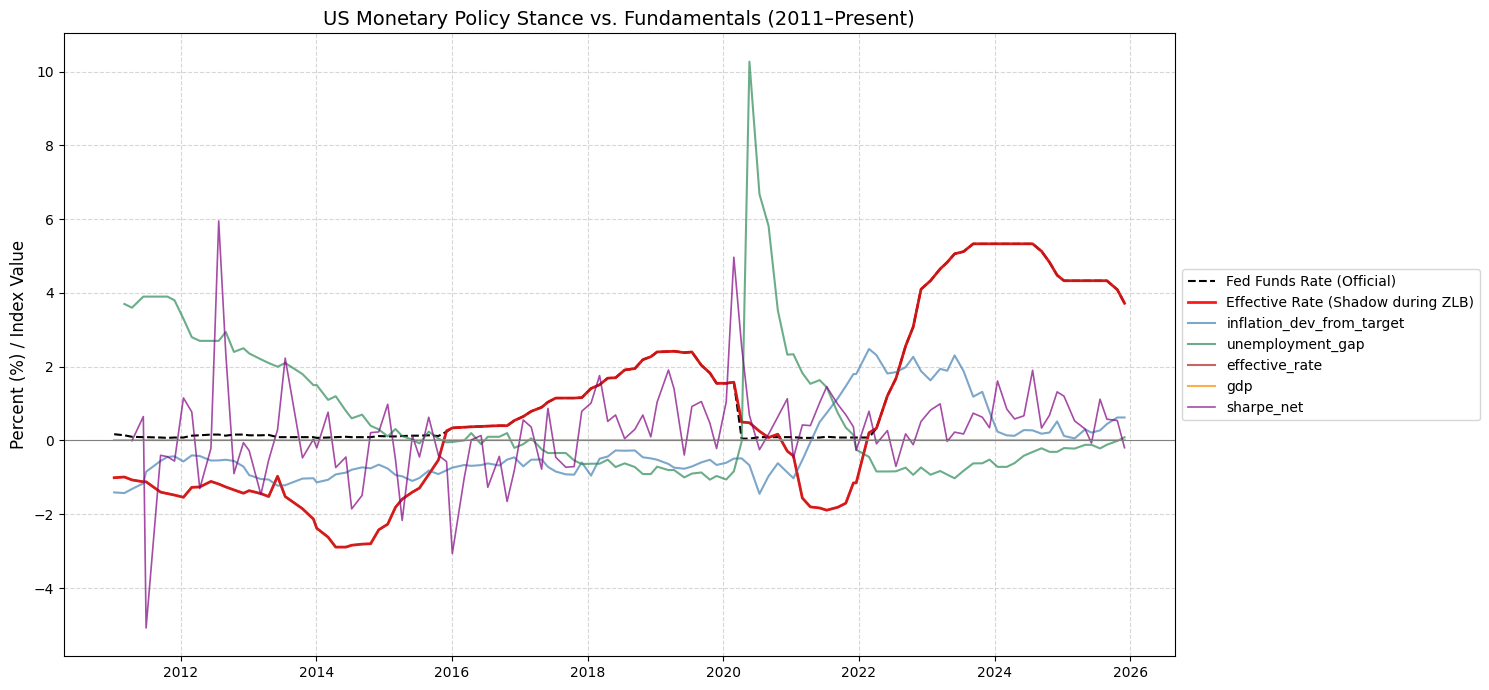

In [10]:
# @title Visualization

COLORS = ['steelblue', 'seagreen', 'firebrick', 'darkorange',
          'purple', 'teal', 'saddlebrown', 'hotpink']

fig, ax = plt.subplots(figsize=(15, 7))

# ── Always plotted: policy rates ──────────────────────────────────────────────
ax.plot(df_final.index, df_final['fed_funds_rate'],
        label='Fed Funds Rate (Official)', color='black',
        linewidth=1.5, linestyle='--')
ax.plot(df_final.index, df_final['effective_rate'],
        label='Effective Rate (Shadow during ZLB)', color='red',
        linewidth=2, alpha=0.9)

# ── User-specified regressors ─────────────────────────────────────────────────
for i, col in enumerate(Regressors):
    if col in df_final.columns:
        ax.plot(df_final.index, df_final[col],
                label=col, color=COLORS[i % len(COLORS)],
                linewidth=1.5, alpha=0.7)
    else:
        print(f"  ⚠️  Regressor '{col}' not found in df_final — skipping")

# ── Sentiment indicators ──────────────────────────────────────────────────────
linestyles = ['-', '--', '-.', ':']
for i, name in enumerate(sentiment_dfs):
    color = COLORS[(len(Regressors) + i) % len(COLORS)]
    for j, col in enumerate(sentiment_cols[name]):
        if col in df_final.columns:
            ax.plot(df_final.index, df_final[col],
                    label=col, color=color,
                    linewidth=1.2, alpha=0.7,
                    linestyle=linestyles[j % len(linestyles)])
        else:
            print(f"  ⚠️  Sentiment column '{col}' not found in df_final — skipping")

ax.axhline(0, color='grey', linewidth=0.8)
ax.set_title('US Monetary Policy Stance vs. Fundamentals (2011–Present)', fontsize=14)
ax.set_ylabel('Percent (%) / Index Value', fontsize=12)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
ax.grid(True, which='major', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [11]:
#@title Policy Decision Classification

df_model = df_final.copy()
df_model['rate_change'] = df_model['effective_rate'].diff()

def classify_decision(change):
    if change > 0.01:    return  1   # hike
    elif change < -0.01: return -1   # cut
    else:                return  0   # hold

df_model['MPD'] = df_model['rate_change'].apply(classify_decision)

print("FOMC Decision distribution:")
print(df_model['MPD'].value_counts().rename({1: 'Hike', 0: 'Hold', -1: 'Cut'}))

FOMC Decision distribution:
MPD
Hike    60
Cut     38
Hold    21
Name: count, dtype: int64


In [ ]:
# @title Collinearity check (VIF)
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_vif = df_model.copy()

base_predictors = []

sentiment_predictors = [
    c for name in sentiment_dfs
    for c in sentiment_cols[name]
    if c in df_vif.columns
]

# Separate predictors for Model 1 (Base) and Model 2 (Full)
predictors_base = base_predictors + [
    r for r in Regressors if r not in base_predictors
]
predictors_full = predictors_base + sentiment_predictors

# ── Create Interaction Terms ──────────────────────────────────────────────────
interaction_cols = []
for base_col in predictors_base:
    for sent_col in sentiment_predictors:
        inter_name = f"{base_col}_X_{sent_col}"
        df_vif[inter_name] = df_vif[base_col] * df_vif[sent_col]
        interaction_cols.append(inter_name)

# Model 3 includes base, sentiment, AND their cross-products
predictors_interact = predictors_full + interaction_cols

# Subset and drop NAs on the full interaction set
df_vif_clean = df_vif[predictors_interact].dropna()

# ── Calculate VIF ─────────────────────────────────────────────────────────────
vif_data = pd.DataFrame({
    'feature': df_vif_clean.columns,
    'VIF':     [variance_inflation_factor(df_vif_clean.values, i)
                for i in range(df_vif_clean.shape[1])]
}).sort_values('VIF', ascending=False)

print("\nVariance Inflation Factors (Model 3 with Interactions):")
print("(VIF > 10 = severe collinearity)")
print("-" * 60)
print(vif_data.to_string(index=False))
print()


Variance Inflation Factors (Model 3 with Interactions):
(VIF > 10 = severe collinearity)
------------------------------------------------------------
                                  feature        VIF
                            gardner_total 136.943940
                      gdp_X_gardner_total 132.734758
           effective_rate_X_gardner_total   4.253140
inflation_dev_from_target_X_gardner_total   3.642505
         unemployment_gap_X_gardner_total   3.602105
                           effective_rate   3.034279
                         unemployment_gap   2.928607
                                      gdp   2.056958
                inflation_dev_from_target   1.534730



Macro regressors        : ['inflation_dev_from_target', 'unemployment_gap', 'implied_ffr', 'effective_rate', 'gdp', 'vix']
Gardner scores found    : ['gardner_inf', 'gardner_labor', 'gardner_out', 'gardner_fin', 'gardner_mp']
Valid matched pairs     : ['gardner_inf', 'gardner_labor', 'gardner_out', 'gardner_fin', 'gardner_mp']
gardner_total available : True

Centering: ENABLED (expanding window, no look-ahead)

Sample size: 96 observations

  Interaction: gardner_inf     × inflation_dev_from_target
  Interaction: gardner_labor   × unemployment_gap
  Interaction: gardner_out     × gdp
  Interaction: gardner_fin     × vix
  Interaction: gardner_mp      × implied_ffr

5 theoretically matched interaction terms created.

───────────────────────────────────────────────────────
PCA — macro regressors (shared across all models)
───────────────────────────────────────────────────────
  [M] 6 vars → 6 PCs retained
           Kaiser: 2  |  Var threshold (99.9%): 6
           Cumulative variance e

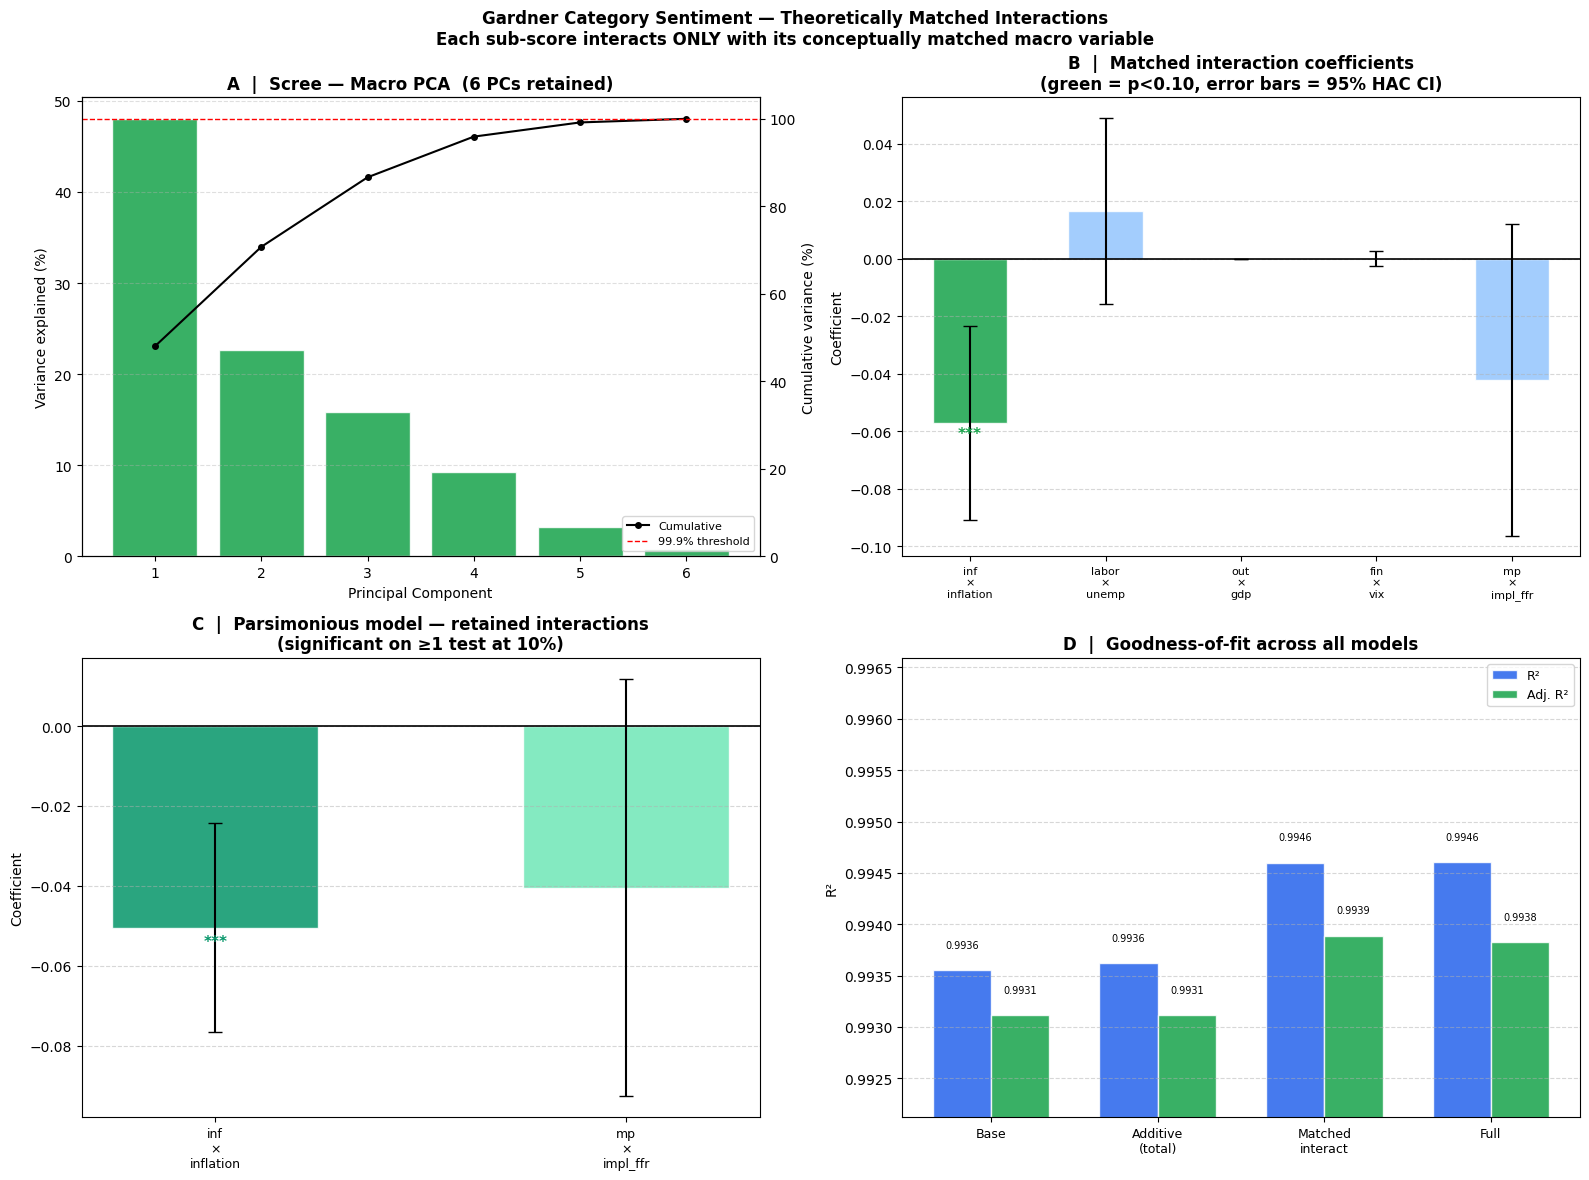

Figure saved.



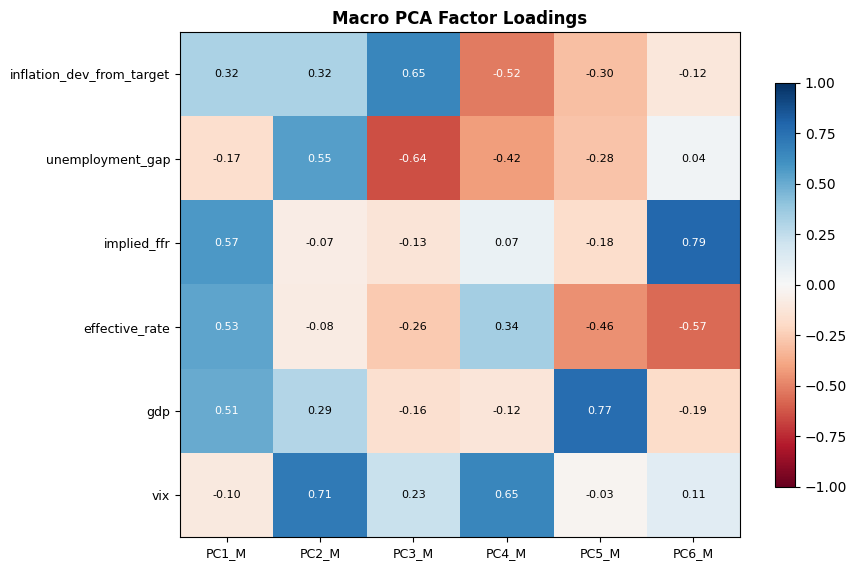

Loading heatmap saved.


MODEL 1 — Base: Macro PCA only (HAC Robust)
                            OLS Regression Results                            
Dep. Variable:            target_rate   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     5794.
Date:                Tue, 31 Mar 2026   Prob (F-statistic):          4.36e-113
Time:                        16:33:36   Log-Likelihood:                 44.145
No. Observations:                  96   AIC:                            -74.29
Df Residuals:                      89   BIC:                            -56.34
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

In [ ]:
  # @title Interaction pairing FAVAR
if len(sentiment_cols) > 1:
  import pandas as pd
  import numpy as np
  import statsmodels.api as sm
  from sklearn.preprocessing import StandardScaler
  from sklearn.decomposition import PCA
  from statsmodels.stats.outliers_influence import variance_inflation_factor
  import matplotlib.pyplot as plt
  import warnings

  warnings.filterwarnings("ignore")

  df_ols = df_model.copy()

  # ── Macro regressors ──────────────────────────────────────────────────────────
  Regressors = [
      'inflation_dev_from_target',
      'unemployment_gap',
      'implied_ffr',
      'effective_rate',
      'gdp',
      'vix',
  ]

  # Target: next-meeting rate
  df_ols['target_rate'] = df_ols['fed_funds_rate'].shift(-1)

  predictors_macro = [r for r in Regressors if r in df_ols.columns]

  # ── Gardner category sentiment columns ───────────────────────────────────────
  # Each sub-score targets a specific domain of FOMC communication.
  # We match each sentiment score to its conceptually corresponding macro variable.
  # This gives theoretically motivated interactions rather than all-pairs crossings,
  # which reduces spurious terms, improves interpretability, and lowers VIF.
  #
  # Mapping rationale:
  #   gardner_inf   → inflation_dev_from_target  (inflation language × inflation gap)
  #   gardner_labor → unemployment_gap           (labor language × unemployment gap)
  #   gardner_out   → gdp                        (output language × GDP growth)
  #   gardner_fin   → vix                        (financial conditions language × VIX)
  #   gardner_mp    → implied_ffr                (monetary policy language × market rate expectation)
  #   gardner_total → additive only              (aggregate score — no single macro match)
  #
  # All scores are assumed to already be z-scored.

  GARDNER_MACRO_MAP = {
      'gardner_inf':   'inflation_dev_from_target',
      'gardner_labor': 'unemployment_gap',
      'gardner_out':   'gdp',
      'gardner_fin':   'vix',
      'gardner_mp':    'implied_ffr',
  }
  GARDNER_ADDITIVE = 'gardner_total'   # included as standalone regressor only

  # Check which Gardner columns exist in df_ols
  gardner_sent_cols  = [s for s in GARDNER_MACRO_MAP if s in df_ols.columns]
  gardner_sent_avail = {s: m for s, m in GARDNER_MACRO_MAP.items()
                        if s in df_ols.columns and m in df_ols.columns}
  gardner_total_avail = GARDNER_ADDITIVE in df_ols.columns

  print(f"Macro regressors        : {predictors_macro}")
  print(f"Gardner scores found    : {gardner_sent_cols}")
  print(f"Valid matched pairs     : {list(gardner_sent_avail.keys())}")
  print(f"gardner_total available : {gardner_total_avail}\n")

  assert len(gardner_sent_avail) > 0, \
      "No valid Gardner sentiment columns found — check column names in df_model"

  all_sentiment_cols = list(gardner_sent_avail.keys())
  if gardner_total_avail:
      all_sentiment_cols += [GARDNER_ADDITIVE]

  all_cols = list(dict.fromkeys(predictors_macro + all_sentiment_cols))

  # ── Centering ─────────────────────────────────────────────────────────────────
  MIN_PERIODS = 10

  if USE_CENTERING:
      print("Centering: ENABLED (expanding window, no look-ahead)")
      for col in all_cols:
          exp_mean    = df_ols[col].expanding(min_periods=MIN_PERIODS).mean().shift(1)
          df_ols[col] = df_ols[col] - exp_mean
      df_ols.dropna(subset=all_cols, inplace=True)
  else:
      print("Centering: DISABLED")

  df_clean = df_ols[['target_rate'] + all_cols].dropna().reset_index(drop=True)
  y        = df_clean['target_rate']
  N        = len(df_clean)
  print(f"\nSample size: {N} observations\n")

  # ══════════════════════════════════════════════════════════════════════════════
  # THEORETICALLY MATCHED INTERACTION TERMS
  #
  # Each term is: gardner_X_score × corresponding_macro_variable
  # e.g. gardner_inf × inflation_dev_from_target
  #
  # Interpretation: "Does the Fed's language about inflation predict future policy
  # *beyond* what the inflation gap itself already tells us, and does that
  # language matter more when inflation is further from target?"
  #
  # gardner_out × gdp is included but flagged for potential unit issues.
  # ══════════════════════════════════════════════════════════════════════════════

  interact_cols = []
  interact_df   = pd.DataFrame(index=df_clean.index)

  for sent_col, macro_col in gardner_sent_avail.items():
      col_name = f'{sent_col}_X_{macro_col}'
      interact_df[col_name] = df_clean[sent_col] * df_clean[macro_col]
      interact_cols.append(col_name)
      print(f"  Interaction: {sent_col:15s} × {macro_col}")

  print(f"\n{len(interact_cols)} theoretically matched interaction terms created.\n")

  # Additive sentiment columns (gardner_total + any sub-scores used as standalone)
  additive_sent_cols = [GARDNER_ADDITIVE] if gardner_total_avail else []
  additive_sent_df   = df_clean[additive_sent_cols] if additive_sent_cols else \
                      pd.DataFrame(index=df_clean.index)

  # ══════════════════════════════════════════════════════════════════════════════
  # PCA — macro regressors only (shared base across all models)
  # ══════════════════════════════════════════════════════════════════════════════

  VAR_THRESHOLD = 0.999

  def fit_pca(df, cols, var_threshold=VAR_THRESHOLD, label=''):
      X_raw    = df[cols].values
      scaler   = StandardScaler()
      X_std    = scaler.fit_transform(X_raw)
      pca_full = PCA().fit(X_std)

      eigenvalues = pca_full.explained_variance_
      kaiser_keep = int(np.sum(eigenvalues > 1))
      cum_var     = np.cumsum(pca_full.explained_variance_ratio_)
      thresh_keep = int(np.searchsorted(cum_var, var_threshold) + 1)
      n_kept      = max(kaiser_keep, thresh_keep, 1)

      pca        = PCA(n_components=n_kept)
      scores_arr = pca.fit_transform(X_std)
      col_names  = [f'PC{i+1}_{label}' for i in range(n_kept)]
      scores     = pd.DataFrame(scores_arr, columns=col_names, index=df.index)
      loadings   = pd.DataFrame(pca.components_.T, index=cols, columns=col_names)

      print(f"  [{label}] {len(cols)} vars → {n_kept} PCs retained")
      print(f"           Kaiser: {kaiser_keep}  |  "
            f"Var threshold ({var_threshold:.1%}): {thresh_keep}")
      print(f"           Cumulative variance explained: "
            f"{pca.explained_variance_ratio_.cumsum()[-1]:.4f}\n")

      return scores, pca, scaler, n_kept, pca.explained_variance_ratio_, loadings


  print("─" * 55)
  print("PCA — macro regressors (shared across all models)")
  print("─" * 55)
  scores_macro, pca_macro, scaler_macro, k_macro, var_macro, load_macro = fit_pca(
      df_clean, predictors_macro, label='M'
  )

  print("Factor loadings — Macro PCA")
  print(load_macro.round(3).to_string())
  print()

  # ══════════════════════════════════════════════════════════════════════════════
  # DESIGN MATRICES
  #
  #   Model 1 — Base       : macro PCA scores
  #   Model 2 — Additive   : macro PCA + gardner_total (standalone, no interaction)
  #   Model 3 — Matched    : macro PCA + theoretically matched sent×macro interactions
  #   Model 4 — Full       : macro PCA + gardner_total + all matched interactions
  #
  # Model 3 is the key test: do category-specific sentiment scores interact
  # with their matching macro variable to predict policy beyond the PCA base?
  # ══════════════════════════════════════════════════════════════════════════════

  X_base    = sm.add_constant(scores_macro)

  X_additive = sm.add_constant(
      pd.concat([scores_macro] + ([additive_sent_df] if additive_sent_cols else []),
                axis=1)
  )

  X_matched = sm.add_constant(
      pd.concat([scores_macro, interact_df], axis=1)
  )

  X_full = sm.add_constant(
      pd.concat([scores_macro] +
                ([additive_sent_df] if additive_sent_cols else []) +
                [interact_df], axis=1)
  )

  hac_kwargs = {'maxlags': 4}

  ols_base     = sm.OLS(y, X_base).fit(    cov_type='HAC', cov_kwds=hac_kwargs)
  ols_additive = sm.OLS(y, X_additive).fit(cov_type='HAC', cov_kwds=hac_kwargs)
  ols_matched  = sm.OLS(y, X_matched).fit( cov_type='HAC', cov_kwds=hac_kwargs)
  ols_full     = sm.OLS(y, X_full).fit(    cov_type='HAC', cov_kwds=hac_kwargs)

  # ── Model comparison table ────────────────────────────────────────────────────
  centering_label = "Expanding Mean" if USE_CENTERING else "No Centering"

  model_names = ['Base', 'Additive (total)', 'Matched interactions', 'Full']
  ols_list    = [ols_base, ols_additive, ols_matched, ols_full]
  n_params    = [k_macro + 1,
                k_macro + len(additive_sent_cols) + 1,
                k_macro + len(interact_cols) + 1,
                k_macro + len(additive_sent_cols) + len(interact_cols) + 1]

  comparison_df = pd.DataFrame({
      'Metric':        ['R-squared', 'Adj. R-squared', 'AIC', 'BIC', 'N params'],
      **{name: [round(o.rsquared, 6), round(o.rsquared_adj, 6),
                round(o.aic, 3), round(o.bic, 3), n]
        for name, o, n in zip(model_names, ols_list, n_params)}
  })

  print(f"══ MODEL COMPARISON [{centering_label} | HAC Robust] ══")
  print(comparison_df.to_string(index=False))
  print("\nNote: Lower AIC/BIC = better fit penalised for complexity.\n")

  # ══════════════════════════════════════════════════════════════════════════════
  # F-TESTS
  # ══════════════════════════════════════════════════════════════════════════════

  ols_base_f     = sm.OLS(y, X_base).fit()
  ols_additive_f = sm.OLS(y, X_additive).fit()
  ols_matched_f  = sm.OLS(y, X_matched).fit()
  ols_full_f     = sm.OLS(y, X_full).fit()

  def run_ftest(ols_ur, ols_r, n_restr, label):
      f, p, _ = ols_ur.compare_f_test(ols_r)
      stars   = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
      verdict = ('→ Jointly significant at 1%'  if p < 0.01 else
                '→ Jointly significant at 5%'  if p < 0.05 else
                '→ Jointly significant at 10%' if p < 0.10 else
                '→ NOT jointly significant')
      print(f"  {label}")
      print(f"  F({n_restr}, {int(ols_ur.df_resid)}) = {f:.3f}   p = {p:.4f}  {stars}")
      print(f"  {verdict}\n")
      return f, p

  print("─" * 65)
  print("F-TESTS")
  print("─" * 65)

  run_ftest(ols_additive_f, ols_base_f,     len(additive_sent_cols),
            "Test A: gardner_total additive = 0  (Additive vs Base)")

  run_ftest(ols_matched_f,  ols_base_f,     len(interact_cols),
            "Test B: all matched interactions = 0  (Matched vs Base)")

  run_ftest(ols_full_f,     ols_additive_f, len(interact_cols),
            "Test C: matched interactions = 0 given gardner_total  (Full vs Additive)")

  run_ftest(ols_full_f,     ols_base_f,
            len(additive_sent_cols) + len(interact_cols),
            "Test D: all sentiment terms = 0  (Full vs Base)")

  # ══════════════════════════════════════════════════════════════════════════════
  # VIF
  # ══════════════════════════════════════════════════════════════════════════════

  def compute_vif(X_df, label):
      cols   = [c for c in X_df.columns if c != 'const']
      X_vals = X_df[cols].values.astype(float)
      vif_df = pd.DataFrame({
          'Variable': cols,
          'VIF': [variance_inflation_factor(X_vals, i)
                  for i in range(X_vals.shape[1])]
      }).sort_values('VIF', ascending=False).reset_index(drop=True)

      print(f"\n── VIF — {label} ──")
      print(f"  {'Variable':<45} {'VIF':>7}")
      print("  " + "-" * 54)
      for _, row in vif_df.iterrows():
          flag = "  ← SEVERE"   if row.VIF > 10 else \
                "  ← MODERATE" if row.VIF > 5  else ""
          print(f"  {row.Variable:<45} {row.VIF:>7.2f}{flag}")
      n_s = (vif_df.VIF > 10).sum()
      n_m = ((vif_df.VIF > 5) & (vif_df.VIF <= 10)).sum()
      print(f"\n  Severe (VIF>10): {n_s}   Moderate (VIF 5-10): {n_m}\n")
      return vif_df

  print("\n" + "─" * 65)
  print("VIF ANALYSIS")
  print("─" * 65)
  compute_vif(X_base.drop(    columns='const', errors='ignore'), "Base")
  compute_vif(X_matched.drop( columns='const', errors='ignore'), "Matched interactions")

  # ══════════════════════════════════════════════════════════════════════════════
  # INDIVIDUAL MATCHED INTERACTION TESTS
  #
  # For each theoretically matched pair, test:
  #   (a) HAC t-statistic from ols_matched
  #   (b) Marginal F-test: does removing this term significantly worsen fit?
  #
  # A term is retained if EITHER test is significant at 10%.
  # This is appropriate because t-stats can be inflated by remaining collinearity
  # while the marginal F-test is more conservative.
  # ══════════════════════════════════════════════════════════════════════════════

  def sig(p):
      if p < 0.01: return "***"
      if p < 0.05: return "**"
      if p < 0.10: return "*"
      return ""

  print("─" * 78)
  print("INDIVIDUAL MATCHED INTERACTION TESTS")
  print("─" * 78)
  print(f"  {'Pair (sentiment × macro)':<45} {'t-stat':>8} {'p(HAC)':>8} "
        f"{'p(F-marg)':>10} {'Keep?':>6}")
  print("  " + "-" * 80)

  indiv_results = []

  for col in interact_cols:
      t_stat = ols_matched.tvalues[col]
      p_hac  = ols_matched.pvalues[col]

      other  = [c for c in interact_cols if c != col]
      X_wo   = sm.add_constant(
          pd.concat([scores_macro, interact_df[other]], axis=1) if other
          else scores_macro
      )
      f_m, p_f, _ = sm.OLS(y, X_matched).fit().compare_f_test(
          sm.OLS(y, X_wo).fit()
      )

      keep  = p_hac < 0.10 or p_f < 0.10
      short = col.replace('_X_', ' × ')

      print(f"  {short:<45} {t_stat:>8.3f} {p_hac:>8.3f}{sig(p_hac):3} "
            f"{p_f:>10.3f}{sig(p_f):3} {'YES' if keep else 'no':>6}")

      indiv_results.append({'term': col, 'pair': short,
                            't_stat': t_stat, 'p_hac': p_hac,
                            'p_fmarg': p_f, 'keep': keep})

  df_indiv  = pd.DataFrame(indiv_results)
  keep_cols = df_indiv.loc[df_indiv.keep, 'term'].tolist()

  print(f"\n  Terms retained (p<0.10 on either test): {len(keep_cols)}/{len(interact_cols)}")
  print(f"  {keep_cols}\n")

  # ══════════════════════════════════════════════════════════════════════════════
  # PARSIMONIOUS MODEL — significant matched interactions only
  # ══════════════════════════════════════════════════════════════════════════════

  print("─" * 65)
  if keep_cols:
      X_pars    = sm.add_constant(
          pd.concat([scores_macro, interact_df[keep_cols]], axis=1)
      )
      ols_pars   = sm.OLS(y, X_pars).fit(cov_type='HAC', cov_kwds=hac_kwargs)
      ols_pars_f = sm.OLS(y, X_pars).fit()

      f_p, p_p, _ = ols_pars_f.compare_f_test(ols_base_f)
      stars_p     = sig(p_p)

      print(f"PARSIMONIOUS — {len(keep_cols)} significant matched interaction(s)")
      print("─" * 65)
      print(f"  Joint F-test vs Base: F({len(keep_cols)}, {int(ols_pars_f.df_resid)}) "
            f"= {f_p:.3f}   p = {p_p:.4f}  {stars_p}")
      print(f"  R²={ols_pars.rsquared:.6f}  Adj-R²={ols_pars.rsquared_adj:.6f}  "
            f"AIC={ols_pars.aic:.1f}  BIC={ols_pars.bic:.1f}\n")

      compute_vif(X_pars.drop(columns='const', errors='ignore'), "Parsimonious")
  else:
      print("No terms retained — parsimonious model = Base.\n")
      X_pars   = X_base
      ols_pars = ols_base

  # ══════════════════════════════════════════════════════════════════════════════
  # PLOTS
  # ══════════════════════════════════════════════════════════════════════════════

  fig, axes = plt.subplots(2, 2, figsize=(16, 12))
  fig.suptitle(
      'Gardner Category Sentiment — Theoretically Matched Interactions\n'
      'Each sub-score interacts ONLY with its conceptually matched macro variable',
      fontsize=12, fontweight='bold'
  )

  # ── Panel A: Scree plot ───────────────────────────────────────────────────────
  ax_a = axes[0, 0]
  pca_diag = PCA().fit(StandardScaler().fit_transform(
      df_clean[predictors_macro].values))
  vr = pca_diag.explained_variance_ratio_
  ax_a.bar(range(1, len(vr)+1), vr * 100,
          color=['#16A34A' if i < k_macro else '#93C5FD' for i in range(len(vr))],
          alpha=0.85, edgecolor='white')
  ax2 = ax_a.twinx()
  ax2.plot(range(1, len(vr)+1), np.cumsum(vr)*100,
          color='black', marker='o', ms=4, lw=1.5, label='Cumulative')
  ax2.axhline(y=VAR_THRESHOLD*100, color='red', ls='--', lw=1,
              label=f'{VAR_THRESHOLD:.1%} threshold')
  ax2.set_ylabel('Cumulative variance (%)')
  ax2.set_ylim(0, 105)
  ax2.legend(fontsize=8, loc='lower right')
  ax_a.set_title(f'A  |  Scree — Macro PCA  ({k_macro} PCs retained)',
                fontweight='bold')
  ax_a.set_xlabel('Principal Component')
  ax_a.set_ylabel('Variance explained (%)')
  ax_a.set_xticks(range(1, len(vr)+1))
  ax_a.grid(True, ls='--', alpha=0.4, axis='y')

  # ── Panel B: Matched interaction coefficients with 95% HAC CI ────────────────
  ax_b = axes[0, 1]
  i_params = ols_matched.params[interact_cols]
  i_pvals  = ols_matched.pvalues[interact_cols]
  i_ci     = ols_matched.conf_int().loc[interact_cols]
  x_i      = np.arange(len(interact_cols))

  # Colour by significance: green=significant, light blue=not
  bcols = ['#16A34A' if p < 0.10 else '#93C5FD' for p in i_pvals]
  ax_b.bar(x_i, i_params, 0.55, color=bcols, alpha=0.85, edgecolor='white')
  ax_b.errorbar(x_i, i_params,
                yerr=[i_params - i_ci.iloc[:, 0],
                      i_ci.iloc[:, 1] - i_params],
                fmt='none', color='black', capsize=5, lw=1.5)
  ax_b.axhline(y=0, color='black', lw=1.2)

  for xi, (coef, pv) in enumerate(zip(i_params, i_pvals)):
      s = sig(pv)
      if s:
          offset = max(abs(i_params)) * 0.06
          ax_b.text(xi, coef + (offset if coef >= 0 else -offset*1.5),
                    s, ha='center', fontsize=11, color='#16A34A', fontweight='bold')

  # Clean x labels: "gardner_inf × inflation_dev_from_target" → "inf × inflation"
  short_labels = []
  for col in interact_cols:
      parts = col.split('_X_')
      s_short = parts[0].replace('gardner_', '')
      m_short = parts[1].replace('_dev_from_target', '').replace(
                'unemployment_gap', 'unemp').replace('implied_ffr', 'impl_ffr')
      short_labels.append(f'{s_short}\n×\n{m_short}')

  ax_b.set_title('B  |  Matched interaction coefficients\n'
                '(green = p<0.10, error bars = 95% HAC CI)',
                fontweight='bold')
  ax_b.set_xticks(x_i)
  ax_b.set_xticklabels(short_labels, fontsize=8)
  ax_b.set_ylabel('Coefficient')
  ax_b.grid(True, ls='--', alpha=0.5, axis='y')

  # ── Panel C: Parsimonious model coefficients ──────────────────────────────────
  ax_c = axes[1, 0]
  pars_inter_in_model = [c for c in keep_cols if c in ols_pars.params.index]
  if pars_inter_in_model:
      p_params = ols_pars.params[pars_inter_in_model]
      p_pvals  = ols_pars.pvalues[pars_inter_in_model]
      p_ci     = ols_pars.conf_int().loc[pars_inter_in_model]
      x_p      = np.arange(len(pars_inter_in_model))
      bcols_p  = ['#059669' if p < 0.10 else '#6EE7B7' for p in p_pvals]

      ax_c.bar(x_p, p_params, 0.5, color=bcols_p, alpha=0.85, edgecolor='white')
      ax_c.errorbar(x_p, p_params,
                    yerr=[p_params - p_ci.iloc[:, 0],
                          p_ci.iloc[:, 1] - p_params],
                    fmt='none', color='black', capsize=5, lw=1.5)
      ax_c.axhline(y=0, color='black', lw=1.2)

      for xi, (coef, pv) in enumerate(zip(p_params, p_pvals)):
          s = sig(pv)
          if s:
              offset = max(abs(p_params)) * 0.06
              ax_c.text(xi, coef + (offset if coef >= 0 else -offset*1.5),
                        s, ha='center', fontsize=11, color='#059669', fontweight='bold')

      p_short = []
      for col in pars_inter_in_model:
          parts   = col.split('_X_')
          s_short = parts[0].replace('gardner_', '')
          m_short = parts[1].replace('_dev_from_target', '').replace(
                    'unemployment_gap', 'unemp').replace('implied_ffr', 'impl_ffr')
          p_short.append(f'{s_short}\n×\n{m_short}')

      ax_c.set_xticks(x_p)
      ax_c.set_xticklabels(p_short, fontsize=9)
  else:
      ax_c.text(0.5, 0.5, 'No terms retained\nin parsimonious model',
                ha='center', va='center', transform=ax_c.transAxes, fontsize=12)

  ax_c.set_title('C  |  Parsimonious model — retained interactions\n'
                '(significant on ≥1 test at 10%)',
                fontweight='bold')
  ax_c.set_ylabel('Coefficient')
  ax_c.grid(True, ls='--', alpha=0.5, axis='y')

  # ── Panel D: R² / Adj-R² across all four models ───────────────────────────────
  ax_d = axes[1, 1]
  m_labels  = ['Base', 'Additive\n(total)', 'Matched\ninteract', 'Full']
  r2_vals   = [o.rsquared     for o in ols_list]
  r2a_vals  = [o.rsquared_adj for o in ols_list]
  x_m       = np.arange(len(m_labels))
  w         = 0.35

  b1 = ax_d.bar(x_m - w/2, r2_vals,  w, color='#2563EB', alpha=0.85,
                edgecolor='white', label='R²')
  b2 = ax_d.bar(x_m + w/2, r2a_vals, w, color='#16A34A', alpha=0.85,
                edgecolor='white', label='Adj. R²')
  for bar in list(b1) + list(b2):
      ax_d.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.0002,
                f'{bar.get_height():.4f}',
                ha='center', va='bottom', fontsize=7)

  ax_d.set_title('D  |  Goodness-of-fit across all models',
                fontweight='bold')
  ax_d.set_xticks(x_m)
  ax_d.set_xticklabels(m_labels, fontsize=9)
  ax_d.set_ylabel('R²')
  ax_d.set_ylim(min(r2a_vals) * 0.999, max(r2_vals) * 1.002)
  ax_d.legend(fontsize=9)
  ax_d.grid(True, ls='--', alpha=0.5, axis='y')

  plt.tight_layout()
  plt.savefig('gardner_matched_interactions.png', dpi=150, bbox_inches='tight')
  plt.show()
  print("Figure saved.\n")

  # ── Loading heatmap ───────────────────────────────────────────────────────────
  fig2, ax_h = plt.subplots(
      figsize=(max(6, k_macro * 1.5), len(predictors_macro) * 0.8 + 1)
  )
  im = ax_h.imshow(load_macro.values, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
  ax_h.set_xticks(range(k_macro))
  ax_h.set_xticklabels(load_macro.columns, fontsize=9)
  ax_h.set_yticks(range(len(predictors_macro)))
  ax_h.set_yticklabels(predictors_macro, fontsize=9)
  for i in range(len(predictors_macro)):
      for j in range(k_macro):
          v = load_macro.values[i, j]
          ax_h.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                    color='white' if abs(v) > 0.5 else 'black')
  plt.colorbar(im, ax=ax_h, shrink=0.8)
  ax_h.set_title('Macro PCA Factor Loadings', fontweight='bold')
  plt.tight_layout()
  plt.savefig('gardner_macro_pca_loadings.png', dpi=150, bbox_inches='tight')
  plt.show()
  print("Loading heatmap saved.\n")

  # ── OLS summaries ─────────────────────────────────────────────────────────────
  print("\n" + "="*80)
  print("MODEL 1 — Base: Macro PCA only (HAC Robust)")
  print("="*80)
  print(ols_base.summary())

  print("\n" + "="*80)
  print("MODEL 2 — Additive: Macro PCA + gardner_total (HAC Robust)")
  print("="*80)
  print(ols_additive.summary())

  print("\n" + "="*80)
  print("MODEL 3 — Matched: Macro PCA + theoretically matched interactions (HAC Robust)")
  print("  Each Gardner sub-score interacts only with its matched macro variable")
  print("="*80)
  print(ols_matched.summary())

  print("\n" + "="*80)
  print("MODEL 4 — Full: Macro PCA + gardner_total + matched interactions (HAC Robust)")
  print("="*80)
  print(ols_full.summary())

  if keep_cols:
      print("\n" + "="*80)
      print(f"PARSIMONIOUS — Macro PCA + {len(keep_cols)} retained interaction(s) (HAC Robust)")
      print("="*80)
      print(ols_pars.summary())

SPF dispersion columns found: 165
  NGDP_P25_D1(T)  — non-NaN: 119
  NGDP_P75_D1(T)  — non-NaN: 119
  NGDP_D1(T)  — non-NaN: 119
  NGDP_P25_D1(T+1)  — non-NaN: 119
  NGDP_P75_D1(T+1)  — non-NaN: 119
  NGDP_D1(T+1)  — non-NaN: 119
  NGDP_P25_D1(T+2)  — non-NaN: 119
  NGDP_P75_D1(T+2)  — non-NaN: 119
  NGDP_D1(T+2)  — non-NaN: 119
  NGDP_P25_D1(T+3)  — non-NaN: 119
  NGDP_P75_D1(T+3)  — non-NaN: 119
  NGDP_D1(T+3)  — non-NaN: 119
  NGDP_P25_D1(T+4)  — non-NaN: 119
  NGDP_P75_D1(T+4)  — non-NaN: 119
  NGDP_D1(T+4)  — non-NaN: 119
  UNEMP_P25_D1(T)  — non-NaN: 119
  UNEMP_P75_D1(T)  — non-NaN: 119
  UNEMP_D1(T)  — non-NaN: 119
  UNEMP_P25_D1(T+1)  — non-NaN: 119
  UNEMP_P75_D1(T+1)  — non-NaN: 119
  UNEMP_D1(T+1)  — non-NaN: 119
  UNEMP_P25_D1(T+2)  — non-NaN: 119
  UNEMP_P75_D1(T+2)  — non-NaN: 119
  UNEMP_D1(T+2)  — non-NaN: 119
  UNEMP_P25_D1(T+3)  — non-NaN: 119
  UNEMP_P75_D1(T+3)  — non-NaN: 119
  UNEMP_D1(T+3)  — non-NaN: 119
  UNEMP_P25_D1(T+4)  — non-NaN: 119
  UNEMP_P75_D1(T+4)  

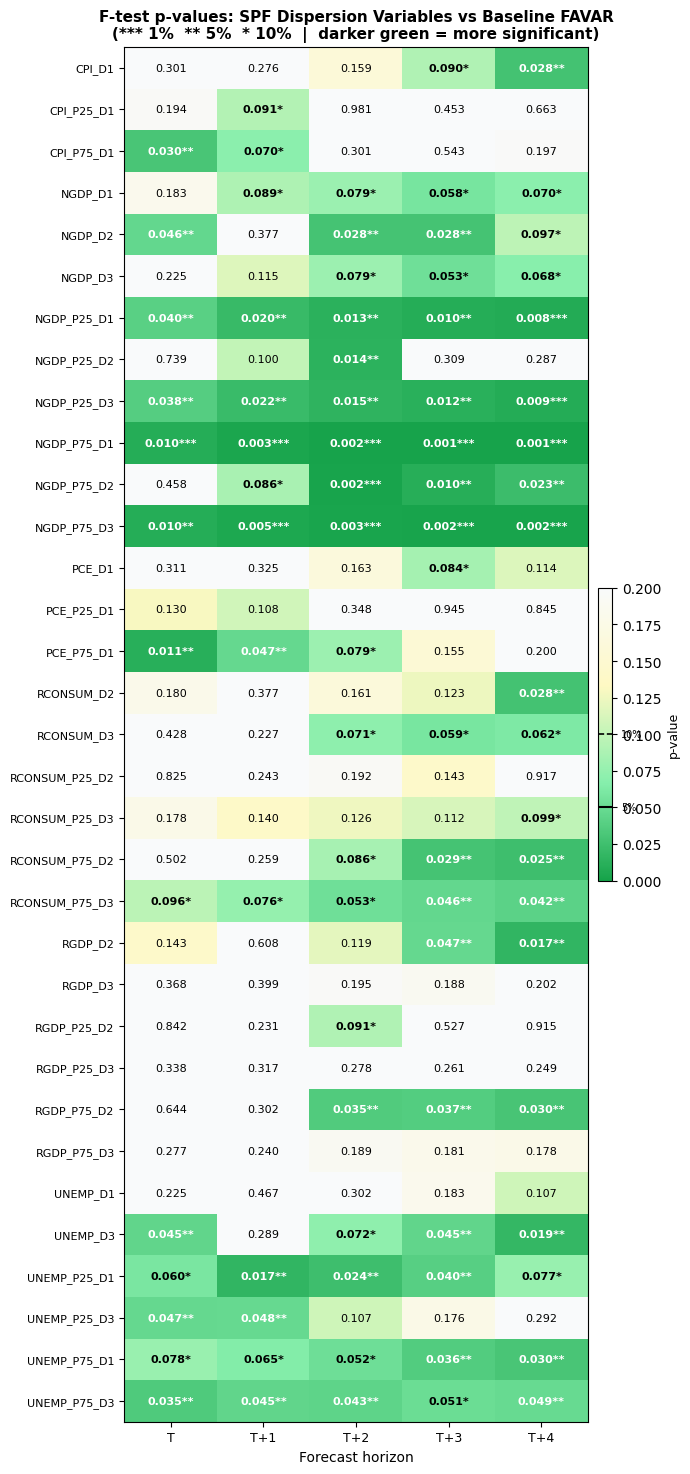

Heatmap saved → spf_significance_heatmap.png
Saved 86 significant variables to sig_spf_vars


In [ ]:
# @title FAVAR Significance Screen — SPF Dispersion Variables (D1 / D2 / D3)
#
# Tests every SPF uncertainty column added by merge_spf_to_macro.py against
# the same PCA baseline used in the Tealbook FAVAR.
# Output: a clean table (Variable | p-value | F-stat | Sig) sorted by p(F).
# No per-variable plots — a single heatmap summarises significance at a glance.

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# 0.  CONFIG  (keep in sync with the Tealbook FAVAR)
# ─────────────────────────────────────────────────────────────────────────────
ROLLING_WINDOW = 10
VAR_THRESHOLD  = 0.999
USE_CENTERING  = True        # set to match your Tealbook run
MIN_PERIODS    = 10
HAC_LAGS       = 4

# Baseline regressors (same as Tealbook FAVAR)
Regressors = [
    'inflation_dev_from_target',
    'unemployment_gap',
    'implied_ffr', 'effective_rate',
    'gdp', 'vix'
]

# SPF dispersion column patterns to scan for
# These are the columns added by merge_spf_to_macro.py (e.g. RGDP_D1(T), CPI_P25_D1(T+1) …)
SPF_PREFIXES = ["RGDP_", "NGDP_", "UNEMP_", "CPI_", "PCE_", "RCONSUM_"]

# ─────────────────────────────────────────────────────────────────────────────
# 1.  IDENTIFY SPF COLUMNS IN df_model
# ─────────────────────────────────────────────────────────────────────────────
df_ols = df_model.copy()

spf_cols = [
    c for c in df_ols.columns
    if any(c.startswith(pfx) for pfx in SPF_PREFIXES)
    and any(tag in c for tag in ["_D1", "_D2", "_D3", "_P25", "_P75"])
]

print(f"SPF dispersion columns found: {len(spf_cols)}")
for c in spf_cols:
    print(f"  {c}  — non-NaN: {df_ols[c].notna().sum()}")
print()

# ─────────────────────────────────────────────────────────────────────────────
# 2.  TARGET + BASELINE PREDICTORS
# ─────────────────────────────────────────────────────────────────────────────
df_ols['target_rate']  = df_ols['fed_funds_rate'].shift(-1)
predictors_base        = [r for r in Regressors if r in df_ols.columns]

all_needed = predictors_base + spf_cols + ['target_rate']

# ─────────────────────────────────────────────────────────────────────────────
# 3.  OPTIONAL CENTERING  (expanding window, no look-ahead)
# ─────────────────────────────────────────────────────────────────────────────
if USE_CENTERING:
    print("Centering: ENABLED (expanding window)")
    for col in predictors_base + spf_cols:
        if col in df_ols.columns:
            exp_mean    = df_ols[col].expanding(min_periods=MIN_PERIODS).mean().shift(1)
            df_ols[col] = df_ols[col] - exp_mean
else:
    print("Centering: DISABLED")

df_clean = df_ols[all_needed].dropna(subset=['target_rate'] + predictors_base).reset_index(drop=True)
y        = df_clean['target_rate']
N        = len(df_clean)
print(f"Sample size (baseline): {N} observations\n")

# ─────────────────────────────────────────────────────────────────────────────
# 4.  PCA BASELINE  (identical to Tealbook FAVAR)
# ─────────────────────────────────────────────────────────────────────────────
def fit_pca(df, cols, var_threshold=VAR_THRESHOLD, label=''):
    X_std    = StandardScaler().fit_transform(df[cols].values)
    pca_full = PCA().fit(X_std)
    eigenvalues  = pca_full.explained_variance_
    kaiser_keep  = int(np.sum(eigenvalues > 1))
    cum_var      = np.cumsum(pca_full.explained_variance_ratio_)
    thresh_keep  = int(np.searchsorted(cum_var, var_threshold) + 1)
    n_kept       = max(kaiser_keep, thresh_keep, 1)
    pca          = PCA(n_components=n_kept)
    scores_arr   = pca.fit_transform(X_std)
    scores       = pd.DataFrame(scores_arr,
                                columns=[f'PC{i+1}_{label}' for i in range(n_kept)],
                                index=df.index)
    print(f"  [{label}] {len(cols)} vars → {n_kept} PCs  "
          f"(cum. var explained: {pca.explained_variance_ratio_.sum():.3f})")
    return scores, pca

print("─" * 55)
print("PCA — baseline (no SPF uncertainty)")
print("─" * 55)
scores_base, _ = fit_pca(df_clean, predictors_base, label='BASE')

hac_kwargs  = {'maxlags': HAC_LAGS}
X_base      = sm.add_constant(scores_base)
ols_base_hac = sm.OLS(y, X_base).fit(cov_type='HAC', cov_kwds=hac_kwargs)
ols_base_f   = sm.OLS(y, X_base).fit()   # plain OLS for F-test

print(f"\nBaseline — R²={ols_base_hac.rsquared:.6f}  "
      f"Adj-R²={ols_base_hac.rsquared_adj:.6f}  "
      f"AIC={ols_base_hac.aic:.1f}  BIC={ols_base_hac.bic:.1f}\n")

# ─────────────────────────────────────────────────────────────────────────────
# 5.  INDIVIDUAL SPF VARIABLE TESTS
# ─────────────────────────────────────────────────────────────────────────────
def sig_stars(p):
    if p < 0.01:  return '***'
    if p < 0.05:  return '**'
    if p < 0.10:  return '*'
    return ''

results = []

print("═" * 70)
print("SCREENING SPF DISPERSION VARIABLES")
print("═" * 70)

for col in spf_cols:
    # Drop rows where this specific SPF column is NaN
    mask    = df_clean[col].notna()
    df_sub  = df_clean[mask].reset_index(drop=True)
    y_sub   = df_sub['target_rate']

    if len(df_sub) < 20:
        print(f"  SKIP {col} — only {len(df_sub)} non-NaN obs")
        continue

    # Re-fit PCA on the sub-sample (same columns, consistent observations)
    scores_sub, _ = fit_pca(df_sub, predictors_base, label='BASE')
    X_base_sub    = sm.add_constant(scores_sub)
    ols_base_sub  = sm.OLS(y_sub, X_base_sub).fit()   # for F-test

    # Augmented model: baseline PCs + SPF variable
    X_aug   = sm.add_constant(pd.concat([scores_sub, df_sub[[col]]], axis=1))
    ols_hac = sm.OLS(y_sub, X_aug).fit(cov_type='HAC', cov_kwds=hac_kwargs)
    ols_f   = sm.OLS(y_sub, X_aug).fit()

    # F-test (augmented vs baseline)
    f_stat, f_pval, _ = ols_f.compare_f_test(ols_base_sub)

    coef  = ols_hac.params[col]
    p_hac = ols_hac.pvalues[col]

    results.append({
        'Variable':  col,
        'N':         len(df_sub),
        'Coef':      round(coef,   4),
        'p(HAC)':    round(p_hac,  4),
        'Sig(HAC)':  sig_stars(p_hac),
        'F-stat':    round(f_stat, 3),
        'p(F)':      round(f_pval, 4),
        'Sig(F)':    sig_stars(f_pval),
        'Adj-R²':    round(ols_hac.rsquared_adj, 6),
    })

# ─────────────────────────────────────────────────────────────────────────────
# 6.  SUMMARY TABLE  — sorted by p(F)
# ─────────────────────────────────────────────────────────────────────────────
df_results = (
    pd.DataFrame(results)
    .sort_values('p(F)')
    .reset_index(drop=True)
)

# Clean display table: 3 main columns + stars
df_display = df_results[['Variable', 'p(HAC)', 'Sig(HAC)', 'F-stat', 'p(F)', 'Sig(F)', 'N']].copy()

print("\n" + "═" * 70)
print("RESULTS — SPF Dispersion Variables vs Baseline FAVAR")
print("  Sorted by p(F-test)   |   *** 1%   ** 5%   * 10%")
print("═" * 70)
print(df_display.to_string(index=False))

# Significant at any level
sig_any = df_results[df_results['Sig(F)'] != '']
print(f"\n✔  Significant variables (F-test, at least 10%): {len(sig_any)} / {len(df_results)}")
for _, row in sig_any.iterrows():
    print(f"   {row['Sig(F)']:3s}  {row['Variable']:<40s}  "
          f"p(F)={row['p(F)']:.4f}   F={row['F-stat']:.3f}   "
          f"p(HAC)={row['p(HAC)']:.4f}   N={row['N']}")

# ─────────────────────────────────────────────────────────────────────────────
# 7.  HEATMAP — p-values across variables × horizons
# ─────────────────────────────────────────────────────────────────────────────

# Parse variable name into base variable and horizon suffix for the heatmap axes
def parse_col(col):
    # e.g. RGDP_D1(T+2) -> var=RGDP_D1, horizon=T+2
    if '(' in col and ')' in col:
        base    = col[:col.index('(')]
        horizon = col[col.index('(')+1 : col.index(')')]
    else:
        base, horizon = col, 'T'
    return base.rstrip('_'), horizon

df_results['_base'], df_results['_horizon'] = zip(*df_results['Variable'].map(parse_col))

# Pivot for heatmap
pivot_pf = df_results.pivot_table(
    index='_base', columns='_horizon', values='p(F)', aggfunc='first'
)

# Order horizons logically
horizon_order = [h for h in ['T', 'T+1', 'T+2', 'T+3', 'T+4'] if h in pivot_pf.columns]
pivot_pf = pivot_pf.reindex(columns=horizon_order)

fig, ax = plt.subplots(figsize=(max(6, len(horizon_order) * 1.4),
                                max(4, len(pivot_pf) * 0.45)))

# Colour map: green = significant, white = not
cmap = mcolors.LinearSegmentedColormap.from_list(
    'sig', ['#16A34A', '#86EFAC', '#FEF9C3', '#F9FAFB'], N=256
)
im = ax.imshow(pivot_pf.values.astype(float), cmap=cmap, vmin=0, vmax=0.20,
               aspect='auto')

# Annotate cells
for i in range(pivot_pf.shape[0]):
    for j in range(pivot_pf.shape[1]):
        val = pivot_pf.iloc[i, j]
        if pd.isna(val):
            txt, color = 'n/a', '#9CA3AF'
        else:
            stars = sig_stars(val)
            txt   = f'{val:.3f}{stars}'
            color = 'white' if val < 0.05 else 'black'
        ax.text(j, i, txt, ha='center', va='center', fontsize=8,
                color=color, fontweight='bold' if val is not None and val < 0.10 else 'normal')

ax.set_xticks(range(len(horizon_order)))
ax.set_xticklabels(horizon_order, fontsize=9)
ax.set_yticks(range(len(pivot_pf)))
ax.set_yticklabels(pivot_pf.index, fontsize=8)
ax.set_xlabel('Forecast horizon', fontsize=10)
ax.set_title('F-test p-values: SPF Dispersion Variables vs Baseline FAVAR\n'
             '(*** 1%  ** 5%  * 10%  |  darker green = more significant)',
             fontsize=11, fontweight='bold')

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('p-value', fontsize=9)
cbar.ax.axhline(0.10, color='black', lw=1.2, ls='--')
cbar.ax.axhline(0.05, color='black', lw=1.5, ls='-')
cbar.ax.text(1.6, 0.10, '10%', va='center', fontsize=7)
cbar.ax.text(1.6, 0.05, '5%',  va='center', fontsize=7)

plt.tight_layout()
plt.savefig('spf_significance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved → spf_significance_heatmap.png")
sig_spf_vars = df_results[df_results['Sig(F)'] != '']['Variable'].tolist()
print(f"Saved {len(sig_spf_vars)} significant variables to sig_spf_vars")

Master sample: 106 obs  |  165 SPF cols  |  1 sentiment cols
Sentiment indicators: ['sharpe_net']


══════════════════════════════════════════════════════════════════════
STEP 2 — Batch Orthogonality Tests
══════════════════════════════════════════════════════════════════════

───────────────────────────────────────────────────────
SPF variable: NGDP_P75_D1(T+4)
───────────────────────────────────────────────────────
  [B] 6 vars → 6 PCs  (cum. var: 1.000)
  Max R² of sentiment on NGDP_P75_D1(T+4): 0.0063  (low overlap)
  F(raw sent)=0.390 p=0.5337     F(resid sent)=0.439 p=0.5094   
  F(raw inter)=13.176 p=0.0000***  F(resid inter)=12.402 p=0.0000***

───────────────────────────────────────────────────────
SPF variable: NGDP_P75_D1(T+3)
───────────────────────────────────────────────────────
  [B] 6 vars → 6 PCs  (cum. var: 1.000)
  Max R² of sentiment on NGDP_P75_D1(T+3): 0.0063  (low overlap)
  F(raw sent)=0.390 p=0.5337     F(resid sent)=0.438 p=0.5097   
  F(raw inter)=13.176 p=0.

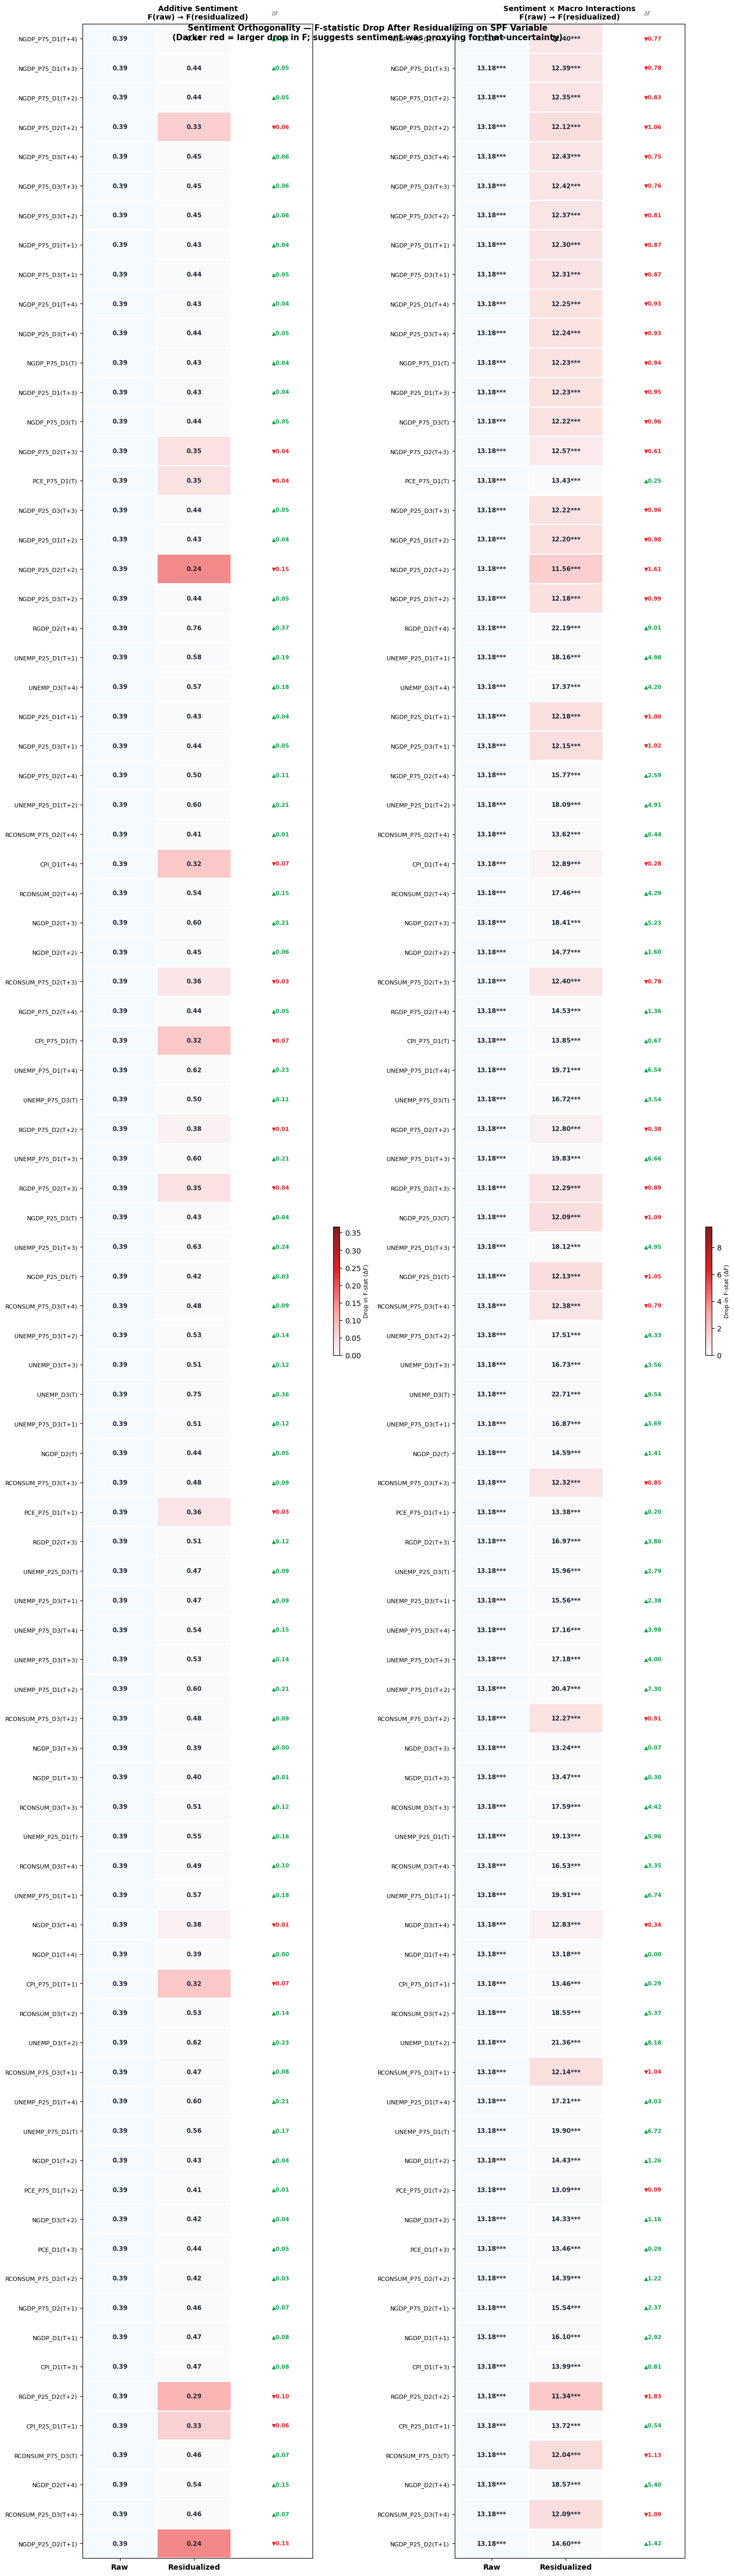

Figure saved → spf_orthogonality_heatmap.png

R² of sentiment on each SPF variable:
  RGDP_D2(T+4)                    R²=0.0192  ΔF=-9.01
  UNEMP_P25_D1(T+1)               R²=0.0123  ΔF=-4.98
  UNEMP_D3(T+4)                   R²=0.0058  ΔF=-4.20
  NGDP_P75_D2(T+4)                R²=0.0038  ΔF=-2.59
  UNEMP_P25_D1(T+2)               R²=0.0156  ΔF=-4.91
  RCONSUM_D2(T+4)                 R²=0.0053  ΔF=-4.29
  NGDP_D2(T+3)                    R²=0.0109  ΔF=-5.23
  UNEMP_P75_D1(T+4)               R²=0.0176  ΔF=-6.54
  UNEMP_P75_D3(T)                 R²=0.0062  ΔF=-3.54
  UNEMP_P75_D1(T+3)               R²=0.0169  ΔF=-6.66
  UNEMP_P25_D1(T+3)               R²=0.0202  ΔF=-4.95
  UNEMP_P75_D3(T+2)               R²=0.0093  ΔF=-4.33
  UNEMP_D3(T+3)                   R²=0.0043  ΔF=-3.56
  UNEMP_D3(T)                     R²=0.0279  ΔF=-9.54
  UNEMP_P75_D3(T+1)               R²=0.0069  ΔF=-3.69
  RGDP_D2(T+3)                    R²=0.0047  ΔF=-3.80
  UNEMP_P25_D3(T)                 R²=0.0044  ΔF=-2.7

In [ ]:
# @title Batch Sentiment Orthogonality Test — All Significant SPF Variables
#
# Workflow:
#   1. Re-runs the SPF significance screen and saves significant variables
#   2. For each significant variable, orthogonalizes sentiment on it
#   3. Summary table: Variable | F(raw sent) | F(resid sent) | F(raw inter) | F(resid inter)
#   4. Heatmap showing F-stat drop (raw → residualized) — colour = magnitude of drop
EXPERIMENT_NOTES = "Dispersion SPF Variables"  # ← describe what differs
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# 0.  CONFIG
# ─────────────────────────────────────────────────────────────────────────────
VAR_THRESHOLD  = 0.999
USE_CENTERING  = True
MIN_PERIODS    = 10
HAC_LAGS       = 4
SIG_THRESHOLD  = 0.10          # p(F) cutoff used in the SPF screening step
EXCLUDE_FROM_INTERACTIONS = {'gdp'}

Regressors = [
    'inflation_dev_from_target',
    'unemployment_gap',
    'implied_ffr', 'effective_rate',
    'gdp', 'vix'
]

SPF_PREFIXES = ["RGDP_", "NGDP_", "UNEMP_", "CPI_", "PCE_", "RCONSUM_"]
hac_kwargs   = {'maxlags': HAC_LAGS}

# ─────────────────────────────────────────────────────────────────────────────
# 1.  HELPERS
# ─────────────────────────────────────────────────────────────────────────────
def sig_stars(p):
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

def fit_pca(df, cols, var_threshold=VAR_THRESHOLD, label='', verbose=False):
    X_std    = StandardScaler().fit_transform(df[cols].values)
    pca_full = PCA().fit(X_std)
    kaiser   = int(np.sum(pca_full.explained_variance_ > 1))
    cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
    thresh   = int(np.searchsorted(cum_var, var_threshold) + 1)
    n_kept   = max(kaiser, thresh, 1)
    pca      = PCA(n_components=n_kept)
    scores   = pd.DataFrame(
        pca.fit_transform(X_std),
        columns=[f'PC{i+1}_{label}' for i in range(n_kept)],
        index=df.index
    )
    if verbose:
        print(f"  [{label}] {len(cols)} vars → {n_kept} PCs  "
              f"(cum. var: {pca.explained_variance_ratio_.sum():.3f})")
    return scores

def ftest(ols_ur, ols_r):
    """Return (f_stat, p_val) from compare_f_test."""
    f, p, _ = ols_ur.compare_f_test(ols_r)
    return round(float(f), 3), round(float(p), 4)

# ─────────────────────────────────────────────────────────────────────────────
# 2.  PREPARE df_clean WITH ALL SPF COLUMNS + SENTIMENT
# ─────────────────────────────────────────────────────────────────────────────
df_ols = df_model.copy()
df_ols['target_rate'] = df_ols['fed_funds_rate'].shift(-1)

predictors_base = [r for r in Regressors if r in df_ols.columns]

spf_cols = [
    c for c in df_ols.columns
    if any(c.startswith(p) for p in SPF_PREFIXES)
    and any(t in c for t in ["_D1", "_D2", "_D3", "_P25", "_P75"])
]

sentiment_predictors = [
    c for name in sentiment_dfs
    for c in sentiment_cols[name]
    if c in df_ols.columns
]

all_needed = list(dict.fromkeys(
    ['target_rate'] + predictors_base + spf_cols + sentiment_predictors
))

if USE_CENTERING:
    for col in predictors_base + spf_cols + sentiment_predictors:
        if col in df_ols.columns:
            exp_mean    = df_ols[col].expanding(min_periods=MIN_PERIODS).mean().shift(1)
            df_ols[col] = df_ols[col] - exp_mean

# Master clean frame (drop only on baseline columns; SPF cols handled per-variable)
df_master = (
    df_ols[all_needed]
    .dropna(subset=['target_rate'] + predictors_base + sentiment_predictors)
    .reset_index(drop=True)
)

print(f"Master sample: {len(df_master)} obs  |  "
      f"{len(spf_cols)} SPF cols  |  "
      f"{len(sentiment_predictors)} sentiment cols")
print(f"Sentiment indicators: {sentiment_predictors}\n")

# ─────────────────────────────────────────────────────────────────────────────
# 4.  STEP 2 — BATCH ORTHOGONALITY TEST
#              For each significant SPF variable:
#                a) Regress each sentiment indicator on the SPF variable → residuals
#                b) Run 4 models (raw/resid × sent/inter) on the sub-sample
#                c) Collect F-stats for the summary table
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "═" * 70)
print("STEP 2 — Batch Orthogonality Tests")
print("═" * 70)

orth_rows = []   # one row per SPF variable

for spf_var in sig_spf_vars:
    print(f"\n{'─'*55}")
    print(f"SPF variable: {spf_var}")
    print(f"{'─'*55}")

    # Sub-sample where this SPF variable is non-NaN
    mask   = df_master[spf_var].notna()
    df_sub = df_master[mask].reset_index(drop=True)
    y_sub  = df_sub['target_rate']
    N_sub  = len(df_sub)

    # Baseline PCA on this sub-sample
    scores_b   = fit_pca(df_sub, predictors_base, label='B', verbose=True)
    X_base_    = sm.add_constant(scores_b)
    ols_base_f_ = sm.OLS(y_sub, X_base_).fit()
    ols_base_h_ = sm.OLS(y_sub, X_base_).fit(cov_type='HAC', cov_kwds=hac_kwargs)

    # ── Orthogonalize each sentiment indicator on spf_var ────────────────────
    residual_cols  = []
    r2_sent_on_spf = {}

    for s in sentiment_predictors:
        X_orth   = sm.add_constant(df_sub[[spf_var]])
        ols_orth = sm.OLS(df_sub[s], X_orth).fit()
        resid_col = f'{s}_resid'
        df_sub[resid_col] = ols_orth.resid
        residual_cols.append(resid_col)
        r2_sent_on_spf[s] = round(ols_orth.rsquared, 4)

    max_r2 = max(r2_sent_on_spf.values())
    print(f"  Max R² of sentiment on {spf_var}: {max_r2:.4f}  "
          f"({'high overlap' if max_r2 > 0.20 else 'low overlap'})")

    # ── Interaction terms ─────────────────────────────────────────────────────
    def make_interactions(sent_list):
        cols, data = [], pd.DataFrame(index=df_sub.index)
        for s in sent_list:
            for m in predictors_base:
                if m in EXCLUDE_FROM_INTERACTIONS: continue
                c = f'{s}_X_{m}'
                data[c] = df_sub[s] * df_sub[m]
                cols.append(c)
        return cols, data

    inter_raw_cols,   inter_raw_df   = make_interactions(sentiment_predictors)
    inter_resid_cols, inter_resid_df = make_interactions(residual_cols)

    # ── Four augmented models ─────────────────────────────────────────────────
    def fit_pair(extra_df, extra_cols):
        X = sm.add_constant(pd.concat([scores_b, extra_df[extra_cols]], axis=1))
        hac = sm.OLS(y_sub, X).fit(cov_type='HAC', cov_kwds=hac_kwargs)
        f_  = sm.OLS(y_sub, X).fit()
        return hac, f_

    ols_raw_s_h,  ols_raw_s_f  = fit_pair(df_sub,         sentiment_predictors)
    ols_raw_i_h,  ols_raw_i_f  = fit_pair(inter_raw_df,   inter_raw_cols)
    ols_res_s_h,  ols_res_s_f  = fit_pair(df_sub,         residual_cols)
    ols_res_i_h,  ols_res_i_f  = fit_pair(inter_resid_df, inter_resid_cols)

    # F-tests vs baseline
    f_raw_s,  p_raw_s  = ftest(ols_raw_s_f, ols_base_f_)
    f_raw_i,  p_raw_i  = ftest(ols_raw_i_f, ols_base_f_)
    f_res_s,  p_res_s  = ftest(ols_res_s_f, ols_base_f_)
    f_res_i,  p_res_i  = ftest(ols_res_i_f, ols_base_f_)

    print(f"  F(raw sent)={f_raw_s:.3f} p={p_raw_s:.4f}{sig_stars(p_raw_s):3s}  "
          f"F(resid sent)={f_res_s:.3f} p={p_res_s:.4f}{sig_stars(p_res_s):3s}")
    print(f"  F(raw inter)={f_raw_i:.3f} p={p_raw_i:.4f}{sig_stars(p_raw_i):3s}  "
          f"F(resid inter)={f_res_i:.3f} p={p_res_i:.4f}{sig_stars(p_res_i):3s}")

    orth_rows.append({
        'SPF Variable':      spf_var,
        'N':                 N_sub,
        'Max R²(sent~SPF)':  max_r2,
        # Raw models
        'F(raw sent)':       f_raw_s,  'p(raw sent)':   p_raw_s,
        'F(raw inter)':      f_raw_i,  'p(raw inter)':  p_raw_i,
        # Residualized models
        'F(resid sent)':     f_res_s,  'p(resid sent)': p_res_s,
        'F(resid inter)':    f_res_i,  'p(resid inter)':p_res_i,
        # Drop in F-stat (positive = sentiment weakened after orthogonalizing)
        'ΔF sent':           round(f_raw_s - f_res_s, 3),
        'ΔF inter':          round(f_raw_i - f_res_i, 3),
        # Significance stars
        'Sig(raw sent)':     sig_stars(p_raw_s),
        'Sig(raw inter)':    sig_stars(p_raw_i),
        'Sig(resid sent)':   sig_stars(p_res_s),
        'Sig(resid inter)':  sig_stars(p_res_i),
    })

# ─────────────────────────────────────────────────────────────────────────────
# 5.  SUMMARY TABLE
# ─────────────────────────────────────────────────────────────────────────────
df_orth = pd.DataFrame(orth_rows)

print("\n" + "═" * 90)
print("ORTHOGONALITY SUMMARY — Significant SPF Variables")
print("  ΔF > 0 means sentiment weakened after residualizing on SPF variable")
print("═" * 90)

display_cols = [
    'SPF Variable',
    'F(raw sent)',   'Sig(raw sent)',
    'F(resid sent)', 'Sig(resid sent)', 'ΔF sent',
    'F(raw inter)',  'Sig(raw inter)',
    'F(resid inter)','Sig(resid inter)','ΔF inter',
]
print(df_orth[display_cols].to_string(index=False))

# Flag variables where sentiment loses significance after orthogonalizing
print("\n── Interpretation ──────────────────────────────────────────────────")
for _, row in df_orth.iterrows():
    v = row['SPF Variable']
    raw_sig_s  = row['p(raw sent)']   < SIG_THRESHOLD
    res_sig_s  = row['p(resid sent)'] < SIG_THRESHOLD
    raw_sig_i  = row['p(raw inter)']  < SIG_THRESHOLD
    res_sig_i  = row['p(resid inter)']< SIG_THRESHOLD

    sent_verdict = (
        "Sentiment LOSES significance → was proxying for SPF uncertainty"
        if raw_sig_s and not res_sig_s else
        "Sentiment RETAINS significance → independent of SPF uncertainty"
        if raw_sig_s and res_sig_s else
        "Sentiment not significant (raw or residualized)"
    )
    inter_verdict = (
        "Interactions LOSE significance → were proxying for SPF uncertainty"
        if raw_sig_i and not res_sig_i else
        "Interactions RETAIN significance → independent of SPF uncertainty"
        if raw_sig_i and res_sig_i else
        "Interactions not significant (raw or residualized)"
    )
    print(f"\n  {v}")
    print(f"    Additive : {sent_verdict}")
    print(f"    Interact : {inter_verdict}")

# ─────────────────────────────────────────────────────────────────────────────
# 6.  HEATMAP — F-stat comparison across SPF variables
#     Left  panel: F(raw sent)   vs F(resid sent)   — colour = ΔF sent
#     Right panel: F(raw inter)  vs F(resid inter)  — colour = ΔF inter
# ─────────────────────────────────────────────────────────────────────────────
n_vars  = len(df_orth)
fig, axes = plt.subplots(1, 2, figsize=(14, max(4, n_vars * 0.55 + 2)))
fig.suptitle(
    'Sentiment Orthogonality — F-statistic Drop After Residualizing on SPF Variable\n'
    '(Darker red = larger drop in F; suggests sentiment was proxying for that uncertainty)',
    fontsize=11, fontweight='bold'
)

def draw_fstat_heatmap(ax, df, f_raw_col, f_res_col, delta_col,
                       sig_raw_col, sig_res_col, title):
    vars_   = df['SPF Variable'].tolist()
    n       = len(vars_)
    raw_f   = df[f_raw_col].values.astype(float)
    res_f   = df[f_res_col].values.astype(float)
    delta   = df[delta_col].values.astype(float)
    sig_raw = df[sig_raw_col].tolist()
    sig_res = df[sig_res_col].tolist()

    # Build 2-column array: col0 = raw F, col1 = resid F
    data = np.column_stack([raw_f, res_f])

    # Colour by ΔF: white = no drop, deep red = large drop
    # Normalise delta to [0, 1] for colour mapping
    max_delta = max(abs(delta).max(), 1e-6)
    cmap_drop = mcolors.LinearSegmentedColormap.from_list(
        'drop', ['#F9FAFB', '#FCA5A5', '#DC2626', '#7F1D1D'], N=256
    )

    # Draw cells manually so we can colour by delta
    col_labels = ['Raw', 'Residualized']
    for row_i, var in enumerate(vars_):
        for col_j in range(2):
            fval  = data[row_i, col_j]
            # Colour intensity driven by delta (only on resid column)
            if col_j == 1:
                intensity = np.clip(delta[row_i] / max_delta, 0, 1)
                rgba = cmap_drop(intensity)
            else:
                rgba = (0.96, 0.98, 1.0, 1.0)   # light blue for raw

            rect = plt.Rectangle(
                [col_j - 0.5, row_i - 0.5], 1, 1,
                facecolor=rgba, edgecolor='white', linewidth=1.5
            )
            ax.add_patch(rect)

            # Text: F-value + stars
            stars = sig_raw[row_i] if col_j == 0 else sig_res[row_i]
            txt   = f'{fval:.2f}{stars}'
            dark  = (col_j == 1 and delta[row_i] / max_delta > 0.5)
            ax.text(col_j, row_i, txt, ha='center', va='center',
                    fontsize=8.5, fontweight='bold',
                    color='white' if dark else '#1F2937')

    # ΔF annotation on the right
    for row_i, (d, var) in enumerate(zip(delta, vars_)):
        color = '#DC2626' if d > 0 else '#16A34A'
        arrow = '▼' if d > 0 else '▲'
        ax.text(2.05, row_i, f'{arrow}{abs(d):.2f}',
                ha='left', va='center', fontsize=7.5,
                color=color, fontweight='bold')

    ax.set_xlim(-0.5, 2.6)
    ax.set_ylim(-0.5, n - 0.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(col_labels, fontsize=10, fontweight='bold')
    ax.set_yticks(range(n))
    ax.set_yticklabels(vars_, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.text(2.05, -0.8, 'ΔF', ha='left', fontsize=8, color='#6B7280')

    # Colourbar
    sm_ = plt.cm.ScalarMappable(
        cmap=cmap_drop, norm=mcolors.Normalize(vmin=0, vmax=max_delta)
    )
    sm_.set_array([])
    cbar = fig.colorbar(sm_, ax=ax, fraction=0.025, pad=0.08)
    cbar.set_label('Drop in F-stat (ΔF)', fontsize=8)

draw_fstat_heatmap(
    axes[0], df_orth,
    'F(raw sent)',  'F(resid sent)',  'ΔF sent',
    'Sig(raw sent)', 'Sig(resid sent)',
    title='Additive Sentiment\nF(raw) → F(residualized)'
)
draw_fstat_heatmap(
    axes[1], df_orth,
    'F(raw inter)', 'F(resid inter)', 'ΔF inter',
    'Sig(raw inter)', 'Sig(resid inter)',
    title='Sentiment × Macro Interactions\nF(raw) → F(residualized)'
)

plt.tight_layout()
plt.savefig('spf_orthogonality_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → spf_orthogonality_heatmap.png")

print("\nR² of sentiment on each SPF variable:")
for _, row in df_orth.iterrows():
    if row['ΔF inter'] < -2:  # large increases (negative drop)
        print(f"  {row['SPF Variable']:<30s}  "
              f"R²={row['Max R²(sent~SPF)']:.4f}  "
              f"ΔF={row['ΔF inter']:.2f}")

Uncertainty proxies (9-meeting rolling var): ['uncertainty_UNEMPF1', 'uncertainty_gRGDPF1', 'uncertainty_gPCPIF1']
Non-NaN rows per uncertainty col:
  uncertainty_UNEMPF1: 85 observations
  uncertainty_gRGDPF1: 85 observations
  uncertainty_gPCPIF1: 85 observations

No-uncertainty regressors : ['inflation_dev_from_target', 'unemployment_gap', 'implied_ffr', 'effective_rate', 'gdp', 'vix']
Uncertainty cols          : ['uncertainty_UNEMPF1', 'uncertainty_gRGDPF1', 'uncertainty_gPCPIF1']

Centering: ENABLED (expanding window, no look-ahead)

Sample size: 75 observations

───────────────────────────────────────────────────────
PCA — Model 1 baseline (no uncertainty regressors)
───────────────────────────────────────────────────────
  [NW] 6 original vars → 6 PCs retained
           Kaiser criterion: 3  |  Variance threshold (100%): 6
           Cumulative variance explained: 1.000


Factor loadings — Model 1 PCA (macro)
                           PC1_NW  PC2_NW  PC3_NW  PC4_NW  PC5_NW  PC6

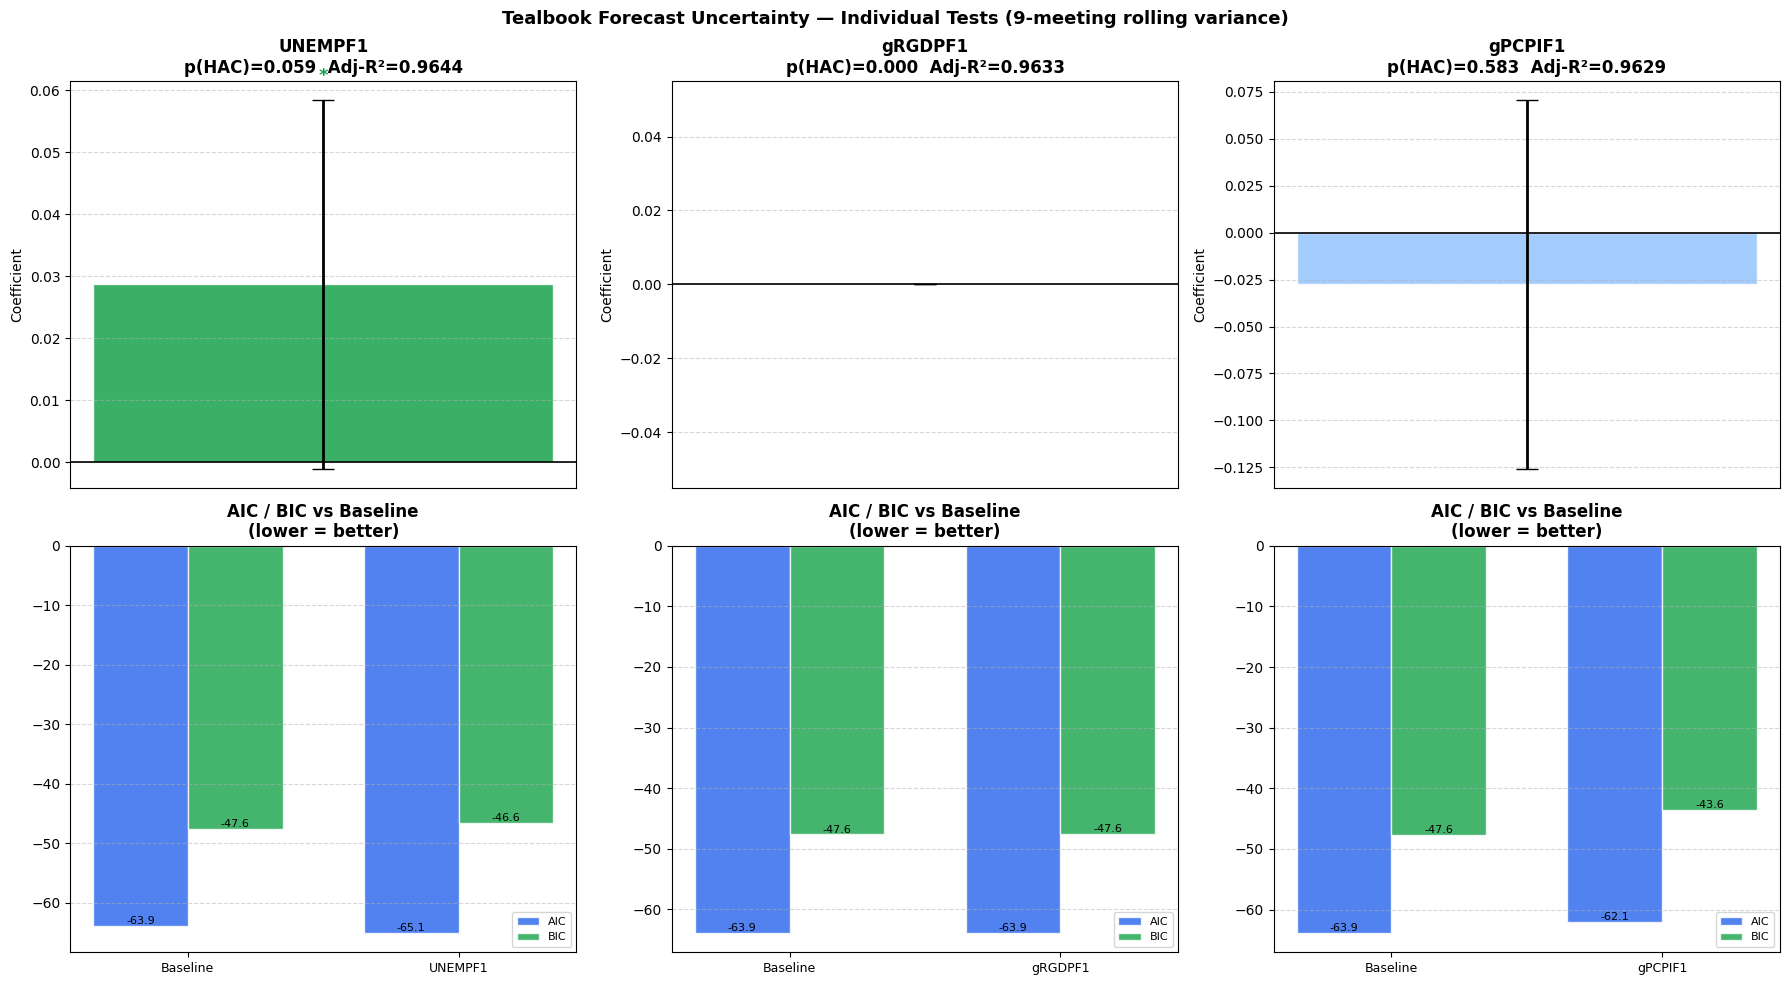

Figure saved.


BASELINE — MODEL 1: PCA Factors only (HAC Robust)
                            OLS Regression Results                            
Dep. Variable:            target_rate   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                     330.9
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           2.84e-48
Time:                        09:17:27   Log-Likelihood:                 38.929
No. Observations:                  75   AIC:                            -63.86
Df Residuals:                      68   BIC:                            -47.64
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

In [ ]:
# @title FAVAR for Tealbook Forecast Uncertainty — Individual Tests
ROLLING_WINDOW = 10  # ← adjust as needed
EXPERIMENT_NOTES = "Tealbook Rolling Uncertainty"  # ← describe what differs

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

df_ols = df_model.copy()

Regressors = [
    'inflation_dev_from_target',
    'unemployment_gap',
    'implied_ffr', 'effective_rate',
    'gdp', 'vix'
]

TEALBOOK_COLS    = ['UNEMPF1', 'gRGDPF1', 'gPCPIF1']
UNCERTAINTY_COLS = [f'uncertainty_{c}' for c in TEALBOOK_COLS]

# ── Compute rolling variance, scaling GDP uncertainty by 1e7 ─────────────────
GDP_SCALE = 1e7

for raw_col, unc_col in zip(TEALBOOK_COLS, UNCERTAINTY_COLS):
    if raw_col in df_ols.columns:
        scale = GDP_SCALE if raw_col == 'gRGDPF1' else 1
        df_ols[unc_col] = (
            df_ols[raw_col]
            .rolling(window=ROLLING_WINDOW, min_periods=3)
            .var()
        ) / scale
    else:
        print(f"  ⚠️  {raw_col} not found in df_model — check Master_Macro.csv")

uncertainty_cols_present = [c for c in UNCERTAINTY_COLS if c in df_ols.columns]
print(f"Uncertainty proxies ({ROLLING_WINDOW}-meeting rolling var): {uncertainty_cols_present}")
print(f"Non-NaN rows per uncertainty col:")
for c in uncertainty_cols_present:
    print(f"  {c}: {df_ols[c].notna().sum()} observations")
print()

# ── Target ────────────────────────────────────────────────────────────────────
df_ols['target_rate'] = df_ols['fed_funds_rate'].shift(-1)

predictors_no_unc = [r for r in Regressors if r in df_ols.columns]

print(f"No-uncertainty regressors : {predictors_no_unc}")
print(f"Uncertainty cols          : {uncertainty_cols_present}\n")

# ── Centering ─────────────────────────────────────────────────────────────────
MIN_PERIODS = 10
all_cols    = list(dict.fromkeys(predictors_no_unc + uncertainty_cols_present))

if USE_CENTERING:
    print("Centering: ENABLED (expanding window, no look-ahead)")
    for col in all_cols:
        exp_mean    = df_ols[col].expanding(min_periods=MIN_PERIODS).mean().shift(1)
        df_ols[col] = df_ols[col] - exp_mean
    df_ols.dropna(subset=all_cols, inplace=True)
else:
    print("Centering: DISABLED")

df_clean = df_ols[['target_rate'] + all_cols].dropna().reset_index(drop=True)
y        = df_clean['target_rate']
N        = len(df_clean)
print(f"\nSample size: {N} observations\n")

# ══════════════════════════════════════════════════════════════════════════════
# PCA — shared baseline across all individual tests
# ══════════════════════════════════════════════════════════════════════════════

VAR_THRESHOLD = 0.999

def fit_pca(df, cols, var_threshold=VAR_THRESHOLD, label=''):
    X_raw    = df[cols].values
    scaler   = StandardScaler()
    X_std    = scaler.fit_transform(X_raw)
    pca_full = PCA().fit(X_std)

    eigenvalues = pca_full.explained_variance_
    kaiser_keep = int(np.sum(eigenvalues > 1))
    cum_var     = np.cumsum(pca_full.explained_variance_ratio_)
    thresh_keep = int(np.searchsorted(cum_var, var_threshold) + 1)
    n_kept      = max(kaiser_keep, thresh_keep, 1)

    pca        = PCA(n_components=n_kept)
    scores_arr = pca.fit_transform(X_std)
    col_names  = [f'PC{i+1}_{label}' for i in range(n_kept)]
    scores     = pd.DataFrame(scores_arr, columns=col_names, index=df.index)
    loadings_df = pd.DataFrame(pca.components_.T, index=cols, columns=col_names)

    print(f"  [{label}] {len(cols)} original vars → {n_kept} PCs retained")
    print(f"           Kaiser criterion: {kaiser_keep}  |  "
          f"Variance threshold ({var_threshold:.0%}): {thresh_keep}")
    print(f"           Cumulative variance explained: "
          f"{pca.explained_variance_ratio_.cumsum()[-1]:.3f}\n")

    return scores, pca, scaler, n_kept, pca.explained_variance_ratio_, loadings_df


print("─" * 55)
print("PCA — Model 1 baseline (no uncertainty regressors)")
print("─" * 55)
scores_nw, pca_nw, scaler_nw, k_nw, var_nw, load_nw = fit_pca(
    df_clean, predictors_no_unc, label='NW'
)

def print_loadings(loadings_df, label):
    print(f"\nFactor loadings — {label}")
    print(loadings_df.round(3).to_string())
    print()

print_loadings(load_nw, "Model 1 PCA (macro)")

# ── Baseline OLS ──────────────────────────────────────────────────────────────
hac_kwargs = {'maxlags': 4}
X_pca_nw   = sm.add_constant(scores_nw)
ols_base   = sm.OLS(y, X_pca_nw).fit(cov_type='HAC', cov_kwds=hac_kwargs)
ols_base_f = sm.OLS(y, X_pca_nw).fit()   # for F-tests

# ══════════════════════════════════════════════════════════════════════════════
# INDIVIDUAL UNCERTAINTY TESTS
# Each uncertainty variable tested separately against the same baseline
# ══════════════════════════════════════════════════════════════════════════════

centering_label = "Expanding Mean" if USE_CENTERING else "No Centering"
ols_indiv       = {}   # store results for plotting

print("\n" + "═" * 70)
print(f"INDIVIDUAL UNCERTAINTY TESTS [{centering_label} | HAC Robust]")
print("═" * 70)

# Summary comparison table
summary_rows = []

for unc_col in uncertainty_cols_present:
    short = unc_col.replace('uncertainty_', '')

    print(f"\n{'─' * 55}")
    print(f"Testing: {unc_col}")
    print(f"{'─' * 55}")

    X_unc   = sm.add_constant(pd.concat([scores_nw, df_clean[[unc_col]]], axis=1))
    ols_hac = sm.OLS(y, X_unc).fit(cov_type='HAC', cov_kwds=hac_kwargs)
    ols_f   = sm.OLS(y, X_unc).fit()

    # F-test vs baseline
    f_stat, f_pval, _ = ols_f.compare_f_test(ols_base_f)
    stars = ('***' if f_pval < 0.01 else '**' if f_pval < 0.05 else
             '*'   if f_pval < 0.10 else '')

    coef  = ols_hac.params[unc_col]
    pval  = ols_hac.pvalues[unc_col]
    ci_lo = ols_hac.conf_int().loc[unc_col, 0]
    ci_hi = ols_hac.conf_int().loc[unc_col, 1]

    print(f"  Coef: {coef:.4f}   p(HAC): {pval:.4f}   "
          f"95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]")
    print(f"  F(1, {int(ols_f.df_resid)}) = {f_stat:.3f}   p(F) = {f_pval:.4f}  {stars}")
    print(f"  R²={ols_hac.rsquared:.6f}  Adj-R²={ols_hac.rsquared_adj:.6f}  "
          f"AIC={ols_hac.aic:.1f}  BIC={ols_hac.bic:.1f}")

    ols_indiv[unc_col] = ols_hac
    summary_rows.append({
        'Variable':  short,
        'Coef':      round(coef,  4),
        'p(HAC)':    round(pval,  4),
        'CI low':    round(ci_lo, 4),
        'CI high':   round(ci_hi, 4),
        'F-stat':    round(f_stat, 3),
        'p(F)':      round(f_pval, 4),
        'Adj-R²':    round(ols_hac.rsquared_adj, 6),
        'AIC':       round(ols_hac.aic, 1),
        'BIC':       round(ols_hac.bic, 1),
        'Sig':       stars,
    })

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "═" * 70)
print("SUMMARY — Individual Uncertainty Tests vs Baseline")
print("═" * 70)
df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))
print(f"\nBaseline — R²={ols_base.rsquared:.6f}  "
      f"Adj-R²={ols_base.rsquared_adj:.6f}  "
      f"AIC={ols_base.aic:.1f}  BIC={ols_base.bic:.1f}")

# ══════════════════════════════════════════════════════════════════════════════
# PLOTS
# ══════════════════════════════════════════════════════════════════════════════

n_unc  = len(uncertainty_cols_present)
fig, axes = plt.subplots(2, max(n_unc, 2), figsize=(6 * n_unc, 10))
fig.suptitle(f'Tealbook Forecast Uncertainty — Individual Tests '
             f'({ROLLING_WINDOW}-meeting rolling variance)',
             fontsize=13, fontweight='bold')

# Top row: coefficient + CI for each uncertainty variable
for i, unc_col in enumerate(uncertainty_cols_present):
    ax   = axes[0, i]
    row  = df_summary[df_summary['Variable'] == unc_col.replace('uncertainty_', '')].iloc[0]
    coef = row['Coef']
    ci_lo, ci_hi = row['CI low'], row['CI high']
    pval = row['p(HAC)']
    color = '#16A34A' if pval < 0.10 else '#93C5FD'

    ax.bar([0], [coef], 0.4, color=color, alpha=0.85, edgecolor='white')
    ax.errorbar([0], [coef],
                yerr=[[coef - ci_lo], [ci_hi - coef]],
                fmt='none', color='black', capsize=8, lw=2)
    ax.axhline(0, color='black', lw=1.2)
    stars = row['Sig']
    if stars:
        ax.text(0, ci_hi + abs(ci_hi) * 0.05, stars,
                ha='center', fontsize=13, color='#16A34A', fontweight='bold')
    ax.set_title(f"{unc_col.replace('uncertainty_', '')}\n"
                 f"p(HAC)={pval:.3f}  Adj-R²={row['Adj-R²']:.4f}",
                 fontweight='bold')
    ax.set_xticks([])
    ax.set_ylabel('Coefficient')
    ax.grid(True, ls='--', alpha=0.5, axis='y')

# Bottom row: AIC / BIC comparison vs baseline
for i, unc_col in enumerate(uncertainty_cols_present):
    ax  = axes[1, i]
    row = df_summary[df_summary['Variable'] == unc_col.replace('uncertainty_', '')].iloc[0]

    labels = ['Baseline', unc_col.replace('uncertainty_', '')]
    aic_vals = [ols_base.aic, row['AIC']]
    bic_vals = [ols_base.bic, row['BIC']]
    x = np.arange(2)
    w = 0.35

    ax.bar(x - w/2, aic_vals, w, color='#2563EB', alpha=0.8,
           edgecolor='white', label='AIC')
    ax.bar(x + w/2, bic_vals, w, color='#16A34A', alpha=0.8,
           edgecolor='white', label='BIC')
    for xi, (a, b) in enumerate(zip(aic_vals, bic_vals)):
        ax.text(xi - w/2, a + 0.3, f'{a:.1f}', ha='center', fontsize=8)
        ax.text(xi + w/2, b + 0.3, f'{b:.1f}', ha='center', fontsize=8)

    ax.set_title('AIC / BIC vs Baseline\n(lower = better)',
                 fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, ls='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.savefig('pca_uncertainty_individual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.\n")

# ── Full OLS summaries ────────────────────────────────────────────────────────
print("\n" + "="*80)
print("BASELINE — MODEL 1: PCA Factors only (HAC Robust)")
print("="*80)
print(ols_base.summary())

for unc_col, ols_obj in ols_indiv.items():
    print("\n" + "="*80)
    print(f"MODEL — PCA + {unc_col} (HAC Robust)")
    print("="*80)
    print(ols_obj.summary())

Sentiment indicators : ['gardner_total']
Uncertainty variable : uncertainty_UNEMPF1

Centering: ENABLED (expanding window, no look-ahead)

Sample size: 76 observations

══════════════════════════════════════════════════════════════════════
STEP 1 — Orthogonalizing sentiment on uncertainty
══════════════════════════════════════════════════════════════════════
  gardner_total ~ uncertainty_UNEMPF1
    Coef=-0.2363  p=0.0000  R²=0.2659
    → Residual col: 'gardner_total_resid'
    → 26.6% of sentiment variance explained by uncertainty

───────────────────────────────────────────────────────
STEP 2 — Macro PCA (shared baseline)
───────────────────────────────────────────────────────
  [M] 6 vars → 6 PCs retained  (Kaiser: 3, Threshold: 6)
           Cumulative variance explained: 1.000

Interaction terms (raw sentiment × macro)         : 5
Interaction terms (residualized sentiment × macro): 5

───────────────────────────────────────────────────────
STEP 3 — OLS Models
─────────────────────

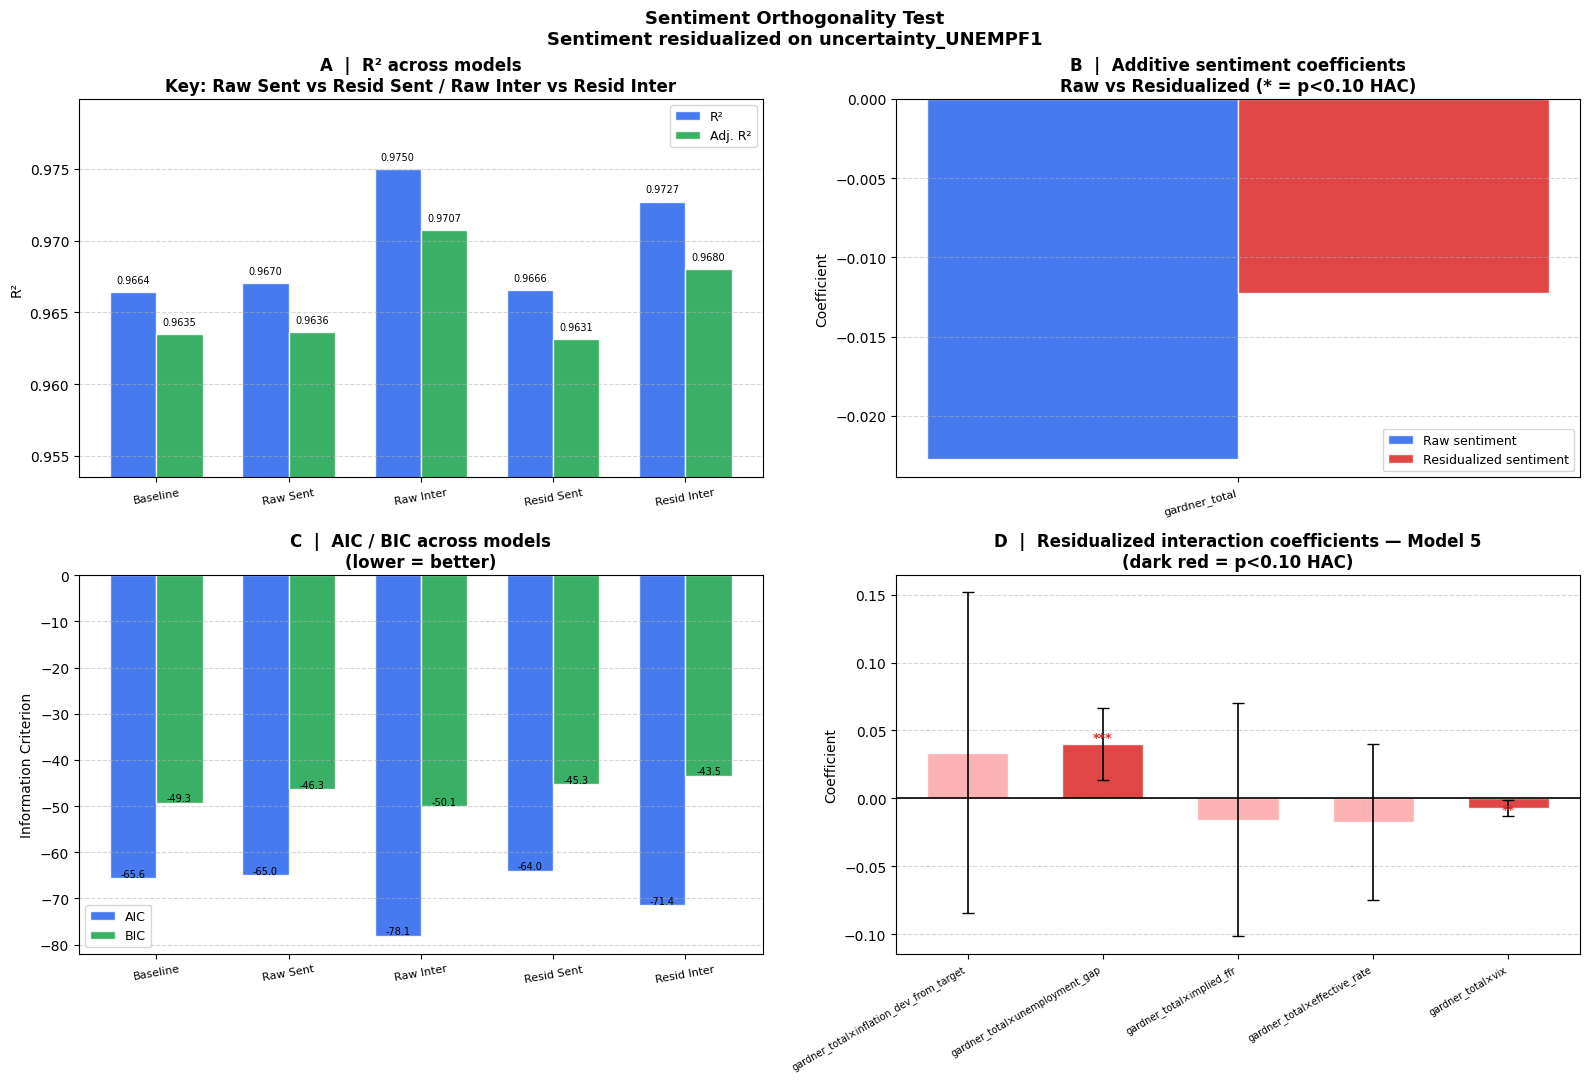

Figure saved.



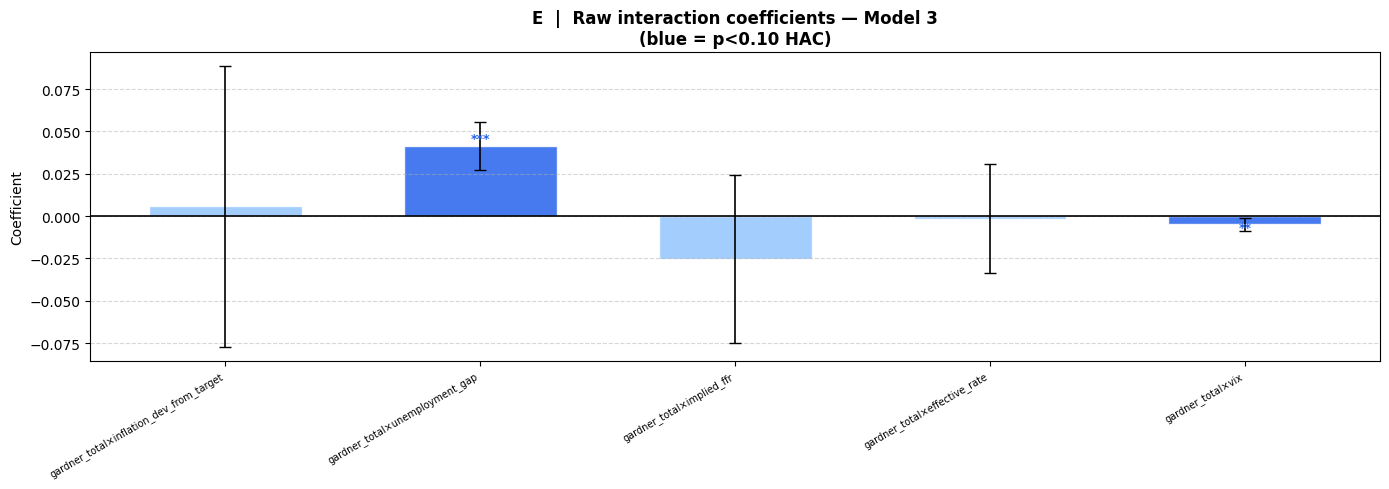

Raw interaction figure saved.


MODEL 1 — Baseline: Macro PCA only (HAC Robust)
                            OLS Regression Results                            
Dep. Variable:            target_rate   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     333.8
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           6.42e-49
Time:                        09:28:21   Log-Likelihood:                 39.806
No. Observations:                  76   AIC:                            -65.61
Df Residuals:                      69   BIC:                            -49.30
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

In [ ]:
# @title Sentiment Orthogonality Test — Does sentiment just capture UNEMP uncertainty?
EXPERIMENT_NOTES = "Testing significance of sentiment against UNEMP rolling var"  # ← describe what differs

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# ── The uncertainty variable that was significant ─────────────────────────────
UNCERTAINTY_VAR = 'uncertainty_UNEMPF1'   # ← change if needed

df_ols = df_model.copy()

Regressors = [
    'inflation_dev_from_target',
    'unemployment_gap',
    'implied_ffr', 'effective_rate',
    'gdp', 'vix'
]

# ── Recompute uncertainty (same as before) ────────────────────────────────────
ROLLING_WINDOW = 10
GDP_SCALE      = 1e7

TEALBOOK_COLS    = ['UNEMPF1', 'gRGDPF1', 'gPCPIF1']
UNCERTAINTY_COLS = [f'uncertainty_{c}' for c in TEALBOOK_COLS]

for raw_col, unc_col in zip(TEALBOOK_COLS, UNCERTAINTY_COLS):
    if raw_col in df_ols.columns:
        scale = GDP_SCALE if raw_col == 'gRGDPF1' else 1
        df_ols[unc_col] = (
            df_ols[raw_col]
            .rolling(window=ROLLING_WINDOW, min_periods=3)
            .var()
        ) / scale

# ── Sentiment columns ─────────────────────────────────────────────────────────
sentiment_predictors = [
    c for name in sentiment_dfs
    for c in sentiment_cols[name]
    if c in df_ols.columns
]
print(f"Sentiment indicators : {sentiment_predictors}")
print(f"Uncertainty variable : {UNCERTAINTY_VAR}\n")

# ── Target ────────────────────────────────────────────────────────────────────
df_ols['target_rate'] = df_ols['fed_funds_rate'].shift(-1)

# ── All columns needed ────────────────────────────────────────────────────────
predictors_macro = [r for r in Regressors if r in df_ols.columns]
all_cols = list(dict.fromkeys(
    predictors_macro + sentiment_predictors + [UNCERTAINTY_VAR]
))

# ── Centering ─────────────────────────────────────────────────────────────────
MIN_PERIODS = 10

if USE_CENTERING:
    print("Centering: ENABLED (expanding window, no look-ahead)")
    for col in all_cols:
        exp_mean    = df_ols[col].expanding(min_periods=MIN_PERIODS).mean().shift(1)
        df_ols[col] = df_ols[col] - exp_mean
    df_ols.dropna(subset=all_cols, inplace=True)
else:
    print("Centering: DISABLED")

df_clean = df_ols[['target_rate'] + all_cols].dropna().reset_index(drop=True)
y        = df_clean['target_rate']
N        = len(df_clean)
print(f"\nSample size: {N} observations\n")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Regress each sentiment indicator on uncertainty_UNEMPF1
#          Residuals = sentiment orthogonalized to uncertainty
#          If residuals lose predictive power → sentiment was just proxying
#          for uncertainty. If they retain it → sentiment contains independent
#          information beyond what uncertainty captures.
# ══════════════════════════════════════════════════════════════════════════════

print("═" * 70)
print("STEP 1 — Orthogonalizing sentiment on uncertainty")
print("═" * 70)

residual_cols = []

for sent_col in sentiment_predictors:
    X_orth   = sm.add_constant(df_clean[[UNCERTAINTY_VAR]])
    ols_orth = sm.OLS(df_clean[sent_col], X_orth).fit()

    resid_col = f'{sent_col}_resid'
    df_clean[resid_col] = ols_orth.resid
    residual_cols.append(resid_col)

    r2   = ols_orth.rsquared
    coef = ols_orth.params[UNCERTAINTY_VAR]
    pval = ols_orth.pvalues[UNCERTAINTY_VAR]
    print(f"  {sent_col} ~ {UNCERTAINTY_VAR}")
    print(f"    Coef={coef:.4f}  p={pval:.4f}  R²={r2:.4f}")
    print(f"    → Residual col: '{resid_col}'")
    print(f"    → {r2*100:.1f}% of sentiment variance explained by uncertainty\n")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Shared macro PCA baseline
# ══════════════════════════════════════════════════════════════════════════════

VAR_THRESHOLD = 0.999

def fit_pca(df, cols, var_threshold=VAR_THRESHOLD, label=''):
    X_raw    = df[cols].values
    scaler   = StandardScaler()
    X_std    = scaler.fit_transform(X_raw)
    pca_full = PCA().fit(X_std)

    eigenvalues = pca_full.explained_variance_
    kaiser_keep = int(np.sum(eigenvalues > 1))
    cum_var     = np.cumsum(pca_full.explained_variance_ratio_)
    thresh_keep = int(np.searchsorted(cum_var, var_threshold) + 1)
    n_kept      = max(kaiser_keep, thresh_keep, 1)

    pca        = PCA(n_components=n_kept)
    scores_arr = pca.fit_transform(X_std)
    col_names  = [f'PC{i+1}_{label}' for i in range(n_kept)]
    scores     = pd.DataFrame(scores_arr, columns=col_names, index=df.index)
    loadings_df = pd.DataFrame(pca.components_.T, index=cols, columns=col_names)

    print(f"  [{label}] {len(cols)} vars → {n_kept} PCs retained  "
          f"(Kaiser: {kaiser_keep}, Threshold: {thresh_keep})")
    print(f"           Cumulative variance explained: "
          f"{pca.explained_variance_ratio_.cumsum()[-1]:.3f}\n")

    return scores, pca, scaler, n_kept, pca.explained_variance_ratio_, loadings_df


print("─" * 55)
print("STEP 2 — Macro PCA (shared baseline)")
print("─" * 55)
scores_macro, _, _, k_macro, _, load_macro = fit_pca(
    df_clean, predictors_macro, label='M'
)

hac_kwargs = {'maxlags': 4}

# ── Interaction terms: RAW sentiment × macro ──────────────────────────────────
EXCLUDE_FROM_INTERACTIONS = {'gdp'}

interact_raw_cols = []
interact_raw_df   = pd.DataFrame(index=df_clean.index)
for s in sentiment_predictors:
    for m in predictors_macro:
        if m in EXCLUDE_FROM_INTERACTIONS:
            continue
        col = f'{s}_X_{m}'
        interact_raw_df[col] = df_clean[s] * df_clean[m]
        interact_raw_cols.append(col)

print(f"Interaction terms (raw sentiment × macro)         : {len(interact_raw_cols)}")

# ── Interaction terms: RESIDUALIZED sentiment × macro ────────────────────────
interact_resid_cols = []
interact_resid_df   = pd.DataFrame(index=df_clean.index)
for s in residual_cols:
    for m in predictors_macro:
        if m in EXCLUDE_FROM_INTERACTIONS:
            continue
        col = f'{s}_X_{m}'
        interact_resid_df[col] = df_clean[s] * df_clean[m]
        interact_resid_cols.append(col)

print(f"Interaction terms (residualized sentiment × macro): {len(interact_resid_cols)}\n")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Five models
#
#   Model 1 — Baseline       : macro PCA only
#   Model 2 — Raw sent       : macro PCA + raw sentiment
#   Model 3 — Raw inter      : macro PCA + raw sentiment × macro interactions
#   Model 4 — Resid sent     : macro PCA + residualized sentiment
#   Model 5 — Resid inter    : macro PCA + residualized sentiment × macro interactions
#
# Key comparisons:
#   Model 2 vs Model 4 — does sentiment lose additive power after orthogonalization?
#   Model 3 vs Model 5 — do interaction effects survive orthogonalization?
#   If Model 4/5 weaker than Model 2/3 → uncertainty explains part of sentiment
#   If Model 4/5 lose significance entirely → sentiment was just proxying uncertainty
#   If Model 4/5 retain significance → sentiment carries independent information
# ══════════════════════════════════════════════════════════════════════════════

print("─" * 55)
print("STEP 3 — OLS Models")
print("─" * 55)

X_base        = sm.add_constant(scores_macro)
X_raw_sent    = sm.add_constant(
    pd.concat([scores_macro, df_clean[sentiment_predictors]], axis=1)
)
X_raw_inter   = sm.add_constant(
    pd.concat([scores_macro, interact_raw_df], axis=1)
)
X_resid_sent  = sm.add_constant(
    pd.concat([scores_macro, df_clean[residual_cols]], axis=1)
)
X_resid_inter = sm.add_constant(
    pd.concat([scores_macro, interact_resid_df], axis=1)
)

ols_base        = sm.OLS(y, X_base).fit(cov_type='HAC', cov_kwds=hac_kwargs)
ols_raw_sent    = sm.OLS(y, X_raw_sent).fit(cov_type='HAC', cov_kwds=hac_kwargs)
ols_raw_inter   = sm.OLS(y, X_raw_inter).fit(cov_type='HAC', cov_kwds=hac_kwargs)
ols_resid_sent  = sm.OLS(y, X_resid_sent).fit(cov_type='HAC', cov_kwds=hac_kwargs)
ols_resid_inter = sm.OLS(y, X_resid_inter).fit(cov_type='HAC', cov_kwds=hac_kwargs)

# For F-tests (standard OLS)
ols_base_f        = sm.OLS(y, X_base).fit()
ols_raw_sent_f    = sm.OLS(y, X_raw_sent).fit()
ols_raw_inter_f   = sm.OLS(y, X_raw_inter).fit()
ols_resid_sent_f  = sm.OLS(y, X_resid_sent).fit()
ols_resid_inter_f = sm.OLS(y, X_resid_inter).fit()

# ── Model comparison ──────────────────────────────────────────────────────────
centering_label = "Expanding Mean" if USE_CENTERING else "No Centering"

comparison_df = pd.DataFrame({
    'Metric': ['R-squared', 'Adj. R-squared', 'AIC', 'BIC', 'N params'],
    'Model 1 — Baseline': [
        round(ols_base.rsquared,        6),
        round(ols_base.rsquared_adj,    6),
        round(ols_base.aic,             3),
        round(ols_base.bic,             3),
        k_macro + 1,
    ],
    'Model 2 — Raw Sent': [
        round(ols_raw_sent.rsquared,     6),
        round(ols_raw_sent.rsquared_adj, 6),
        round(ols_raw_sent.aic,          3),
        round(ols_raw_sent.bic,          3),
        k_macro + len(sentiment_predictors) + 1,
    ],
    'Model 3 — Raw Inter': [
        round(ols_raw_inter.rsquared,     6),
        round(ols_raw_inter.rsquared_adj, 6),
        round(ols_raw_inter.aic,          3),
        round(ols_raw_inter.bic,          3),
        k_macro + len(interact_raw_cols) + 1,
    ],
    'Model 4 — Resid Sent': [
        round(ols_resid_sent.rsquared,     6),
        round(ols_resid_sent.rsquared_adj, 6),
        round(ols_resid_sent.aic,          3),
        round(ols_resid_sent.bic,          3),
        k_macro + len(residual_cols) + 1,
    ],
    'Model 5 — Resid Inter': [
        round(ols_resid_inter.rsquared,     6),
        round(ols_resid_inter.rsquared_adj, 6),
        round(ols_resid_inter.aic,          3),
        round(ols_resid_inter.bic,          3),
        k_macro + len(interact_resid_cols) + 1,
    ],
})

print(f"\n══ MODEL COMPARISON [{centering_label} | HAC Robust] ══")
print(comparison_df.to_string(index=False))
print("\nNote: Lower AIC/BIC = better fit penalised for complexity.")

# ── F-tests ───────────────────────────────────────────────────────────────────
def run_ftest(ols_ur, ols_r, n_restrictions, label):
    f_stat, f_pval, _ = ols_ur.compare_f_test(ols_r)
    stars = ('***' if f_pval < 0.01 else '**' if f_pval < 0.05 else
             '*'   if f_pval < 0.10 else '')
    print(f"  {label}")
    print(f"  F({n_restrictions}, {int(ols_ur.df_resid)}) = "
          f"{f_stat:.3f}   p = {f_pval:.4f}  {stars}")
    if   f_pval < 0.01: print("  → Jointly significant at 1%")
    elif f_pval < 0.05: print("  → Jointly significant at 5%")
    elif f_pval < 0.10: print("  → Jointly significant at 10%")
    else:               print("  → NOT jointly significant")
    print()
    return f_stat, f_pval

print("\n" + "─" * 60)
print("F-TESTS")
print("─" * 60)

run_ftest(ols_raw_sent_f,    ols_base_f, len(sentiment_predictors),
          "Test A: raw sentiment = 0  (Model 2 vs Model 1)")

run_ftest(ols_raw_inter_f,   ols_base_f, len(interact_raw_cols),
          "Test B: raw interactions = 0  (Model 3 vs Model 1)")

run_ftest(ols_resid_sent_f,  ols_base_f, len(residual_cols),
          "Test C: residualized sentiment = 0  (Model 4 vs Model 1)")

run_ftest(ols_resid_inter_f, ols_base_f, len(interact_resid_cols),
          "Test D: residualized interactions = 0  (Model 5 vs Model 1)")

# ── Interpretation guide ──────────────────────────────────────────────────────
print("─" * 60)
print("INTERPRETATION")
print("─" * 60)
_, fa_raw_sent   = run_ftest(ols_raw_sent_f,   ols_base_f,
                             len(sentiment_predictors),   "Raw sentiment")
_, fa_resid_sent = run_ftest(ols_resid_sent_f, ols_base_f,
                             len(residual_cols),          "Residualized sentiment")
_, fa_raw_inter   = run_ftest(ols_raw_inter_f,   ols_base_f,
                              len(interact_raw_cols),   "Raw interactions")
_, fa_resid_inter = run_ftest(ols_resid_inter_f, ols_base_f,
                              len(interact_resid_cols), "Residualized interactions")

print("\n  Additive sentiment channel:")
if fa_raw_sent >= 0.10:
    print("    Raw sentiment not significant → no additive predictive power.")
elif fa_resid_sent >= 0.10:
    print("    ✓ Sentiment loses additive significance after orthogonalization.")
    print("    → Additive channel WAS proxying for uncertainty.")
else:
    print("    ✓ Sentiment RETAINS additive significance after orthogonalization.")
    print("    → Additive channel contains independent information.")

print("\n  Interaction channel:")
if fa_raw_inter >= 0.10:
    print("    Raw interactions not significant → no interaction predictive power.")
elif fa_resid_inter >= 0.10:
    print("    ✓ Interactions lose significance after orthogonalization.")
    print("    → Interaction channel WAS proxying for uncertainty.")
else:
    print("    ✓ Interactions RETAIN significance after orthogonalization.")
    print("    → Interaction channel contains independent information.")
print()

# ══════════════════════════════════════════════════════════════════════════════
# PLOTS
# ══════════════════════════════════════════════════════════════════════════════

model_labels = ['Baseline', 'Raw Sent', 'Raw Inter', 'Resid Sent', 'Resid Inter']
ols_list     = [ols_base, ols_raw_sent, ols_raw_inter, ols_resid_sent, ols_resid_inter]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Sentiment Orthogonality Test\n'
             f'Sentiment residualized on {UNCERTAINTY_VAR}',
             fontsize=13, fontweight='bold')

# Panel A: R² / Adj-R² across all five models
ax_a = axes[0, 0]
r2_vals     = [o.rsquared     for o in ols_list]
r2_adj_vals = [o.rsquared_adj for o in ols_list]
x_m = np.arange(len(model_labels))
w_m = 0.35

b1 = ax_a.bar(x_m - w_m/2, r2_vals,     w_m, color='#2563EB',
              alpha=0.85, edgecolor='white', label='R²')
b2 = ax_a.bar(x_m + w_m/2, r2_adj_vals, w_m, color='#16A34A',
              alpha=0.85, edgecolor='white', label='Adj. R²')
for bar in list(b1) + list(b2):
    ax_a.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.0005,
              f'{bar.get_height():.4f}',
              ha='center', va='bottom', fontsize=7)
ax_a.set_title('A  |  R² across models\n'
               'Key: Raw Sent vs Resid Sent / Raw Inter vs Resid Inter',
               fontweight='bold')
ax_a.set_xticks(x_m)
ax_a.set_xticklabels(model_labels, fontsize=8, rotation=10)
ax_a.set_ylabel('R²')
ax_a.set_ylim(min(r2_adj_vals) * 0.99, max(r2_vals) * 1.005)
ax_a.legend(fontsize=9)
ax_a.grid(True, ls='--', alpha=0.5, axis='y')

# Panel B: Raw vs residualized sentiment coefficients (additive)
ax_b = axes[0, 1]
x_s   = np.arange(len(sentiment_predictors))
w_s   = 0.35
raw_coefs   = [ols_raw_sent.params[c]    for c in sentiment_predictors]
resid_coefs = [ols_resid_sent.params[c]  for c in residual_cols]
raw_pvals   = [ols_raw_sent.pvalues[c]   for c in sentiment_predictors]
resid_pvals = [ols_resid_sent.pvalues[c] for c in residual_cols]

ax_b.bar(x_s - w_s/2, raw_coefs,   w_s, color='#2563EB',
         alpha=0.85, edgecolor='white', label='Raw sentiment')
ax_b.bar(x_s + w_s/2, resid_coefs, w_s, color='#DC2626',
         alpha=0.85, edgecolor='white', label='Residualized sentiment')
for xi, (rc, rp) in enumerate(zip(raw_coefs, raw_pvals)):
    stars = '***' if rp < 0.01 else '**' if rp < 0.05 else '*' if rp < 0.10 else ''
    if stars:
        ax_b.text(xi - w_s/2, rc + abs(rc) * 0.05, stars,
                  ha='center', fontsize=10, color='#2563EB', fontweight='bold')
for xi, (rc, rp) in enumerate(zip(resid_coefs, resid_pvals)):
    stars = '***' if rp < 0.01 else '**' if rp < 0.05 else '*' if rp < 0.10 else ''
    if stars:
        ax_b.text(xi + w_s/2, rc + abs(rc) * 0.05, stars,
                  ha='center', fontsize=10, color='#DC2626', fontweight='bold')
ax_b.axhline(0, color='black', lw=1.2)
ax_b.set_title('B  |  Additive sentiment coefficients\n'
               'Raw vs Residualized (* = p<0.10 HAC)',
               fontweight='bold')
ax_b.set_xticks(x_s)
ax_b.set_xticklabels(sentiment_predictors, fontsize=8, rotation=15, ha='right')
ax_b.set_ylabel('Coefficient')
ax_b.legend(fontsize=9)
ax_b.grid(True, ls='--', alpha=0.5, axis='y')

# Panel C: AIC / BIC across all five models
ax_c = axes[1, 0]
aic_vals = [o.aic for o in ols_list]
bic_vals = [o.bic for o in ols_list]

ax_c.bar(x_m - w_m/2, aic_vals, w_m, color='#2563EB',
         alpha=0.85, edgecolor='white', label='AIC')
ax_c.bar(x_m + w_m/2, bic_vals, w_m, color='#16A34A',
         alpha=0.85, edgecolor='white', label='BIC')
for xi, (a, b) in enumerate(zip(aic_vals, bic_vals)):
    ax_c.text(xi - w_m/2, a + 0.3, f'{a:.1f}', ha='center', fontsize=7)
    ax_c.text(xi + w_m/2, b + 0.3, f'{b:.1f}', ha='center', fontsize=7)
ax_c.set_title('C  |  AIC / BIC across models\n(lower = better)',
               fontweight='bold')
ax_c.set_xticks(x_m)
ax_c.set_xticklabels(model_labels, fontsize=8, rotation=10)
ax_c.set_ylabel('Information Criterion')
ax_c.legend(fontsize=9)
ax_c.grid(True, ls='--', alpha=0.5, axis='y')

# Panel D: Residualized interaction coefficients (Model 5)
ax_d = axes[1, 1]
inter_params = ols_resid_inter.params[interact_resid_cols]
inter_pvals  = ols_resid_inter.pvalues[interact_resid_cols]
inter_ci     = ols_resid_inter.conf_int().loc[interact_resid_cols]
x_i          = np.arange(len(interact_resid_cols))
bcols_i      = ['#DC2626' if p < 0.10 else '#FCA5A5' for p in inter_pvals]

ax_d.bar(x_i, inter_params, 0.6, color=bcols_i, alpha=0.85, edgecolor='white')
ax_d.errorbar(x_i, inter_params,
              yerr=[inter_params - inter_ci.iloc[:, 0],
                    inter_ci.iloc[:, 1] - inter_params],
              fmt='none', color='black', capsize=4, lw=1.2)
ax_d.axhline(0, color='black', lw=1.2)
for xi, (coef, pv) in enumerate(zip(inter_params, inter_pvals)):
    stars = '***' if pv < 0.01 else '**' if pv < 0.05 else '*' if pv < 0.10 else ''
    if stars:
        offset = max(abs(inter_params)) * 0.05
        ax_d.text(xi, coef + (offset if coef >= 0 else -offset * 2),
                  stars, ha='center', fontsize=9,
                  color='#DC2626', fontweight='bold')
ax_d.set_title('D  |  Residualized interaction coefficients — Model 5\n'
               '(dark red = p<0.10 HAC)',
               fontweight='bold')
ax_d.set_xticks(x_i)
ax_d.set_xticklabels([c.replace('_resid_X_', '×').replace('_resid', '')
                      for c in interact_resid_cols],
                     fontsize=7, rotation=30, ha='right')
ax_d.set_ylabel('Coefficient')
ax_d.grid(True, ls='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.savefig('sentiment_orthogonality_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.\n")

# ── Separate figure: Raw interaction coefficients (Model 3) ───────────────────
fig2, ax_e = plt.subplots(figsize=(14, 5))
inter_params_raw = ols_raw_inter.params[interact_raw_cols]
inter_pvals_raw  = ols_raw_inter.pvalues[interact_raw_cols]
inter_ci_raw     = ols_raw_inter.conf_int().loc[interact_raw_cols]
x_e              = np.arange(len(interact_raw_cols))
bcols_e          = ['#2563EB' if p < 0.10 else '#93C5FD' for p in inter_pvals_raw]

ax_e.bar(x_e, inter_params_raw, 0.6, color=bcols_e, alpha=0.85, edgecolor='white')
ax_e.errorbar(x_e, inter_params_raw,
              yerr=[inter_params_raw - inter_ci_raw.iloc[:, 0],
                    inter_ci_raw.iloc[:, 1] - inter_params_raw],
              fmt='none', color='black', capsize=4, lw=1.2)
ax_e.axhline(0, color='black', lw=1.2)
for xi, (coef, pv) in enumerate(zip(inter_params_raw, inter_pvals_raw)):
    stars = '***' if pv < 0.01 else '**' if pv < 0.05 else '*' if pv < 0.10 else ''
    if stars:
        offset = max(abs(inter_params_raw)) * 0.05
        ax_e.text(xi, coef + (offset if coef >= 0 else -offset * 2),
                  stars, ha='center', fontsize=9,
                  color='#2563EB', fontweight='bold')
ax_e.set_title('E  |  Raw interaction coefficients — Model 3\n'
               '(blue = p<0.10 HAC)',
               fontweight='bold')
ax_e.set_xticks(x_e)
ax_e.set_xticklabels([c.replace('_X_', '×') for c in interact_raw_cols],
                     fontsize=7, rotation=30, ha='right')
ax_e.set_ylabel('Coefficient')
ax_e.grid(True, ls='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.savefig('raw_interactions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Raw interaction figure saved.\n")

# ── Full OLS summaries ────────────────────────────────────────────────────────
for title, ols_obj in [
    ("MODEL 1 — Baseline: Macro PCA only (HAC Robust)",
     ols_base),
    ("MODEL 2 — Raw Sentiment: Macro PCA + Raw Sentiment (HAC Robust)",
     ols_raw_sent),
    ("MODEL 3 — Raw Interactions: Macro PCA + Raw Sentiment×Macro (HAC Robust)",
     ols_raw_inter),
    ("MODEL 4 — Residualized Sentiment: Macro PCA + Sentiment⊥Uncertainty (HAC Robust)",
     ols_resid_sent),
    ("MODEL 5 — Residualized Interactions: Macro PCA + (Sentiment⊥Uncertainty)×Macro (HAC Robust)",
     ols_resid_inter),
]:
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)
    print(ols_obj.summary())

No-wedge regressors : ['inflation_dev_from_target', 'unemployment_gap', 'implied_ffr', 'effective_rate', 'gdp', 'vix']
Wedge cols          : ['actual_wedge_UNEMPF1', 'actual_wedge_gRGDPF1', 'actual_wedge_gPCPIF1']

Centering: ENABLED (expanding window, no look-ahead)

Sample size: 109 observations

───────────────────────────────────────────────────────
PCA — Model 1 (no wedge regressors)
───────────────────────────────────────────────────────
  [NW] 6 original vars → 6 PCs retained
           Kaiser criterion: 2  |  Variance threshold (100%): 6
           Cumulative variance explained: 1.000


Factor loadings — Model 1 PCA (macro + sentiment)
                           PC1_NW  PC2_NW  PC3_NW  PC4_NW  PC5_NW  PC6_NW
inflation_dev_from_target   0.355   0.261  -0.602  -0.592  -0.283  -0.114
unemployment_gap           -0.155   0.564   0.659  -0.403  -0.247   0.032
implied_ffr                 0.556  -0.137   0.167   0.038  -0.177   0.782
effective_rate              0.523  -0.109   0.268   

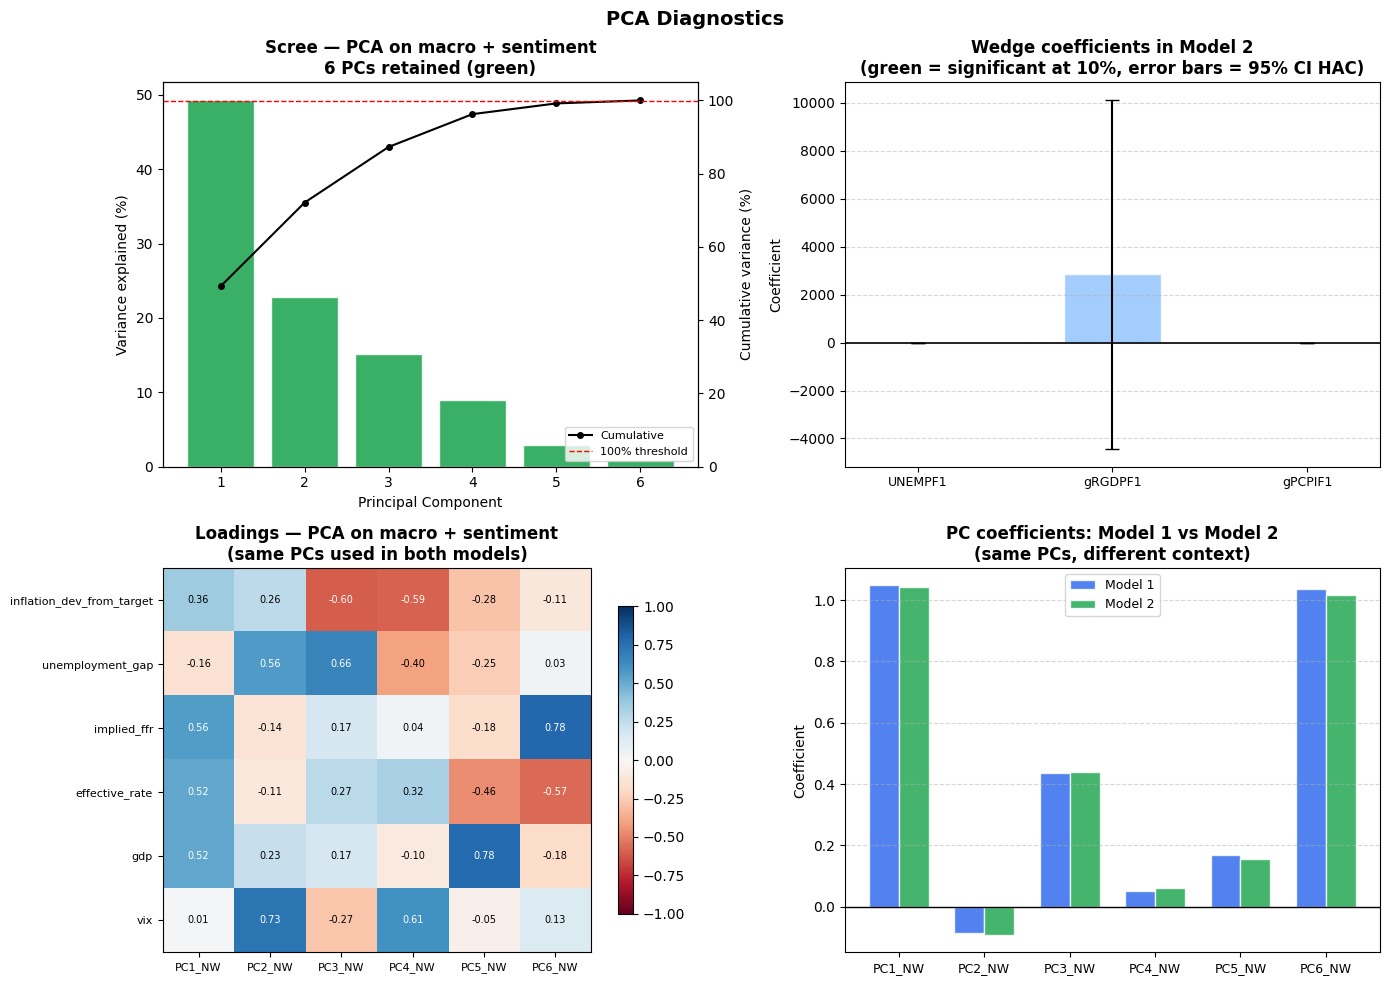

PCA diagnostics saved.


MODEL 1 SUMMARY — PCA Factors only (HAC Robust)
                            OLS Regression Results                            
Dep. Variable:            target_rate   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     5203.
Date:                Wed, 01 Apr 2026   Prob (F-statistic):          1.94e-124
Time:                        08:04:02   Log-Likelihood:                 52.801
No. Observations:                 109   AIC:                            -91.60
Df Residuals:                     102   BIC:                            -72.76
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

In [ ]:
#@title FAVAR for (Teal-SPF) Wedge
EXPERIMENT_NOTES = "Testing Significance of Teal-SPF wedge"  # ← describe what differs

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

df_ols = df_model.copy()

Regressors = [
    'inflation_dev_from_target',
    'unemployment_gap',
    'implied_ffr',"effective_rate",
    'gdp', "vix"
]

Wedge_Regressors = [
    'actual_wedge_UNEMPF1',
    'actual_wedge_gRGDPF1',
    'actual_wedge_gPCPIF1',
]

# Target: next-meeting rate
df_ols['target_rate'] = df_ols['fed_funds_rate'].shift(-1)


predictors_no_wedge   = [r for r in Regressors       if r in df_ols.columns]
predictors_wedge_cols = [w for w in Wedge_Regressors  if w in df_ols.columns]
predictors_with_wedge = predictors_no_wedge + predictors_wedge_cols

all_cols = list(dict.fromkeys(predictors_with_wedge))   # dedup, preserve order

print(f"No-wedge regressors : {predictors_no_wedge}")
print(f"Wedge cols          : {predictors_wedge_cols}\n")

# ── Centering ─────────────────────────────────────────────────────────────────
MIN_PERIODS = 10

if USE_CENTERING:
    print("Centering: ENABLED (expanding window, no look-ahead)")
    for col in all_cols:
        exp_mean   = df_ols[col].expanding(min_periods=MIN_PERIODS).mean().shift(1)
        df_ols[col] = df_ols[col] - exp_mean
    df_ols.dropna(subset=all_cols, inplace=True)
else:
    print("Centering: DISABLED")

df_clean = df_ols[['target_rate'] + all_cols].dropna().reset_index(drop=True)
y        = df_clean['target_rate']
N        = len(df_clean)
print(f"\nSample size: {N} observations\n")

# ══════════════════════════════════════════════════════════════════════════════
# PCA
#
# IMPORTANT — look-ahead note:
#   PCA is fit here on the FULL sample. For a research/in-sample comparison
#   this is standard. If this were a walk-forward forecasting exercise, PCA
#   would need to be re-fit inside each expanding window (no look-ahead).
#   The full-sample fit is appropriate here because the goal is to understand
#   the factor structure of the regressors, not to simulate live trading.
#
# Procedure:
#   1. Standardise each regressor set to zero mean, unit variance
#      (PCA is sensitive to scale — raw bps vs % vs index levels would
#       produce misleading factor loadings without standardisation)
#   2. Fit PCA separately for the no-wedge set and the with-wedge set
#   3. Retain components by the Kaiser criterion (eigenvalue > 1)
#      AND a minimum variance explained threshold (VAR_THRESHOLD)
#   4. Use the retained principal components as regressors in OLS
# ══════════════════════════════════════════════════════════════════════════════

VAR_THRESHOLD = 0.999  # retain enough PCs to explain at least 80% of variance
                        # ← adjust if you want more/fewer components

def fit_pca(df, cols, var_threshold=VAR_THRESHOLD, label=''):
    """
    Standardise, fit PCA, retain components by Kaiser + variance threshold.

    Returns
    -------
    scores      : pd.DataFrame  — PC scores for each observation (shape N × k)
    pca         : fitted PCA object
    scaler      : fitted StandardScaler object
    n_kept      : int — number of components retained
    var_exp     : array — cumulative variance explained by retained components
    loadings_df : pd.DataFrame — factor loadings (original vars × PCs)
    """
    X_raw = df[cols].values

    scaler  = StandardScaler()
    X_std   = scaler.fit_transform(X_raw)

    pca_full = PCA()
    pca_full.fit(X_std)

    # Kaiser criterion: eigenvalue > 1 (in standardised space, eigenvalue = explained var × n_vars)
    eigenvalues  = pca_full.explained_variance_
    kaiser_keep  = int(np.sum(eigenvalues > 1))

    # Variance threshold: retain minimum PCs to hit VAR_THRESHOLD
    cum_var      = np.cumsum(pca_full.explained_variance_ratio_)
    thresh_keep  = int(np.searchsorted(cum_var, var_threshold) + 1)

    n_kept = max(kaiser_keep, thresh_keep, 1)   # always keep at least 1

    pca = PCA(n_components=n_kept)
    scores_arr = pca.fit_transform(X_std)

    col_names   = [f'PC{i+1}_{label}' for i in range(n_kept)]
    scores      = pd.DataFrame(scores_arr, columns=col_names, index=df.index)

    loadings_df = pd.DataFrame(
        pca.components_.T,
        index=cols,
        columns=col_names
    )

    print(f"  [{label}] {len(cols)} original vars → {n_kept} PCs retained")
    print(f"           Kaiser criterion: {kaiser_keep}  |  "
          f"Variance threshold ({var_threshold:.0%}): {thresh_keep}")
    print(f"           Cumulative variance explained: "
          f"{pca.explained_variance_ratio_.cumsum()[-1]:.3f}\n")

    return scores, pca, scaler, n_kept, pca.explained_variance_ratio_, loadings_df


print("─" * 55)
print("PCA — Model 1 (no wedge regressors)")
print("─" * 55)
scores_nw, pca_nw, scaler_nw, k_nw, var_nw, load_nw = fit_pca(
    df_clean, predictors_no_wedge, label='NW'
)

# ── Print factor loadings ─────────────────────────────────────────────────────
def print_loadings(loadings_df, label):
    print(f"\nFactor loadings — {label}")
    print(loadings_df.round(3).to_string())
    print()

print_loadings(load_nw, "Model 1 PCA (macro + sentiment)")
print()
print("Model 2 uses the SAME PCA scores as Model 1 plus raw wedge regressors.")
print("Wedges are NOT included in the PCA — their incremental contribution")
print("is tested directly as explicit regressors alongside the PC scores.\n")

# ── OLS on PCA factors ────────────────────────────────────────────────────────
hac_kwargs = {'maxlags': 4}

# Model 1: PCA scores only
X_pca_nw = sm.add_constant(scores_nw)

# Model 2: same PCA scores + raw wedge regressors appended as explicit columns
# This keeps the PCA collinearity fix for the macro block while letting the
# wedge coefficients be directly estimated and individually interpretable.
X_pca_ww = sm.add_constant(
    pd.concat([scores_nw, df_clean[predictors_wedge_cols]], axis=1)
)

ols_pca_nw = sm.OLS(y, X_pca_nw).fit(cov_type='HAC', cov_kwds=hac_kwargs)
ols_pca_ww = sm.OLS(y, X_pca_ww).fit(cov_type='HAC', cov_kwds=hac_kwargs)

# ── Model comparison ──────────────────────────────────────────────────────────
centering_label = "Expanding Mean" if USE_CENTERING else "No Centering"

comparison_df = pd.DataFrame({
    'Metric': ['R-squared', 'Adj. R-squared', 'AIC', 'BIC', 'N params'],
    'Model 1 — PCA only': [
        round(ols_pca_nw.rsquared,     6),
        round(ols_pca_nw.rsquared_adj, 6),
        round(ols_pca_nw.aic,          3),
        round(ols_pca_nw.bic,          3),
        k_nw + 1,   # PCs + constant
    ],
    'Model 2 — PCA + raw wedges': [
        round(ols_pca_ww.rsquared,     6),
        round(ols_pca_ww.rsquared_adj, 6),
        round(ols_pca_ww.aic,          3),
        round(ols_pca_ww.bic,          3),
        k_nw + len(predictors_wedge_cols) + 1,   # PCs + wedges + constant
    ],
})

print(f"══ MODEL COMPARISON — PCA Factors [{centering_label} | HAC Robust] ══")
print(comparison_df.to_string(index=False))
print("\nNote: Lower AIC/BIC = better fit penalised for complexity.")

# ── F-test: do raw wedge regressors jointly add power beyond the PCA factors? ─
# Model 1 (restricted)  : PCA scores only
# Model 2 (unrestricted): same PCA scores + raw wedge regressors
# Both are estimated by standard OLS (no HAC) for the F-test statistic.
# This is now a proper nested test — Model 1 is literally a restricted version
# of Model 2 with wedge coefficients constrained to zero.

print("\n" + "─" * 28)
print("F-test: raw wedge regressors = 0 after controlling for PCA factors")
print("─" * 28)

ols_r  = sm.OLS(y, X_pca_nw).fit()    # restricted
ols_ur = sm.OLS(y, X_pca_ww).fit()    # unrestricted

f_stat, f_pval, _ = ols_ur.compare_f_test(ols_r)
n_restrictions    = len(predictors_wedge_cols)

print(f"H0: {predictors_wedge_cols} jointly = 0")
print(f"F({n_restrictions}, {int(ols_ur.df_resid)}) = {f_stat:.3f}   p = {f_pval:.4f}")
if   f_pval < 0.01: print("*** Wedges jointly significant at 1%")
elif f_pval < 0.05: print("**  Wedges jointly significant at 5%")
elif f_pval < 0.10: print("*   Wedges jointly significant at 10%")
else:               print("    Wedges NOT jointly significant")

# ══════════════════════════════════════════════════════════════════════════════
# SCREE PLOTS + LOADING HEATMAPS
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('PCA Diagnostics', fontsize=14, fontweight='bold')

def scree_plot(ax, var_ratios, n_kept, title):
    n = len(var_ratios)
    ax.bar(range(1, n+1), var_ratios * 100,
           color=['#16A34A' if i < n_kept else '#93C5FD' for i in range(n)],
           alpha=0.85, edgecolor='white')
    ax2 = ax.twinx()
    ax2.plot(range(1, n+1), np.cumsum(var_ratios) * 100,
             color='black', marker='o', ms=4, lw=1.5, label='Cumulative')
    ax2.axhline(y=VAR_THRESHOLD * 100, color='red', ls='--', lw=1,
                label=f'{VAR_THRESHOLD:.0%} threshold')
    ax2.set_ylabel('Cumulative variance (%)')
    ax2.set_ylim(0, 105)
    ax2.legend(fontsize=8, loc='lower right')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Principal Component')
    ax.set_ylabel('Variance explained (%)')
    ax.set_xticks(range(1, n+1))

pca_full_nw = PCA().fit(StandardScaler().fit_transform(
    df_clean[predictors_no_wedge].values))

# Panel A: Scree plot (only one PCA now)
scree_plot(axes[0, 0], pca_full_nw.explained_variance_ratio_, k_nw,
           f'Scree — PCA on macro + sentiment\n{k_nw} PCs retained (green)')

# Panel B: Wedge coefficients from Model 2 with 95% CI
ax_w = axes[0, 1]
wedge_params  = ols_pca_ww.params[predictors_wedge_cols]
wedge_ci      = ols_pca_ww.conf_int().loc[predictors_wedge_cols]
wedge_pvals   = ols_pca_ww.pvalues[predictors_wedge_cols]
x_pos         = np.arange(len(predictors_wedge_cols))
bar_colors    = ['#16A34A' if p < 0.10 else '#93C5FD' for p in wedge_pvals]
ax_w.bar(x_pos, wedge_params, 0.5, color=bar_colors, alpha=0.85, edgecolor='white')
ax_w.errorbar(x_pos, wedge_params,
              yerr=[wedge_params - wedge_ci.iloc[:, 0],
                    wedge_ci.iloc[:, 1] - wedge_params],
              fmt='none', color='black', capsize=5, lw=1.5)
ax_w.axhline(y=0, color='black', lw=1.2)
for xi, (coef, pv) in enumerate(zip(wedge_params, wedge_pvals)):
    label = '***' if pv < 0.01 else '**' if pv < 0.05 else '*' if pv < 0.10 else ''
    if label:
        ax_w.text(xi, coef + (0.001 if coef >= 0 else -0.002),
                  label, ha='center', fontsize=11, color='#16A34A', fontweight='bold')
ax_w.set_title('Wedge coefficients in Model 2\n(green = significant at 10%, error bars = 95% CI HAC)',
               fontweight='bold')
ax_w.set_xticks(x_pos)
ax_w.set_xticklabels([w.replace('actual_wedge_', '') for w in predictors_wedge_cols],
                     fontsize=9)
ax_w.set_ylabel('Coefficient')
ax_w.grid(True, ls='--', alpha=0.5, axis='y')

def loading_heatmap(ax, loadings_df, title):
    im = ax.imshow(loadings_df.values, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(loadings_df.columns)))
    ax.set_xticklabels(loadings_df.columns, fontsize=8)
    ax.set_yticks(range(len(loadings_df.index)))
    ax.set_yticklabels(loadings_df.index, fontsize=8)
    for i in range(len(loadings_df.index)):
        for j in range(len(loadings_df.columns)):
            ax.text(j, i, f'{loadings_df.values[i, j]:.2f}',
                    ha='center', va='center', fontsize=7,
                    color='white' if abs(loadings_df.values[i, j]) > 0.5 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(title, fontweight='bold')

loading_heatmap(axes[1, 0], load_nw,
                'Loadings — PCA on macro + sentiment\n(same PCs used in both models)')

# Panel D: PC coefficient comparison between Model 1 and Model 2
ax_pc = axes[1, 1]
pc_cols = scores_nw.columns.tolist()
x_pos2  = np.arange(len(pc_cols))
w       = 0.35
for i, (label, ols_obj, color) in enumerate([
    ('Model 1', ols_pca_nw, '#2563EB'),
    ('Model 2', ols_pca_ww, '#16A34A'),
]):
    coefs = [ols_obj.params[c] for c in pc_cols]
    ax_pc.bar(x_pos2 + (i - 0.5) * w, coefs, w,
              color=color, alpha=0.8, edgecolor='white', label=label)
ax_pc.axhline(y=0, color='black', lw=1)
ax_pc.set_title('PC coefficients: Model 1 vs Model 2\n(same PCs, different context)',
                fontweight='bold')
ax_pc.set_xticks(x_pos2)
ax_pc.set_xticklabels(pc_cols, fontsize=9)
ax_pc.set_ylabel('Coefficient')
ax_pc.legend(fontsize=9)
ax_pc.grid(True, ls='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.savefig('pca_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print("PCA diagnostics saved.\n")

# ── OLS summaries ─────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("MODEL 1 SUMMARY — PCA Factors only (HAC Robust)")
print("="*80)
print(ols_pca_nw.summary())

print("\n" + "="*80)
print("MODEL 2 SUMMARY — PCA Factors + Raw Wedge Regressors (HAC Robust)")
print("="*80)
print(ols_pca_ww.summary())

Macro regressors    : ['inflation_dev_from_target', 'unemployment_gap', 'implied_ffr', 'effective_rate', 'gdp', 'vix']
Sentiment indicators: ['sharpe_net']

Centering: ENABLED (expanding window, no look-ahead)

Sample size: 106 observations

Interaction terms created: 5
Excluded from interactions: {'gdp'}

───────────────────────────────────────────────────────
PCA — macro regressors (shared across all 3 models)
───────────────────────────────────────────────────────
  [M] 6 vars → 6 PCs retained
           Kaiser: 2  |  Var threshold (99.9%): 6
           Cumulative variance explained: 1.0000


Factor loadings — Macro PCA
                           PC1_M  PC2_M  PC3_M  PC4_M  PC5_M  PC6_M
inflation_dev_from_target  0.333  0.277  0.717 -0.439 -0.324 -0.034
unemployment_gap          -0.153  0.592 -0.567 -0.494 -0.242  0.048
implied_ffr                0.557 -0.131 -0.201  0.030 -0.105  0.788
effective_rate             0.526 -0.107 -0.303  0.253 -0.509 -0.545
gdp                        0.

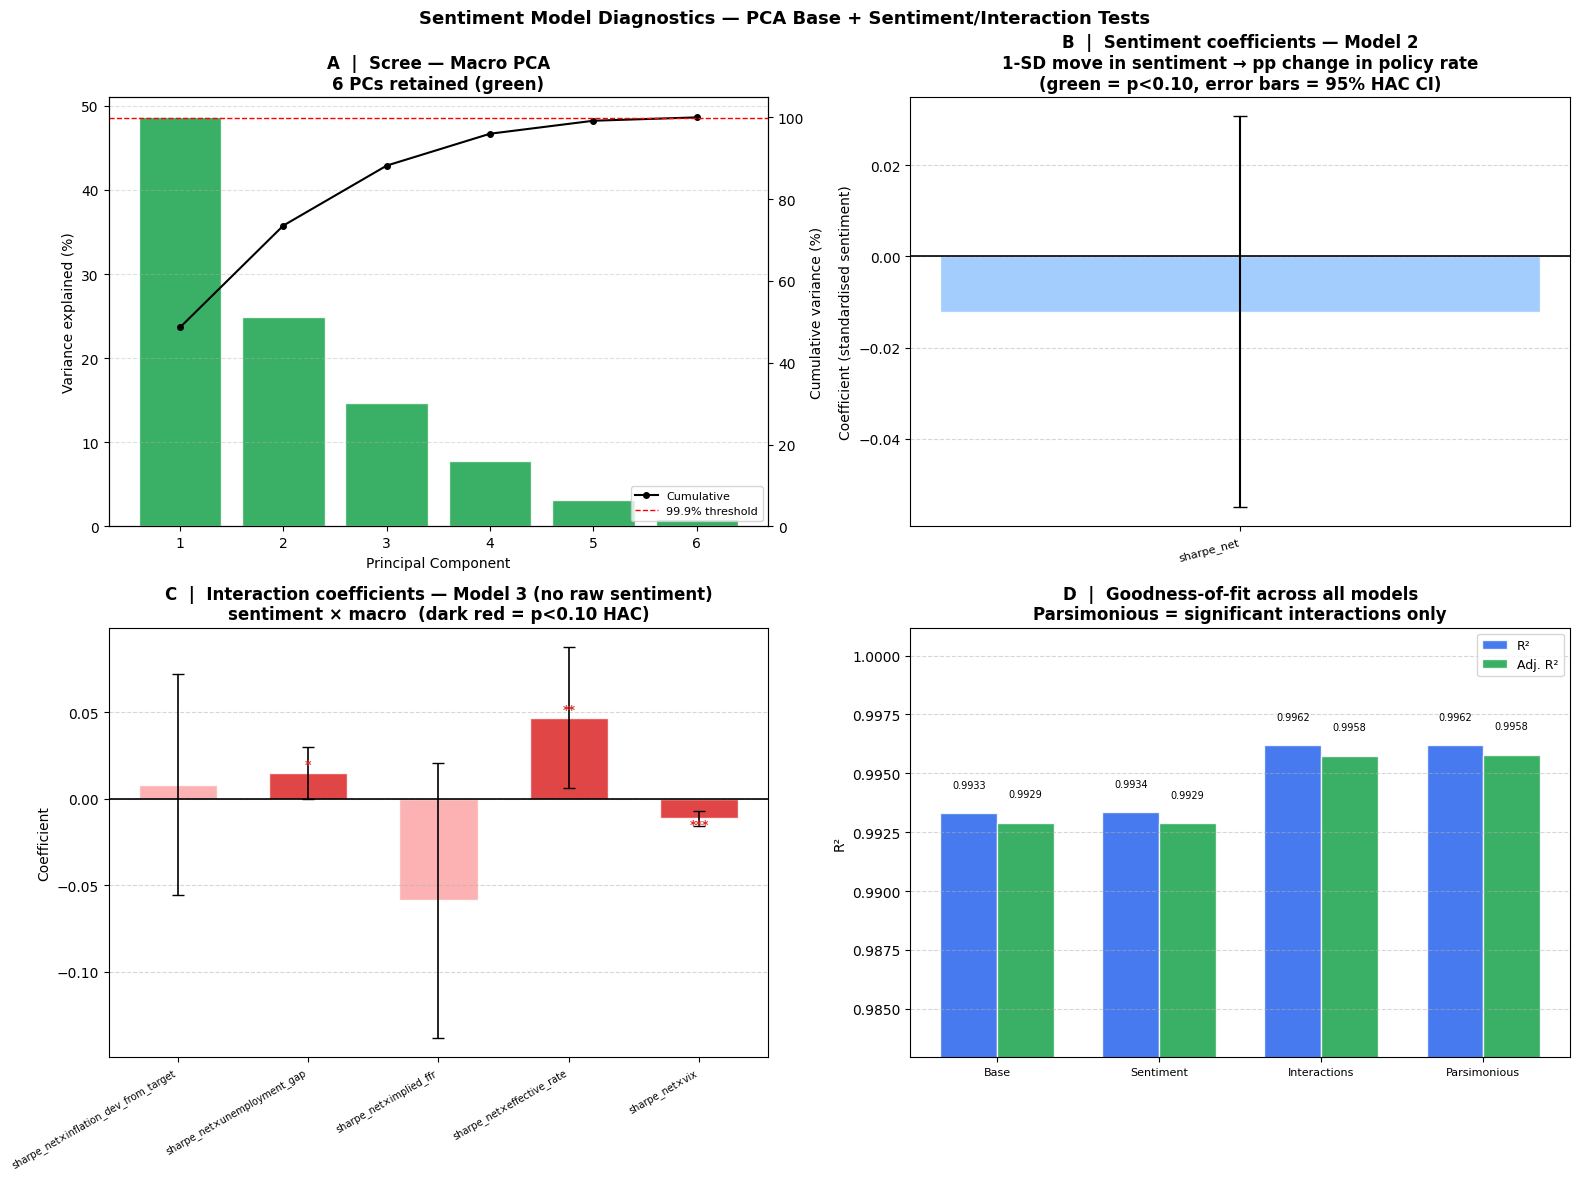

Figure saved.



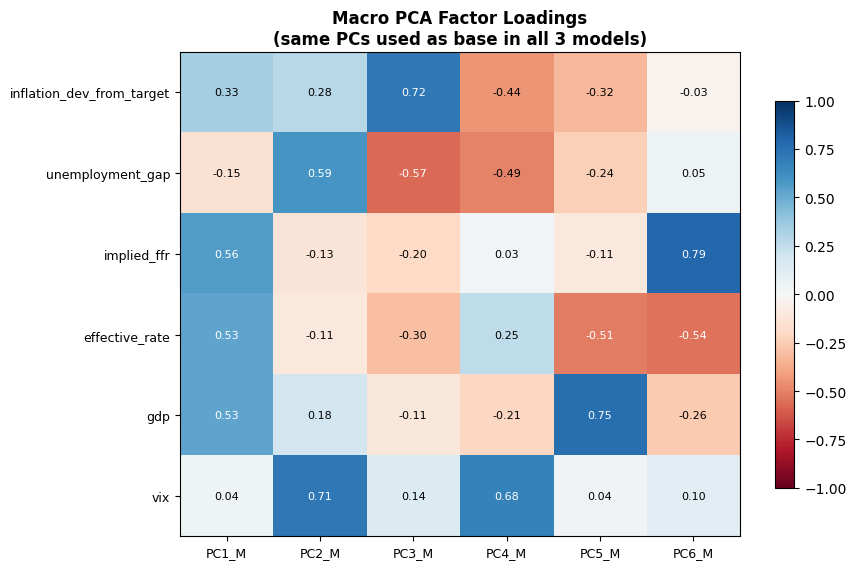

Loading heatmap saved.


MODEL 1 — Base: Macro PCA Factors only (HAC Robust)
                            OLS Regression Results                            
Dep. Variable:            target_rate   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     5891.
Date:                Fri, 03 Apr 2026   Prob (F-statistic):          4.94e-124
Time:                        12:42:35   Log-Likelihood:                 48.197
No. Observations:                 106   AIC:                            -82.39
Df Residuals:                      99   BIC:                            -63.75
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

In [ ]:
#@title FAVAR Sentiment and Interactions
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

df_ols = df_model.copy()

Regressors = [
    'inflation_dev_from_target',
    'unemployment_gap',
    'implied_ffr',
    'effective_rate',
    'gdp',
    'vix',
]

# Target: next-meeting rate
df_ols['target_rate'] = df_ols['fed_funds_rate'].shift(-1)

# ── Sentiment ─────────────────────────────────────────────────────────────────
sentiment_predictors = [
    c for name in sentiment_dfs
    for c in sentiment_cols[name]
    if c in df_ols.columns
]

predictors_macro = [r for r in Regressors if r in df_ols.columns]
all_cols         = list(dict.fromkeys(predictors_macro + sentiment_predictors))

print(f"Macro regressors    : {predictors_macro}")
print(f"Sentiment indicators: {sentiment_predictors}\n")

assert len(predictors_macro) == len([r for r in Regressors if r in df_ols.columns]), \
    f"Missing macro cols: {set(Regressors) - set(df_ols.columns)}"
assert len(sentiment_predictors) > 0, \
    "No sentiment columns found — check sentiment_dfs and sentiment_cols"

# ── Centering ─────────────────────────────────────────────────────────────────
MIN_PERIODS = 10

if USE_CENTERING:
    print("Centering: ENABLED (expanding window, no look-ahead)")
    for col in all_cols:
        exp_mean    = df_ols[col].expanding(min_periods=MIN_PERIODS).mean().shift(1)
        df_ols[col] = df_ols[col] - exp_mean
    df_ols.dropna(subset=all_cols, inplace=True)
else:
    print("Centering: DISABLED")

df_clean = df_ols[['target_rate'] + all_cols].dropna().reset_index(drop=True)
y        = df_clean['target_rate']
N        = len(df_clean)
print(f"\nSample size: {N} observations\n")

# ── Sentiment is already z-scored — use directly ─────────────────────────────
# Coefficients read as "a 1-SD move in sentiment implies X pp change in policy."
sent_std_df   = df_clean[sentiment_predictors].copy()
sent_std_cols = sentiment_predictors

# ── Interaction terms: sentiment × each macro regressor ──────────────────────
# Interactions reveal whether sentiment's effect is conditional on macro state.
# GDP is excluded from interactions: it is in a different unit scale (levels vs
# percentage points) which produces near-zero coefficients (e.g. 8e-06) that
# are uninterpretable, contribute to high condition numbers, and were not
# significant in testing. All other macro variables are retained.
EXCLUDE_FROM_INTERACTIONS = {'gdp'}

interact_cols = []
interact_df   = pd.DataFrame(index=df_clean.index)
for s in sent_std_cols:
    for m in predictors_macro:
        if m in EXCLUDE_FROM_INTERACTIONS:
            continue
        col = f'{s}_X_{m}'
        interact_df[col] = df_clean[s] * df_clean[m]
        interact_cols.append(col)

print(f"Interaction terms created: {len(interact_cols)}")
print(f"Excluded from interactions: {EXCLUDE_FROM_INTERACTIONS}\n")

# ══════════════════════════════════════════════════════════════════════════════
# PCA on macro regressors
#
# PCA is fit on macro variables ONLY — the same single PCA is used as the
# base for all three models. Sentiment and interactions are added as raw
# (standardised) regressors on top, preserving interpretability and enabling
# clean nested F-tests.
#
# VAR_THRESHOLD = 0.999 retains nearly all variance (equivalent to keeping
# all components). Lower this (e.g. 0.80) to get a more compressed factor set.
# ══════════════════════════════════════════════════════════════════════════════

VAR_THRESHOLD = 0.999

def fit_pca(df, cols, var_threshold=VAR_THRESHOLD, label=''):
    X_raw    = df[cols].values
    scaler   = StandardScaler()
    X_std    = scaler.fit_transform(X_raw)
    pca_full = PCA().fit(X_std)

    eigenvalues  = pca_full.explained_variance_
    kaiser_keep  = int(np.sum(eigenvalues > 1))
    cum_var      = np.cumsum(pca_full.explained_variance_ratio_)
    thresh_keep  = int(np.searchsorted(cum_var, var_threshold) + 1)
    n_kept       = max(kaiser_keep, thresh_keep, 1)

    pca        = PCA(n_components=n_kept)
    scores_arr = pca.fit_transform(X_std)
    col_names  = [f'PC{i+1}_{label}' for i in range(n_kept)]
    scores     = pd.DataFrame(scores_arr, columns=col_names, index=df.index)
    loadings   = pd.DataFrame(pca.components_.T, index=cols, columns=col_names)

    print(f"  [{label}] {len(cols)} vars → {n_kept} PCs retained")
    print(f"           Kaiser: {kaiser_keep}  |  "
          f"Var threshold ({var_threshold:.1%}): {thresh_keep}")
    print(f"           Cumulative variance explained: "
          f"{pca.explained_variance_ratio_.cumsum()[-1]:.4f}\n")

    return scores, pca, scaler, n_kept, pca.explained_variance_ratio_, loadings


print("─" * 55)
print("PCA — macro regressors (shared across all 3 models)")
print("─" * 55)
scores_macro, pca_macro, scaler_macro, k_macro, var_macro, load_macro = fit_pca(
    df_clean, predictors_macro, label='M'
)

def print_loadings(df, label):
    print(f"\nFactor loadings — {label}")
    print(df.round(3).to_string())
    print()

print_loadings(load_macro, "Macro PCA")

print("All three models use the SAME macro PCA scores.")
print("Model 2 appends sentiment as an explicit additive regressor.")
print("Model 3 drops the raw sentiment term and uses ONLY sentiment×macro interactions.")
print("  Rationale: Test A showed sentiment main effect p=0.55 (not significant).")
print("  Keeping it alongside interactions causes multicollinearity without adding signal.\n")

# ══════════════════════════════════════════════════════════════════════════════
# DESIGN MATRICES
#   Model 1 — Base          : macro PCA scores
#   Model 2 — Sentiment     : macro PCA scores + raw sentiment (additive)
#   Model 3 — Interactions  : macro PCA scores + sentiment×macro ONLY
#                             (raw sentiment dropped — not significant, drives VIF)
# ══════════════════════════════════════════════════════════════════════════════

X_base  = sm.add_constant(scores_macro)
X_sent  = sm.add_constant(pd.concat([scores_macro, sent_std_df], axis=1))
X_inter = sm.add_constant(pd.concat([scores_macro, interact_df], axis=1))  # no raw sentiment

hac_kwargs = {'maxlags': 4}

ols_base  = sm.OLS(y, X_base).fit(cov_type='HAC', cov_kwds=hac_kwargs)
ols_sent  = sm.OLS(y, X_sent).fit(cov_type='HAC', cov_kwds=hac_kwargs)
ols_inter = sm.OLS(y, X_inter).fit(cov_type='HAC', cov_kwds=hac_kwargs)

# ── Model comparison table ────────────────────────────────────────────────────
centering_label = "Expanding Mean" if USE_CENTERING else "No Centering"

comparison_df = pd.DataFrame({
    'Metric': ['R-squared', 'Adj. R-squared', 'AIC', 'BIC', 'N params'],
    'Model 1 — Base': [
        round(ols_base.rsquared,     6),
        round(ols_base.rsquared_adj, 6),
        round(ols_base.aic,          3),
        round(ols_base.bic,          3),
        k_macro + 1,
    ],
    'Model 2 — Sentiment': [
        round(ols_sent.rsquared,     6),
        round(ols_sent.rsquared_adj, 6),
        round(ols_sent.aic,          3),
        round(ols_sent.bic,          3),
        k_macro + len(sent_std_cols) + 1,
    ],
    'Model 3 — Interactions only': [
        round(ols_inter.rsquared,     6),
        round(ols_inter.rsquared_adj, 6),
        round(ols_inter.aic,          3),
        round(ols_inter.bic,          3),
        k_macro + len(interact_cols) + 1,   # PCs + interactions + constant (no raw sentiment)
    ],
})

print(f"══ MODEL COMPARISON [{centering_label} | HAC Robust] ══")
print(comparison_df.to_string(index=False))
print("\nNote: Lower AIC/BIC = better fit penalised for complexity.\n")

# ══════════════════════════════════════════════════════════════════════════════
# F-TESTS (all use standard OLS — HAC does not affect point estimates or RSS)
#
#   Test A: do sentiment indicators jointly add power beyond macro PCA?
#           Restricted = Model 1, Unrestricted = Model 2
#
#   Test B: do interaction terms jointly add power beyond macro + sentiment?
#           Restricted = Model 2, Unrestricted = Model 3
#
#   Test C: do sentiment + interactions jointly beat macro PCA alone?
#           Restricted = Model 1, Unrestricted = Model 3
# ══════════════════════════════════════════════════════════════════════════════

ols_base_f  = sm.OLS(y, X_base).fit()
ols_sent_f  = sm.OLS(y, X_sent).fit()
ols_inter_f = sm.OLS(y, X_inter).fit()

def run_ftest(ols_unrestricted, ols_restricted, n_restrictions, label):
    f_stat, f_pval, _ = ols_unrestricted.compare_f_test(ols_restricted)
    stars = ('***' if f_pval < 0.01 else
             '**'  if f_pval < 0.05 else
             '*'   if f_pval < 0.10 else '')
    print(f"  {label}")
    print(f"  F({n_restrictions}, {int(ols_unrestricted.df_resid)}) = "
          f"{f_stat:.3f}   p = {f_pval:.4f}  {stars}")
    if   f_pval < 0.01: print("  → Jointly significant at 1%")
    elif f_pval < 0.05: print("  → Jointly significant at 5%")
    elif f_pval < 0.10: print("  → Jointly significant at 10%")
    else:               print("  → NOT jointly significant")
    print()
    return f_stat, f_pval

print("─" * 60)
print("F-TESTS")
print("─" * 60)

run_ftest(ols_sent_f,  ols_base_f,  len(sent_std_cols),
          "Test A: sentiment main effect = 0  (Model 2 vs Model 1)")

run_ftest(ols_inter_f, ols_base_f,  len(interact_cols),
          "Test B: all interactions = 0  (Model 3 vs Model 1)")

# ══════════════════════════════════════════════════════════════════════════════
# VIF ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(X_df, label):
    cols   = [c for c in X_df.columns if c != 'const']
    X_vals = X_df[cols].values.astype(float)
    vif_df = pd.DataFrame({
        'Variable': cols,
        'VIF':      [variance_inflation_factor(X_vals, i)
                     for i in range(X_vals.shape[1])]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)

    print(f"\n── VIF — {label} ──")
    print(f"  {'Variable':<42} {'VIF':>8}")
    print("  " + "-" * 52)
    for _, row in vif_df.iterrows():
        flag = "  ← SEVERE"   if row.VIF > 10 else \
               "  ← MODERATE" if row.VIF > 5  else ""
        print(f"  {row.Variable:<42} {row.VIF:>8.2f}{flag}")
    n_severe   = (vif_df.VIF > 10).sum()
    n_moderate = ((vif_df.VIF > 5) & (vif_df.VIF <= 10)).sum()
    print(f"\n  Severe (VIF>10): {n_severe}   Moderate (VIF 5-10): {n_moderate}\n")
    return vif_df

print("\n" + "─" * 60)
print("VIF ANALYSIS")
print("─" * 60)

vif_base  = compute_vif(X_base.drop(columns='const',  errors='ignore'), "Model 1 — Base")
vif_sent  = compute_vif(X_sent.drop(columns='const',  errors='ignore'), "Model 2 — Sentiment")
vif_inter = compute_vif(X_inter.drop(columns='const', errors='ignore'), "Model 3 — Interactions only")

# ══════════════════════════════════════════════════════════════════════════════
# INDIVIDUAL INTERACTION TERM TESTS
#
# Two complementary approaches:
#   (a) HAC t-statistics from Model 3 — individual significance of each term
#   (b) Sequential marginal F-test — does adding each interaction term
#       significantly improve fit over the model without it?
#       This is more conservative than t-stats under multicollinearity.
# ══════════════════════════════════════════════════════════════════════════════

print("─" * 70)
print("INDIVIDUAL INTERACTION TERM TESTS")
print("─" * 70)
print(f"  {'Term':<42} {'t-stat':>8} {'p(HAC)':>8} {'p(F-marg)':>10} {'Keep?':>7}")
print("  " + "-" * 72)

def sig(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

indiv_results = []

for col in interact_cols:
    # (a) HAC t-stat from full Model 3
    t_stat  = ols_inter.tvalues[col]
    p_hac   = ols_inter.pvalues[col]

    # (b) Marginal F-test: Model 3 without this term vs with it
    other_cols  = [c for c in interact_cols if c != col]
    X_without   = sm.add_constant(
        pd.concat([scores_macro, interact_df[other_cols]], axis=1)
        if other_cols else scores_macro
    )
    ols_without = sm.OLS(y, X_without).fit()
    f_m, p_f, _ = ols_inter_f.compare_f_test(ols_without)

    # Keep if either test is significant at 10%
    keep = "YES" if (p_hac < 0.10 or p_f < 0.10) else "no"

    short = col.replace('_X_', '×')
    print(f"  {short:<42} {t_stat:>8.3f} {p_hac:>8.3f}{sig(p_hac):3} "
          f"{p_f:>10.3f}{sig(p_f):3} {keep:>7}")

    indiv_results.append({
        'term': col, 't_stat': t_stat, 'p_hac': p_hac,
        'p_fmarg': p_f, 'keep': keep == "YES"
    })

df_indiv = pd.DataFrame(indiv_results)
keep_cols = df_indiv.loc[df_indiv.keep, 'term'].tolist()

print(f"\n  Terms to retain (p<0.10 on either test): {len(keep_cols)}/{len(interact_cols)}")
print(f"  {keep_cols}\n")

# ══════════════════════════════════════════════════════════════════════════════
# PARSIMONIOUS MODEL — only the significant interaction terms
# ══════════════════════════════════════════════════════════════════════════════

if keep_cols:
    X_pars    = sm.add_constant(
        pd.concat([scores_macro, interact_df[keep_cols]], axis=1)
    )
    ols_pars      = sm.OLS(y, X_pars).fit(cov_type='HAC', cov_kwds=hac_kwargs)
    ols_pars_f    = sm.OLS(y, X_pars).fit()

    print("─" * 60)
    print(f"PARSIMONIOUS MODEL — {len(keep_cols)} significant interaction(s)")
    print("─" * 60)

    fa, pa, _ = ols_pars_f.compare_f_test(ols_base_f)
    stars_pa  = ('***' if pa < 0.01 else '**' if pa < 0.05 else
                 '*'   if pa < 0.10 else '')
    print(f"  Joint F-test vs Base: F({len(keep_cols)}, {int(ols_pars_f.df_resid)}) "
          f"= {fa:.3f}   p = {pa:.4f}  {stars_pa}")
    print(f"  R²={ols_pars.rsquared:.6f}  Adj-R²={ols_pars.rsquared_adj:.6f}  "
          f"AIC={ols_pars.aic:.1f}  BIC={ols_pars.bic:.1f}\n")

    vif_pars = compute_vif(X_pars.drop(columns='const', errors='ignore'),
                           "Parsimonious model")
else:
    print("No interaction terms survived individual testing — parsimonious model = Base.\n")
    ols_pars = ols_base

# ══════════════════════════════════════════════════════════════════════════════
# PLOTS
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sentiment Model Diagnostics — PCA Base + Sentiment/Interaction Tests',
             fontsize=13, fontweight='bold')

# ── Panel A: Scree plot ───────────────────────────────────────────────────────
ax_a = axes[0, 0]
pca_full_macro = PCA().fit(StandardScaler().fit_transform(
    df_clean[predictors_macro].values))
var_ratios = pca_full_macro.explained_variance_ratio_
n_all      = len(var_ratios)
ax_a.bar(range(1, n_all+1), var_ratios * 100,
         color=['#16A34A' if i < k_macro else '#93C5FD' for i in range(n_all)],
         alpha=0.85, edgecolor='white')
ax2 = ax_a.twinx()
ax2.plot(range(1, n_all+1), np.cumsum(var_ratios) * 100,
         color='black', marker='o', ms=4, lw=1.5, label='Cumulative')
ax2.axhline(y=VAR_THRESHOLD * 100, color='red', ls='--', lw=1,
            label=f'{VAR_THRESHOLD:.1%} threshold')
ax2.set_ylabel('Cumulative variance (%)')
ax2.set_ylim(0, 105)
ax2.legend(fontsize=8, loc='lower right')
ax_a.set_title(f'A  |  Scree — Macro PCA\n{k_macro} PCs retained (green)',
               fontweight='bold')
ax_a.set_xlabel('Principal Component')
ax_a.set_ylabel('Variance explained (%)')
ax_a.set_xticks(range(1, n_all+1))
ax_a.grid(True, ls='--', alpha=0.4, axis='y')

# ── Panel B: Sentiment coefficients (Model 2) with 95% CI ────────────────────
ax_b = axes[0, 1]
sent_params = ols_sent.params[sent_std_cols]
sent_ci     = ols_sent.conf_int().loc[sent_std_cols]
sent_pvals  = ols_sent.pvalues[sent_std_cols]
x_s         = np.arange(len(sent_std_cols))
bcols_s     = ['#16A34A' if p < 0.10 else '#93C5FD' for p in sent_pvals]

ax_b.bar(x_s, sent_params, 0.5, color=bcols_s, alpha=0.85, edgecolor='white')
ax_b.errorbar(x_s, sent_params,
              yerr=[sent_params - sent_ci.iloc[:, 0],
                    sent_ci.iloc[:, 1] - sent_params],
              fmt='none', color='black', capsize=5, lw=1.5)
ax_b.axhline(y=0, color='black', lw=1.2)
for xi, (coef, pv) in enumerate(zip(sent_params, sent_pvals)):
    stars = ('***' if pv < 0.01 else '**' if pv < 0.05 else
             '*'   if pv < 0.10 else '')
    if stars:
        offset = abs(sent_params.max()) * 0.05
        ax_b.text(xi, coef + (offset if coef >= 0 else -offset*2),
                  stars, ha='center', fontsize=11,
                  color='#16A34A', fontweight='bold')
ax_b.set_title('B  |  Sentiment coefficients — Model 2\n'
               '1-SD move in sentiment → pp change in policy rate\n'
               '(green = p<0.10, error bars = 95% HAC CI)',
               fontweight='bold')
ax_b.set_xticks(x_s)
ax_b.set_xticklabels([c for c in sent_std_cols],
                     fontsize=8, rotation=15, ha='right')
ax_b.set_ylabel('Coefficient (standardised sentiment)')
ax_b.grid(True, ls='--', alpha=0.5, axis='y')

# ── Panel C: Interaction coefficients (Model 3) ───────────────────────────────
ax_c = axes[1, 0]
inter_params = ols_inter.params[interact_cols]
inter_pvals  = ols_inter.pvalues[interact_cols]
inter_ci     = ols_inter.conf_int().loc[interact_cols]
x_i          = np.arange(len(interact_cols))
bcols_i      = ['#DC2626' if p < 0.10 else '#FCA5A5' for p in inter_pvals]

ax_c.bar(x_i, inter_params, 0.6, color=bcols_i, alpha=0.85, edgecolor='white')
ax_c.errorbar(x_i, inter_params,
              yerr=[inter_params - inter_ci.iloc[:, 0],
                    inter_ci.iloc[:, 1] - inter_params],
              fmt='none', color='black', capsize=4, lw=1.2)
ax_c.axhline(y=0, color='black', lw=1.2)
for xi, (coef, pv) in enumerate(zip(inter_params, inter_pvals)):
    stars = ('***' if pv < 0.01 else '**' if pv < 0.05 else
             '*'   if pv < 0.10 else '')
    if stars:
        offset = max(abs(inter_params)) * 0.05
        ax_c.text(xi, coef + (offset if coef >= 0 else -offset*2),
                  stars, ha='center', fontsize=9,
                  color='#DC2626', fontweight='bold')
ax_c.set_title('C  |  Interaction coefficients — Model 3 (no raw sentiment)\n'
               'sentiment × macro  (dark red = p<0.10 HAC)',
               fontweight='bold')
ax_c.set_xticks(x_i)
short_labels = [c.replace('_X_', '×') for c in interact_cols]
ax_c.set_xticklabels(short_labels, fontsize=7, rotation=30, ha='right')
ax_c.set_ylabel('Coefficient')
ax_c.grid(True, ls='--', alpha=0.5, axis='y')

# ── Panel D: R², Adj-R², AIC comparison across models ────────────────────────
ax_d = axes[1, 1]
model_labels = ['Base', 'Sentiment', 'Interactions', 'Parsimonious']
ols_list     = [ols_base, ols_sent, ols_inter, ols_pars]
r2_vals      = [o.rsquared     for o in ols_list]
r2_adj_vals  = [o.rsquared_adj for o in ols_list]
x_m          = np.arange(len(model_labels))
w_m          = 0.35

bars1 = ax_d.bar(x_m - w_m/2, r2_vals,     w_m, color='#2563EB',
                  alpha=0.85, edgecolor='white', label='R²')
bars2 = ax_d.bar(x_m + w_m/2, r2_adj_vals, w_m, color='#16A34A',
                  alpha=0.85, edgecolor='white', label='Adj. R²')
for bar in list(bars1) + list(bars2):
    ax_d.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.001,
              f'{bar.get_height():.4f}',
              ha='center', va='bottom', fontsize=7)
ax_d.set_title('D  |  Goodness-of-fit across all models\n'
               'Parsimonious = significant interactions only',
               fontweight='bold')
ax_d.set_xticks(x_m)
ax_d.set_xticklabels(model_labels, fontsize=8)
ax_d.set_ylabel('R²')
ax_d.set_ylim(min(r2_adj_vals) * 0.99, max(r2_vals) * 1.005)
ax_d.legend(fontsize=9)
ax_d.grid(True, ls='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.savefig('sentiment_pca_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.\n")

# ── Macro PCA loading heatmap (separate figure — can be many PCs) ─────────────
fig2, ax_h = plt.subplots(figsize=(max(6, k_macro * 1.5), len(predictors_macro) * 0.8 + 1))
im = ax_h.imshow(load_macro.values, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
ax_h.set_xticks(range(k_macro))
ax_h.set_xticklabels(load_macro.columns, fontsize=9)
ax_h.set_yticks(range(len(predictors_macro)))
ax_h.set_yticklabels(predictors_macro, fontsize=9)
for i in range(len(predictors_macro)):
    for j in range(k_macro):
        ax_h.text(j, i, f'{load_macro.values[i, j]:.2f}',
                  ha='center', va='center', fontsize=8,
                  color='white' if abs(load_macro.values[i, j]) > 0.5 else 'black')
plt.colorbar(im, ax=ax_h, shrink=0.8)
ax_h.set_title('Macro PCA Factor Loadings\n(same PCs used as base in all 3 models)',
               fontweight='bold')
plt.tight_layout()
plt.savefig('macro_pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()
print("Loading heatmap saved.\n")

# ── OLS summaries ─────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("MODEL 1 — Base: Macro PCA Factors only (HAC Robust)")
print("="*80)
print(ols_base.summary())

print("\n" + "="*80)
print("MODEL 2 — Sentiment: Macro PCA + Sentiment additive (HAC Robust)")
print("="*80)
print(ols_sent.summary())

print("\n" + "="*80)
print("MODEL 3 — Interactions: Macro PCA + Sentiment×Macro only (HAC Robust)")
print("  Note: raw sentiment dropped — not significant (p=0.55), drives VIF")
print("="*80)
print(ols_inter.summary())

if keep_cols:
    print("\n" + "="*80)
    print(f"PARSIMONIOUS — Macro PCA + {len(keep_cols)} significant interaction(s) (HAC Robust)")
    print("="*80)
    print(ols_pars.summary())

Macro regressors    : ['inflation_dev_from_target', 'unemployment_gap', 'implied_ffr', 'effective_rate', 'gdp', 'vix']
Sentiment indicators: ['sharpe_net']

Centering: ENABLED (expanding window, no look-ahead)

Sample size: 108 observations

Interaction terms created: 6

───────────────────────────────────────────────────────
PCA — macro regressors (shared across all 3 models)
───────────────────────────────────────────────────────
  [M] 6 vars → 6 PCs retained
           Kaiser: 2  |  Var threshold (99.9%): 6
           Cumulative variance explained: 1.0000


Factor loadings — Macro PCA
                           PC1_M  PC2_M  PC3_M  PC4_M  PC5_M  PC6_M
inflation_dev_from_target  0.355  0.265 -0.602 -0.588 -0.287 -0.114
unemployment_gap          -0.155  0.562  0.660 -0.400 -0.250  0.032
implied_ffr                0.556 -0.134  0.165  0.041 -0.177  0.782
effective_rate             0.523 -0.107  0.266  0.329 -0.461 -0.568
gdp                        0.516  0.229  0.169 -0.103  0.780 -0.1

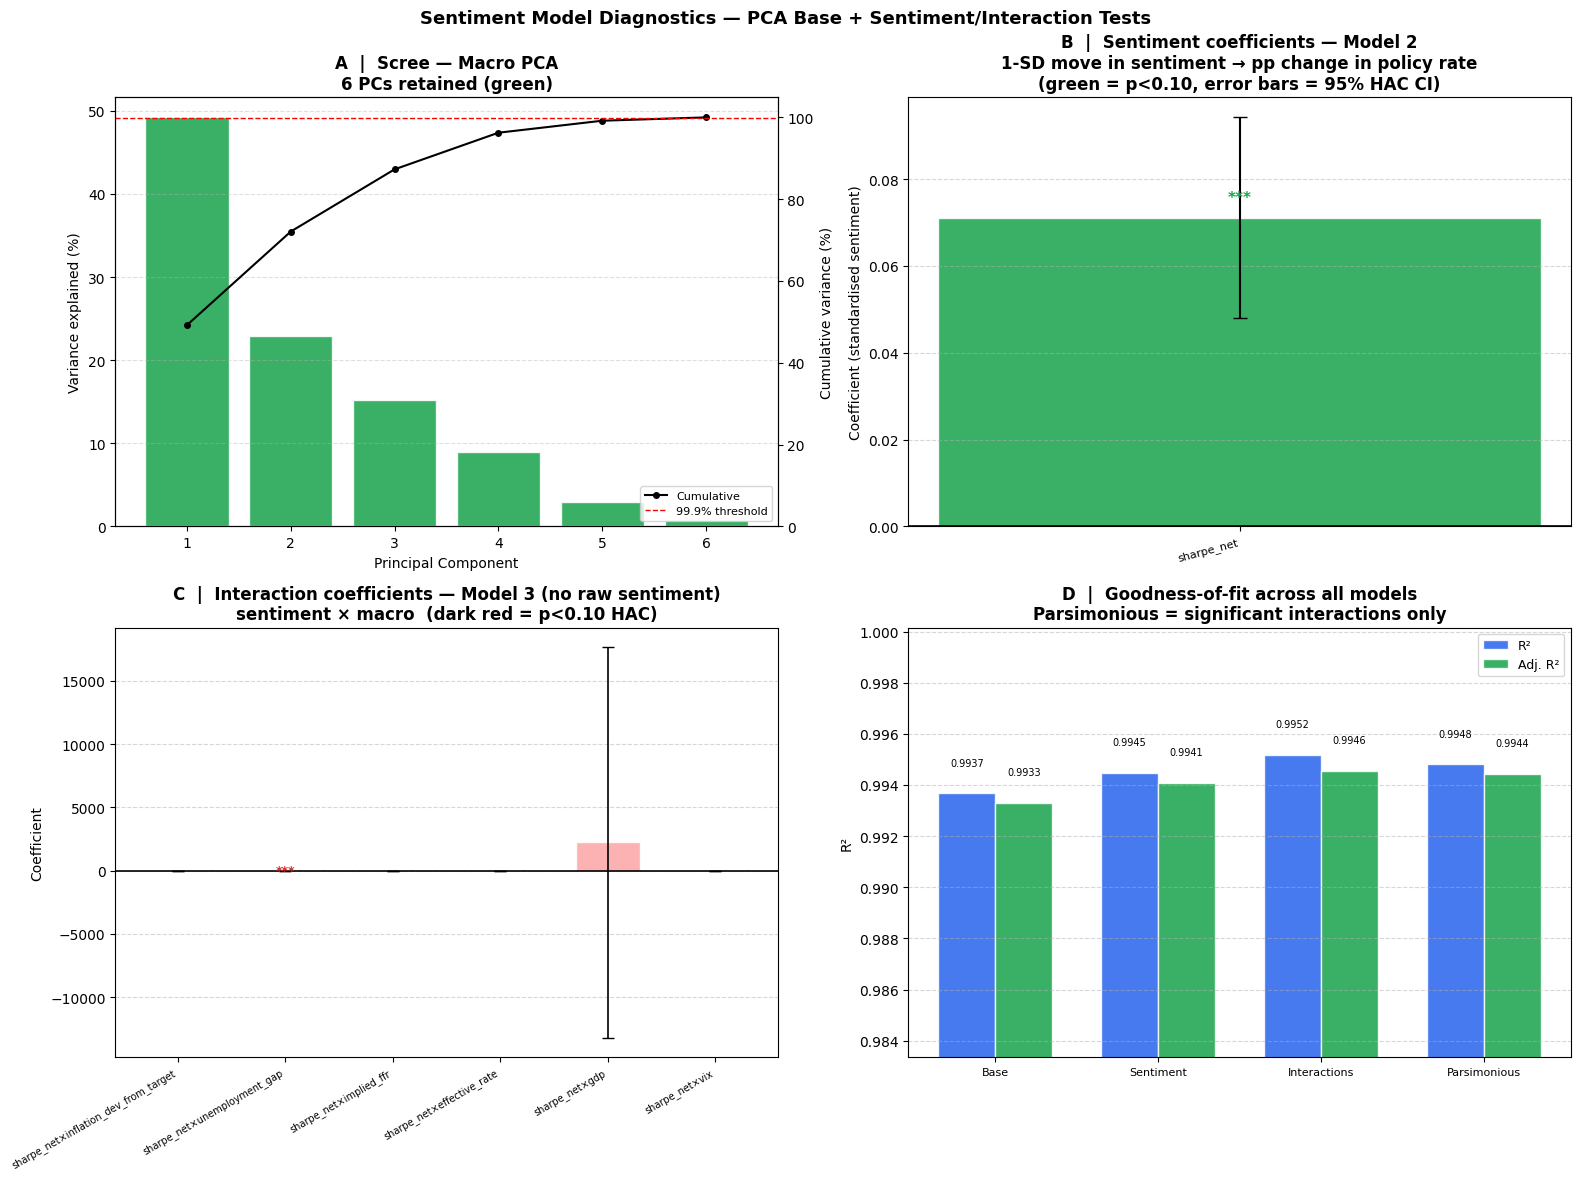

Figure saved.



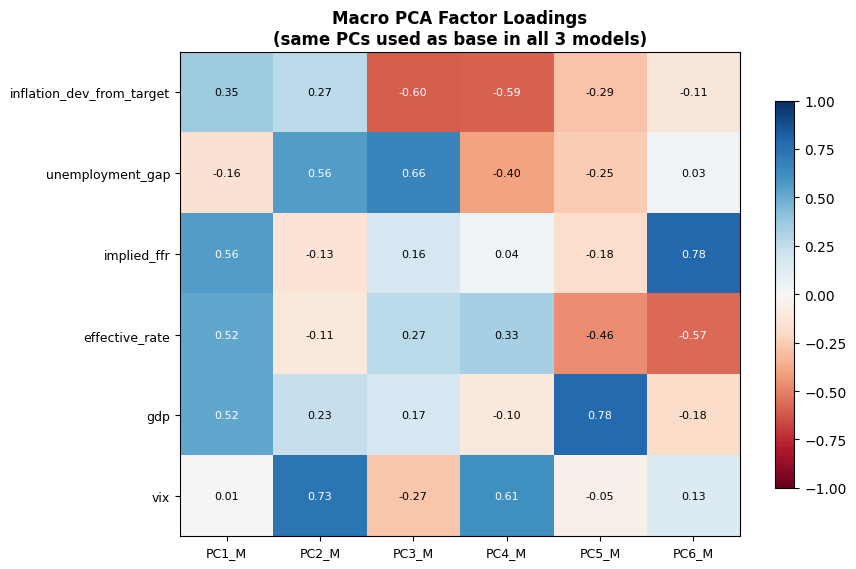

Loading heatmap saved.


MODEL 1 — Base: Macro PCA Factors only (HAC Robust)
                            OLS Regression Results                            
Dep. Variable:            target_rate   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     5335.
Date:                Fri, 03 Apr 2026   Prob (F-statistic):          5.79e-124
Time:                        12:41:19   Log-Likelihood:                 52.189
No. Observations:                 108   AIC:                            -90.38
Df Residuals:                     101   BIC:                            -71.60
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

In [ ]:
#@title FAVAR Sentiment and Interactions (excluding gdp)
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

df_ols = df_model.copy()

Regressors = [
    'inflation_dev_from_target',
    'unemployment_gap',
    'implied_ffr',
    'effective_rate',
    'gdp',
    'vix',
]

# Target: next-meeting rate
df_ols['target_rate'] = df_ols['fed_funds_rate'].shift(-1)

# ── Sentiment ─────────────────────────────────────────────────────────────────
sentiment_predictors = [
    c for name in sentiment_dfs
    for c in sentiment_cols[name]
    if c in df_ols.columns
]

predictors_macro = [r for r in Regressors if r in df_ols.columns]
all_cols         = list(dict.fromkeys(predictors_macro + sentiment_predictors))

print(f"Macro regressors    : {predictors_macro}")
print(f"Sentiment indicators: {sentiment_predictors}\n")

assert len(predictors_macro) == len([r for r in Regressors if r in df_ols.columns]), \
    f"Missing macro cols: {set(Regressors) - set(df_ols.columns)}"
assert len(sentiment_predictors) > 0, \
    "No sentiment columns found — check sentiment_dfs and sentiment_cols"

# ── Centering ─────────────────────────────────────────────────────────────────
MIN_PERIODS = 10

if USE_CENTERING:
    print("Centering: ENABLED (expanding window, no look-ahead)")
    for col in all_cols:
        exp_mean    = df_ols[col].expanding(min_periods=MIN_PERIODS).mean().shift(1)
        df_ols[col] = df_ols[col] - exp_mean
    df_ols.dropna(subset=all_cols, inplace=True)
else:
    print("Centering: DISABLED")

df_clean = df_ols[['target_rate'] + all_cols].dropna().reset_index(drop=True)
y        = df_clean['target_rate']
N        = len(df_clean)
print(f"\nSample size: {N} observations\n")

# ── Sentiment is already z-scored — use directly ─────────────────────────────
# Coefficients read as "a 1-SD move in sentiment implies X pp change in policy."
sent_std_df   = df_clean[sentiment_predictors].copy()
sent_std_cols = sentiment_predictors

# ── Interaction terms: sentiment × each macro regressor ──────────────────────
# Interactions reveal whether sentiment's effect is conditional on macro state.
# e.g. does hawkish sentiment matter more when inflation is already elevated?
interact_cols = []
interact_df   = pd.DataFrame(index=df_clean.index)
for s in sent_std_cols:
    for m in predictors_macro:
        col = f'{s}_X_{m}'
        interact_df[col] = df_clean[s] * df_clean[m]
        interact_cols.append(col)

print(f"Interaction terms created: {len(interact_cols)}\n")

# ══════════════════════════════════════════════════════════════════════════════
# PCA on macro regressors
#
# PCA is fit on macro variables ONLY — the same single PCA is used as the
# base for all three models. Sentiment and interactions are added as raw
# (standardised) regressors on top, preserving interpretability and enabling
# clean nested F-tests.
#
# VAR_THRESHOLD = 0.999 retains nearly all variance (equivalent to keeping
# all components). Lower this (e.g. 0.80) to get a more compressed factor set.
# ══════════════════════════════════════════════════════════════════════════════

VAR_THRESHOLD = 0.999

def fit_pca(df, cols, var_threshold=VAR_THRESHOLD, label=''):
    X_raw    = df[cols].values
    scaler   = StandardScaler()
    X_std    = scaler.fit_transform(X_raw)
    pca_full = PCA().fit(X_std)

    eigenvalues  = pca_full.explained_variance_
    kaiser_keep  = int(np.sum(eigenvalues > 1))
    cum_var      = np.cumsum(pca_full.explained_variance_ratio_)
    thresh_keep  = int(np.searchsorted(cum_var, var_threshold) + 1)
    n_kept       = max(kaiser_keep, thresh_keep, 1)

    pca        = PCA(n_components=n_kept)
    scores_arr = pca.fit_transform(X_std)
    col_names  = [f'PC{i+1}_{label}' for i in range(n_kept)]
    scores     = pd.DataFrame(scores_arr, columns=col_names, index=df.index)
    loadings   = pd.DataFrame(pca.components_.T, index=cols, columns=col_names)

    print(f"  [{label}] {len(cols)} vars → {n_kept} PCs retained")
    print(f"           Kaiser: {kaiser_keep}  |  "
          f"Var threshold ({var_threshold:.1%}): {thresh_keep}")
    print(f"           Cumulative variance explained: "
          f"{pca.explained_variance_ratio_.cumsum()[-1]:.4f}\n")

    return scores, pca, scaler, n_kept, pca.explained_variance_ratio_, loadings


print("─" * 55)
print("PCA — macro regressors (shared across all 3 models)")
print("─" * 55)
scores_macro, pca_macro, scaler_macro, k_macro, var_macro, load_macro = fit_pca(
    df_clean, predictors_macro, label='M'
)

def print_loadings(df, label):
    print(f"\nFactor loadings — {label}")
    print(df.round(3).to_string())
    print()

print_loadings(load_macro, "Macro PCA")

print("All three models use the SAME macro PCA scores.")
print("Model 2 appends sentiment as an explicit additive regressor.")
print("Model 3 drops the raw sentiment term and uses ONLY sentiment×macro interactions.")
print("  Rationale: Test A showed sentiment main effect p=0.55 (not significant).")
print("  Keeping it alongside interactions causes multicollinearity without adding signal.\n")

# ══════════════════════════════════════════════════════════════════════════════
# DESIGN MATRICES
#   Model 1 — Base          : macro PCA scores
#   Model 2 — Sentiment     : macro PCA scores + raw sentiment (additive)
#   Model 3 — Interactions  : macro PCA scores + sentiment×macro ONLY
#                             (raw sentiment dropped — not significant, drives VIF)
# ══════════════════════════════════════════════════════════════════════════════

X_base  = sm.add_constant(scores_macro)
X_sent  = sm.add_constant(pd.concat([scores_macro, sent_std_df], axis=1))
X_inter = sm.add_constant(pd.concat([scores_macro, interact_df], axis=1))  # no raw sentiment

hac_kwargs = {'maxlags': 4}

ols_base  = sm.OLS(y, X_base).fit(cov_type='HAC', cov_kwds=hac_kwargs)
ols_sent  = sm.OLS(y, X_sent).fit(cov_type='HAC', cov_kwds=hac_kwargs)
ols_inter = sm.OLS(y, X_inter).fit(cov_type='HAC', cov_kwds=hac_kwargs)

# ── Model comparison table ────────────────────────────────────────────────────
centering_label = "Expanding Mean" if USE_CENTERING else "No Centering"

comparison_df = pd.DataFrame({
    'Metric': ['R-squared', 'Adj. R-squared', 'AIC', 'BIC', 'N params'],
    'Model 1 — Base': [
        round(ols_base.rsquared,     6),
        round(ols_base.rsquared_adj, 6),
        round(ols_base.aic,          3),
        round(ols_base.bic,          3),
        k_macro + 1,
    ],
    'Model 2 — Sentiment': [
        round(ols_sent.rsquared,     6),
        round(ols_sent.rsquared_adj, 6),
        round(ols_sent.aic,          3),
        round(ols_sent.bic,          3),
        k_macro + len(sent_std_cols) + 1,
    ],
    'Model 3 — Interactions only': [
        round(ols_inter.rsquared,     6),
        round(ols_inter.rsquared_adj, 6),
        round(ols_inter.aic,          3),
        round(ols_inter.bic,          3),
        k_macro + len(interact_cols) + 1,   # PCs + interactions + constant (no raw sentiment)
    ],
})

print(f"══ MODEL COMPARISON [{centering_label} | HAC Robust] ══")
print(comparison_df.to_string(index=False))
print("\nNote: Lower AIC/BIC = better fit penalised for complexity.\n")

# ══════════════════════════════════════════════════════════════════════════════
# F-TESTS (all use standard OLS — HAC does not affect point estimates or RSS)
#
#   Test A: do sentiment indicators jointly add power beyond macro PCA?
#           Restricted = Model 1, Unrestricted = Model 2
#
#   Test B: do interaction terms jointly add power beyond macro + sentiment?
#           Restricted = Model 2, Unrestricted = Model 3
#
#   Test C: do sentiment + interactions jointly beat macro PCA alone?
#           Restricted = Model 1, Unrestricted = Model 3
# ══════════════════════════════════════════════════════════════════════════════

ols_base_f  = sm.OLS(y, X_base).fit()
ols_sent_f  = sm.OLS(y, X_sent).fit()
ols_inter_f = sm.OLS(y, X_inter).fit()

def run_ftest(ols_unrestricted, ols_restricted, n_restrictions, label):
    f_stat, f_pval, _ = ols_unrestricted.compare_f_test(ols_restricted)
    stars = ('***' if f_pval < 0.01 else
             '**'  if f_pval < 0.05 else
             '*'   if f_pval < 0.10 else '')
    print(f"  {label}")
    print(f"  F({n_restrictions}, {int(ols_unrestricted.df_resid)}) = "
          f"{f_stat:.3f}   p = {f_pval:.4f}  {stars}")
    if   f_pval < 0.01: print("  → Jointly significant at 1%")
    elif f_pval < 0.05: print("  → Jointly significant at 5%")
    elif f_pval < 0.10: print("  → Jointly significant at 10%")
    else:               print("  → NOT jointly significant")
    print()
    return f_stat, f_pval

print("─" * 60)
print("F-TESTS")
print("─" * 60)

run_ftest(ols_sent_f,  ols_base_f,  len(sent_std_cols),
          "Test A: sentiment main effect = 0  (Model 2 vs Model 1)")

run_ftest(ols_inter_f, ols_base_f,  len(interact_cols),
          "Test B: all interactions = 0  (Model 3 vs Model 1)")

# ══════════════════════════════════════════════════════════════════════════════
# VIF ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(X_df, label):
    cols   = [c for c in X_df.columns if c != 'const']
    X_vals = X_df[cols].values.astype(float)
    vif_df = pd.DataFrame({
        'Variable': cols,
        'VIF':      [variance_inflation_factor(X_vals, i)
                     for i in range(X_vals.shape[1])]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)

    print(f"\n── VIF — {label} ──")
    print(f"  {'Variable':<42} {'VIF':>8}")
    print("  " + "-" * 52)
    for _, row in vif_df.iterrows():
        flag = "  ← SEVERE"   if row.VIF > 10 else \
               "  ← MODERATE" if row.VIF > 5  else ""
        print(f"  {row.Variable:<42} {row.VIF:>8.2f}{flag}")
    n_severe   = (vif_df.VIF > 10).sum()
    n_moderate = ((vif_df.VIF > 5) & (vif_df.VIF <= 10)).sum()
    print(f"\n  Severe (VIF>10): {n_severe}   Moderate (VIF 5-10): {n_moderate}\n")
    return vif_df

print("\n" + "─" * 60)
print("VIF ANALYSIS")
print("─" * 60)

vif_base  = compute_vif(X_base.drop(columns='const',  errors='ignore'), "Model 1 — Base")
vif_sent  = compute_vif(X_sent.drop(columns='const',  errors='ignore'), "Model 2 — Sentiment")
vif_inter = compute_vif(X_inter.drop(columns='const', errors='ignore'), "Model 3 — Interactions only")

# ══════════════════════════════════════════════════════════════════════════════
# INDIVIDUAL INTERACTION TERM TESTS
#
# Two complementary approaches:
#   (a) HAC t-statistics from Model 3 — individual significance of each term
#   (b) Sequential marginal F-test — does adding each interaction term
#       significantly improve fit over the model without it?
#       This is more conservative than t-stats under multicollinearity.
# ══════════════════════════════════════════════════════════════════════════════

print("─" * 70)
print("INDIVIDUAL INTERACTION TERM TESTS")
print("─" * 70)
print(f"  {'Term':<42} {'t-stat':>8} {'p(HAC)':>8} {'p(F-marg)':>10} {'Keep?':>7}")
print("  " + "-" * 72)

def sig(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

indiv_results = []

for col in interact_cols:
    # (a) HAC t-stat from full Model 3
    t_stat  = ols_inter.tvalues[col]
    p_hac   = ols_inter.pvalues[col]

    # (b) Marginal F-test: Model 3 without this term vs with it
    other_cols  = [c for c in interact_cols if c != col]
    X_without   = sm.add_constant(
        pd.concat([scores_macro, interact_df[other_cols]], axis=1)
        if other_cols else scores_macro
    )
    ols_without = sm.OLS(y, X_without).fit()
    f_m, p_f, _ = ols_inter_f.compare_f_test(ols_without)

    # Keep if either test is significant at 10%
    keep = "YES" if (p_hac < 0.10 or p_f < 0.10) else "no"

    short = col.replace('_X_', '×')
    print(f"  {short:<42} {t_stat:>8.3f} {p_hac:>8.3f}{sig(p_hac):3} "
          f"{p_f:>10.3f}{sig(p_f):3} {keep:>7}")

    indiv_results.append({
        'term': col, 't_stat': t_stat, 'p_hac': p_hac,
        'p_fmarg': p_f, 'keep': keep == "YES"
    })

df_indiv = pd.DataFrame(indiv_results)
keep_cols = df_indiv.loc[df_indiv.keep, 'term'].tolist()

print(f"\n  Terms to retain (p<0.10 on either test): {len(keep_cols)}/{len(interact_cols)}")
print(f"  {keep_cols}\n")

# ══════════════════════════════════════════════════════════════════════════════
# PARSIMONIOUS MODEL — only the significant interaction terms
# ══════════════════════════════════════════════════════════════════════════════

if keep_cols:
    X_pars    = sm.add_constant(
        pd.concat([scores_macro, interact_df[keep_cols]], axis=1)
    )
    ols_pars      = sm.OLS(y, X_pars).fit(cov_type='HAC', cov_kwds=hac_kwargs)
    ols_pars_f    = sm.OLS(y, X_pars).fit()

    print("─" * 60)
    print(f"PARSIMONIOUS MODEL — {len(keep_cols)} significant interaction(s)")
    print("─" * 60)

    fa, pa, _ = ols_pars_f.compare_f_test(ols_base_f)
    stars_pa  = ('***' if pa < 0.01 else '**' if pa < 0.05 else
                 '*'   if pa < 0.10 else '')
    print(f"  Joint F-test vs Base: F({len(keep_cols)}, {int(ols_pars_f.df_resid)}) "
          f"= {fa:.3f}   p = {pa:.4f}  {stars_pa}")
    print(f"  R²={ols_pars.rsquared:.6f}  Adj-R²={ols_pars.rsquared_adj:.6f}  "
          f"AIC={ols_pars.aic:.1f}  BIC={ols_pars.bic:.1f}\n")

    vif_pars = compute_vif(X_pars.drop(columns='const', errors='ignore'),
                           "Parsimonious model")
else:
    print("No interaction terms survived individual testing — parsimonious model = Base.\n")
    ols_pars = ols_base

# ══════════════════════════════════════════════════════════════════════════════
# PLOTS
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sentiment Model Diagnostics — PCA Base + Sentiment/Interaction Tests',
             fontsize=13, fontweight='bold')

# ── Panel A: Scree plot ───────────────────────────────────────────────────────
ax_a = axes[0, 0]
pca_full_macro = PCA().fit(StandardScaler().fit_transform(
    df_clean[predictors_macro].values))
var_ratios = pca_full_macro.explained_variance_ratio_
n_all      = len(var_ratios)
ax_a.bar(range(1, n_all+1), var_ratios * 100,
         color=['#16A34A' if i < k_macro else '#93C5FD' for i in range(n_all)],
         alpha=0.85, edgecolor='white')
ax2 = ax_a.twinx()
ax2.plot(range(1, n_all+1), np.cumsum(var_ratios) * 100,
         color='black', marker='o', ms=4, lw=1.5, label='Cumulative')
ax2.axhline(y=VAR_THRESHOLD * 100, color='red', ls='--', lw=1,
            label=f'{VAR_THRESHOLD:.1%} threshold')
ax2.set_ylabel('Cumulative variance (%)')
ax2.set_ylim(0, 105)
ax2.legend(fontsize=8, loc='lower right')
ax_a.set_title(f'A  |  Scree — Macro PCA\n{k_macro} PCs retained (green)',
               fontweight='bold')
ax_a.set_xlabel('Principal Component')
ax_a.set_ylabel('Variance explained (%)')
ax_a.set_xticks(range(1, n_all+1))
ax_a.grid(True, ls='--', alpha=0.4, axis='y')

# ── Panel B: Sentiment coefficients (Model 2) with 95% CI ────────────────────
ax_b = axes[0, 1]
sent_params = ols_sent.params[sent_std_cols]
sent_ci     = ols_sent.conf_int().loc[sent_std_cols]
sent_pvals  = ols_sent.pvalues[sent_std_cols]
x_s         = np.arange(len(sent_std_cols))
bcols_s     = ['#16A34A' if p < 0.10 else '#93C5FD' for p in sent_pvals]

ax_b.bar(x_s, sent_params, 0.5, color=bcols_s, alpha=0.85, edgecolor='white')
ax_b.errorbar(x_s, sent_params,
              yerr=[sent_params - sent_ci.iloc[:, 0],
                    sent_ci.iloc[:, 1] - sent_params],
              fmt='none', color='black', capsize=5, lw=1.5)
ax_b.axhline(y=0, color='black', lw=1.2)
for xi, (coef, pv) in enumerate(zip(sent_params, sent_pvals)):
    stars = ('***' if pv < 0.01 else '**' if pv < 0.05 else
             '*'   if pv < 0.10 else '')
    if stars:
        offset = abs(sent_params.max()) * 0.05
        ax_b.text(xi, coef + (offset if coef >= 0 else -offset*2),
                  stars, ha='center', fontsize=11,
                  color='#16A34A', fontweight='bold')
ax_b.set_title('B  |  Sentiment coefficients — Model 2\n'
               '1-SD move in sentiment → pp change in policy rate\n'
               '(green = p<0.10, error bars = 95% HAC CI)',
               fontweight='bold')
ax_b.set_xticks(x_s)
ax_b.set_xticklabels([c for c in sent_std_cols],
                     fontsize=8, rotation=15, ha='right')
ax_b.set_ylabel('Coefficient (standardised sentiment)')
ax_b.grid(True, ls='--', alpha=0.5, axis='y')

# ── Panel C: Interaction coefficients (Model 3) ───────────────────────────────
ax_c = axes[1, 0]
inter_params = ols_inter.params[interact_cols]
inter_pvals  = ols_inter.pvalues[interact_cols]
inter_ci     = ols_inter.conf_int().loc[interact_cols]
x_i          = np.arange(len(interact_cols))
bcols_i      = ['#DC2626' if p < 0.10 else '#FCA5A5' for p in inter_pvals]

ax_c.bar(x_i, inter_params, 0.6, color=bcols_i, alpha=0.85, edgecolor='white')
ax_c.errorbar(x_i, inter_params,
              yerr=[inter_params - inter_ci.iloc[:, 0],
                    inter_ci.iloc[:, 1] - inter_params],
              fmt='none', color='black', capsize=4, lw=1.2)
ax_c.axhline(y=0, color='black', lw=1.2)
for xi, (coef, pv) in enumerate(zip(inter_params, inter_pvals)):
    stars = ('***' if pv < 0.01 else '**' if pv < 0.05 else
             '*'   if pv < 0.10 else '')
    if stars:
        offset = max(abs(inter_params)) * 0.05
        ax_c.text(xi, coef + (offset if coef >= 0 else -offset*2),
                  stars, ha='center', fontsize=9,
                  color='#DC2626', fontweight='bold')
ax_c.set_title('C  |  Interaction coefficients — Model 3 (no raw sentiment)\n'
               'sentiment × macro  (dark red = p<0.10 HAC)',
               fontweight='bold')
ax_c.set_xticks(x_i)
short_labels = [c.replace('_X_', '×') for c in interact_cols]
ax_c.set_xticklabels(short_labels, fontsize=7, rotation=30, ha='right')
ax_c.set_ylabel('Coefficient')
ax_c.grid(True, ls='--', alpha=0.5, axis='y')

# ── Panel D: R², Adj-R², AIC comparison across models ────────────────────────
ax_d = axes[1, 1]
model_labels = ['Base', 'Sentiment', 'Interactions', 'Parsimonious']
ols_list     = [ols_base, ols_sent, ols_inter, ols_pars]
r2_vals      = [o.rsquared     for o in ols_list]
r2_adj_vals  = [o.rsquared_adj for o in ols_list]
x_m          = np.arange(len(model_labels))
w_m          = 0.35

bars1 = ax_d.bar(x_m - w_m/2, r2_vals,     w_m, color='#2563EB',
                  alpha=0.85, edgecolor='white', label='R²')
bars2 = ax_d.bar(x_m + w_m/2, r2_adj_vals, w_m, color='#16A34A',
                  alpha=0.85, edgecolor='white', label='Adj. R²')
for bar in list(bars1) + list(bars2):
    ax_d.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.001,
              f'{bar.get_height():.4f}',
              ha='center', va='bottom', fontsize=7)
ax_d.set_title('D  |  Goodness-of-fit across all models\n'
               'Parsimonious = significant interactions only',
               fontweight='bold')
ax_d.set_xticks(x_m)
ax_d.set_xticklabels(model_labels, fontsize=8)
ax_d.set_ylabel('R²')
ax_d.set_ylim(min(r2_adj_vals) * 0.99, max(r2_vals) * 1.005)
ax_d.legend(fontsize=9)
ax_d.grid(True, ls='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.savefig('sentiment_pca_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.\n")

# ── Macro PCA loading heatmap (separate figure — can be many PCs) ─────────────
fig2, ax_h = plt.subplots(figsize=(max(6, k_macro * 1.5), len(predictors_macro) * 0.8 + 1))
im = ax_h.imshow(load_macro.values, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
ax_h.set_xticks(range(k_macro))
ax_h.set_xticklabels(load_macro.columns, fontsize=9)
ax_h.set_yticks(range(len(predictors_macro)))
ax_h.set_yticklabels(predictors_macro, fontsize=9)
for i in range(len(predictors_macro)):
    for j in range(k_macro):
        ax_h.text(j, i, f'{load_macro.values[i, j]:.2f}',
                  ha='center', va='center', fontsize=8,
                  color='white' if abs(load_macro.values[i, j]) > 0.5 else 'black')
plt.colorbar(im, ax=ax_h, shrink=0.8)
ax_h.set_title('Macro PCA Factor Loadings\n(same PCs used as base in all 3 models)',
               fontweight='bold')
plt.tight_layout()
plt.savefig('macro_pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()
print("Loading heatmap saved.\n")

# ── OLS summaries ─────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("MODEL 1 — Base: Macro PCA Factors only (HAC Robust)")
print("="*80)
print(ols_base.summary())

print("\n" + "="*80)
print("MODEL 2 — Sentiment: Macro PCA + Sentiment additive (HAC Robust)")
print("="*80)
print(ols_sent.summary())

print("\n" + "="*80)
print("MODEL 3 — Interactions: Macro PCA + Sentiment×Macro only (HAC Robust)")
print("  Note: raw sentiment dropped — not significant (p=0.55), drives VIF")
print("="*80)
print(ols_inter.summary())

if keep_cols:
    print("\n" + "="*80)
    print(f"PARSIMONIOUS — Macro PCA + {len(keep_cols)} significant interaction(s) (HAC Robust)")
    print("="*80)
    print(ols_pars.summary())

Base predictors : ['inflation_dev_from_target', 'unemployment_gap', 'effective_rate', 'gdp']
Extra predictors: ['actual_wedge_UNEMPF1', 'actual_wedge_gRGDPF1', 'actual_wedge_gPCPIF1']
Full predictors : ['inflation_dev_from_target', 'unemployment_gap', 'effective_rate', 'gdp', 'actual_wedge_UNEMPF1', 'actual_wedge_gRGDPF1', 'actual_wedge_gPCPIF1']

Clean sample size: 108 observations

min_train_size : 12
FIXED_TRAIN    : 70
OOS steps at FIXED_TRAIN: 38

Running walk-forward CV...
Walk-forward complete.

        CLARK-WEST TEST RESULTS (CW-adj DM, one-sided)        
Horizon    Comparison                   CW Stat    p-value   Sig
--------------------------------------------------------------
h=1         Base vs Full (Wedges)          0.927      0.177      
--------------------------------------------------------------
h=2         Base vs Full (Wedges)          0.332      0.370      
--------------------------------------------------------------
Significance: *** p<0.01  ** p<0.05  * p<0.

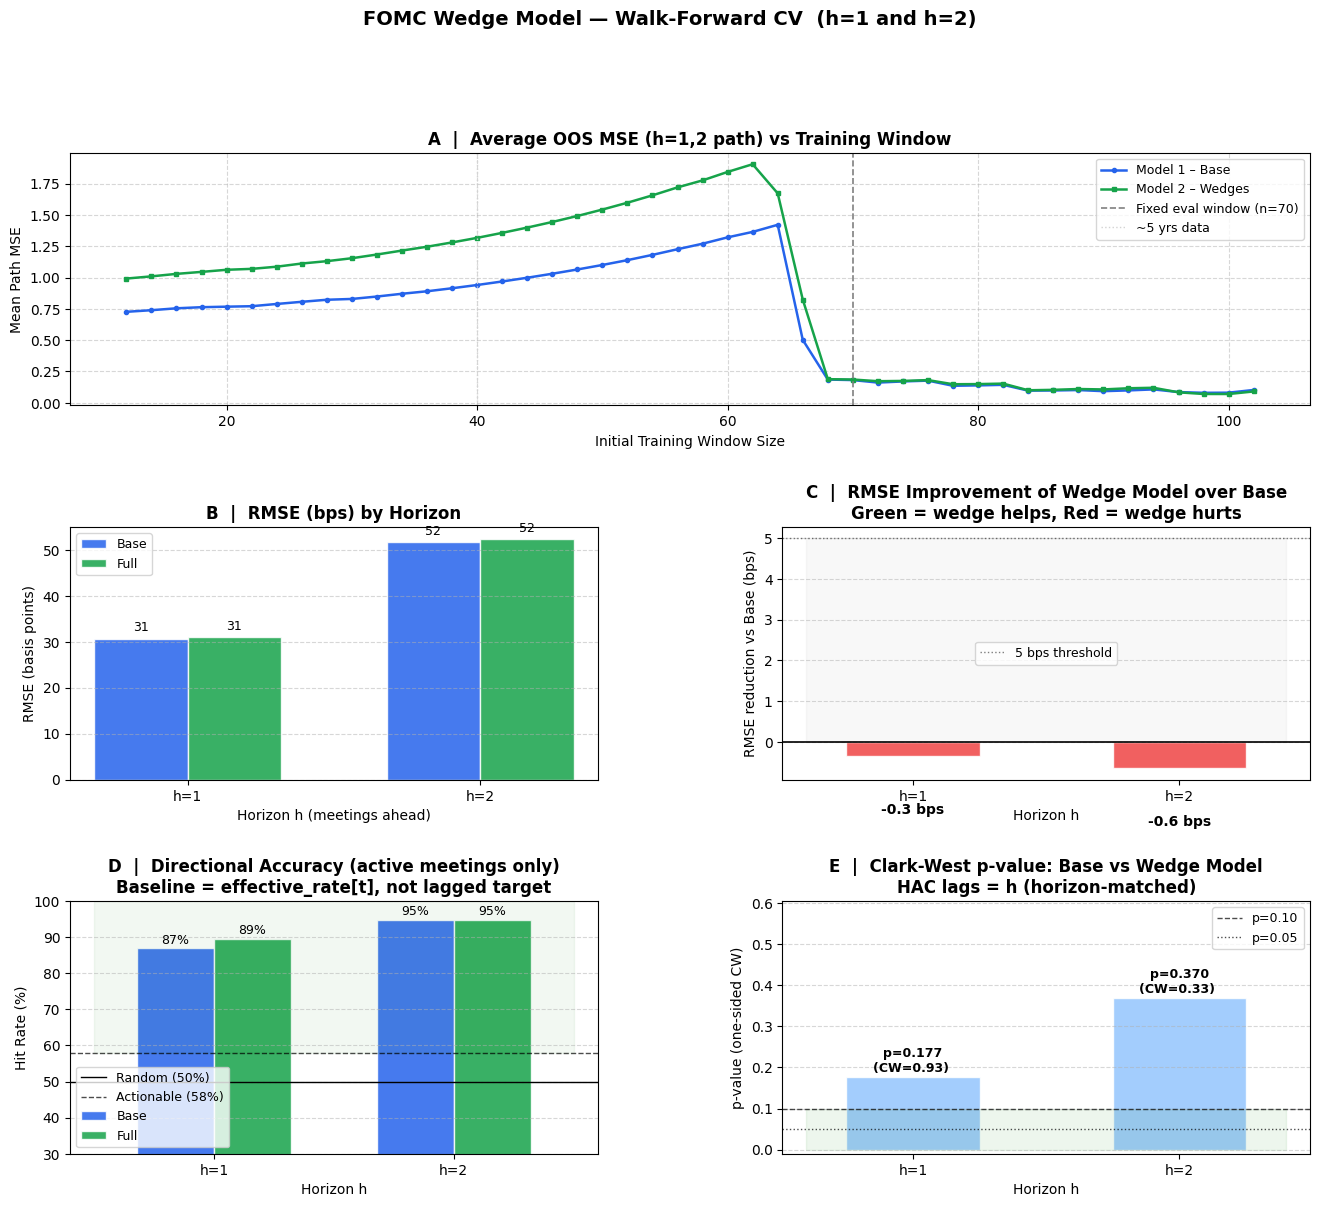

Figure saved.


In [ ]:
#@title Walk-Forward CV for Wedge
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")

# ══════════════════════════════════════════════════════════════════════════════
# 0. SETUP
# ══════════════════════════════════════════════════════════════════════════════

df_ols = df_model.copy()

# ── Regressors — each on its own line with a trailing comma to prevent
#    silent string concatenation (the 'implied_ffr''gdp' bug) ─────────────────
Regressors = [
    'inflation_dev_from_target',
    'unemployment_gap',
    'effective_rate',              # ← comma required — adjacent strings silently merge
    'gdp',
]

Extra_Regressors = [
    'actual_wedge_UNEMPF1',
    'actual_wedge_gRGDPF1',
    'actual_wedge_gPCPIF1',
]

predictors_base  = [r for r in Regressors       if r in df_ols.columns]
predictors_extra = [e for e in Extra_Regressors  if e in df_ols.columns]
predictors_full  = predictors_base + predictors_extra

# Sanity check — print exactly what goes into each model
print(f"Base predictors : {predictors_base}")
print(f"Extra predictors: {predictors_extra}")
print(f"Full predictors : {predictors_full}\n")
assert len(predictors_base) == len(Regressors), \
    f"Some base regressors not found in df_model: " \
    f"{set(Regressors) - set(predictors_base)}"

# ── Expanding-mean centering (no look-ahead) ──────────────────────────────────
USE_CENTERING = True
MIN_PERIODS   = 10

if USE_CENTERING:
    for col in predictors_full:
        expanding_mean = df_ols[col].expanding(min_periods=MIN_PERIODS).mean().shift(1)
        df_ols[col]    = df_ols[col] - expanding_mean
    df_ols.dropna(subset=predictors_full, inplace=True)

# ── Target columns h=1 and h=2 only ──────────────────────────────────────────
# target_rate_h{h}[t] = effective_rate[t+h]
# This is what we are trying to predict at forecast point t.
MAX_HORIZON = 2
target_cols = []
for h in range(1, MAX_HORIZON + 1):
    col_name = f'target_rate_h{h}'
    df_ols[col_name] = df_ols['effective_rate'].shift(-h)
    target_cols.append(col_name)

# Store current rate — needed for correct directional accuracy.
# current_rate[t] = effective_rate[t], i.e. the rate AT the time of forecast.
# This is NOT the same as the target — the target is h steps into the future.
df_ols['current_rate'] = df_ols['effective_rate']

df_clean = (
    df_ols[target_cols + predictors_full + ['current_rate']]
    .dropna()
    .reset_index(drop=True)
)

N = len(df_clean)
print(f"Clean sample size: {N} observations\n")

X_base = sm.add_constant(df_clean[predictors_base])
X_full = sm.add_constant(df_clean[predictors_full])

# ══════════════════════════════════════════════════════════════════════════════
# 1. WALK-FORWARD CV
#
# At forecast point t, for horizon h:
#   - We predict  target_rate_h{h}[t] = effective_rate[t+h]
#   - We train on target_rate_h{h}[0..train_end-1]
#     where train_end = t - h + 1
#   - The last training target is effective_rate[t-h+1-1+h] = effective_rate[t]
#     which is observable at time t — no look-ahead bias.
#   - Crucially, effective_rate[t+h] (the test value) is NEVER in the training set.
#
# We store per-step records at FIXED_TRAIN for CW and quant metrics.
# We store current_rate[t] (not a target) for directional accuracy.
# ══════════════════════════════════════════════════════════════════════════════

FIXED_TRAIN    = 70
min_train_size = max(MIN_PERIODS + 2,          # enough for centering to stabilise
                     len(predictors_full) + 5)  # more obs than parameters

# Ensure FIXED_TRAIN is reachable in the train_size sweep
max_train_size = N - 5
train_sizes    = sorted(set(
    list(range(min_train_size, max_train_size + 1, 2)) + [FIXED_TRAIN]
))

assert FIXED_TRAIN <= max_train_size, \
    f"FIXED_TRAIN={FIXED_TRAIN} leaves no OOS data (max={max_train_size})"

print(f"min_train_size : {min_train_size}")
print(f"FIXED_TRAIN    : {FIXED_TRAIN}")
print(f"OOS steps at FIXED_TRAIN: {N - FIXED_TRAIN}\n")

# horizon_records stores per-step predictions at FIXED_TRAIN
# current_rate is the actual rate at forecast time t — used for directionality
horizon_records = {
    h: {'actual': [], 'base': [], 'full': [], 'current_rate': []}
    for h in range(1, MAX_HORIZON + 1)
}

mse_records = {'Train_Size': [], 'MSE_Base': [], 'MSE_Full': []}

print("Running walk-forward CV...")

for train_size in train_sizes:

    path_errors = {'base': [], 'full': []}

    for t in range(train_size, N):

        X_t_base = X_base.iloc[t:t+1]
        X_t_full = X_full.iloc[t:t+1]

        actuals_path   = []
        preds_b_path   = []
        preds_f_path   = []

        for h in range(1, MAX_HORIZON + 1):

            target    = f'target_rate_h{h}'

            # train_end ensures the last training TARGET is effective_rate[t],
            # which is known at time t. The test target effective_rate[t+h] is unseen.
            train_end = t - h + 1

            # Must have at least min_train_size rows AND enough for OLS to be
            # well-defined (more observations than parameters)
            if train_end < min_train_size:
                continue

            y_train      = df_clean[target].iloc[:train_end]
            X_train_base = X_base.iloc[:train_end]
            X_train_full = X_full.iloc[:train_end]

            ols_base = sm.OLS(y_train, X_train_base).fit()
            ols_full = sm.OLS(y_train, X_train_full).fit()

            actual = df_clean[target].iloc[t]
            pred_b = ols_base.predict(X_t_base).values[0]
            pred_f = ols_full.predict(X_t_full).values[0]

            actuals_path.append(actual)
            preds_b_path.append(pred_b)
            preds_f_path.append(pred_f)

            if train_size == FIXED_TRAIN:
                horizon_records[h]['actual'].append(actual)
                horizon_records[h]['base'].append(pred_b)
                horizon_records[h]['full'].append(pred_f)
                # Store the true current rate at forecast time t.
                # This is what directional accuracy must be measured against —
                # NOT a lagged version of the target array.
                horizon_records[h]['current_rate'].append(
                    df_clean['current_rate'].iloc[t]
                )

        if actuals_path:
            path_errors['base'].append(
                mean_squared_error(actuals_path, preds_b_path))
            path_errors['full'].append(
                mean_squared_error(actuals_path, preds_f_path))

    mse_records['Train_Size'].append(train_size)
    mse_records['MSE_Base'].append(np.mean(path_errors['base']))
    mse_records['MSE_Full'].append(np.mean(path_errors['full']))

df_mse = pd.DataFrame(mse_records)
print("Walk-forward complete.\n")

# ══════════════════════════════════════════════════════════════════════════════
# 2. CLARK-WEST TEST
#
# Uses horizon-matched HAC lags: lags = max(1, h)
# Rationale: h-step-ahead forecast errors are autocorrelated up to order h-1
# by construction (overlapping windows), so at minimum h lags are needed.
# For h=1 errors are MA(0) so 1 lag is a safe minimum.
# ══════════════════════════════════════════════════════════════════════════════

def clark_west_test(actuals, preds_restricted, preds_unrestricted, h):
    """
    Clark-West (2007) test for nested model comparison.
    H0: restricted model forecasts no worse (MSE_r <= MSE_u)
    H1: unrestricted model is genuinely better (one-sided)

    HAC lags = max(1, h) to account for h-step-ahead overlap.
    """
    a  = np.array(actuals)
    f1 = np.array(preds_restricted)
    f2 = np.array(preds_unrestricted)

    e1   = a - f1
    e2   = a - f2

    # CW loss differential: adds back the noise penalty the larger model pays
    # in finite samples, correcting the downward bias in raw DM for nested models
    d_cw = e1**2 - e2**2 + (f1 - f2)**2

    n    = len(d_cw)
    lags = max(1, h)   # horizon-matched, not generic bandwidth formula

    nw_se = sm.OLS(d_cw, sm.add_constant(np.ones(n))).fit(
        cov_type='HAC', cov_kwds={'maxlags': lags}
    ).bse[0]

    cw_stat = np.mean(d_cw) / (nw_se + 1e-12)
    p_val   = 1 - stats.norm.cdf(cw_stat)

    return cw_stat, p_val


def sig(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""


print("=" * 62)
print(f"{'CLARK-WEST TEST RESULTS (CW-adj DM, one-sided)':^62}")
print("=" * 62)
print(f"{'Horizon':<10} {'Comparison':<25} {'CW Stat':>10} {'p-value':>10} {'Sig':>5}")
print("-" * 62)

cw_results = {}
for h in range(1, MAX_HORIZON + 1):
    rec = horizon_records[h]
    if len(rec['actual']) < 10:
        print(f"h={h}: insufficient OOS observations ({len(rec['actual'])}), skipping")
        continue

    cw_stat, p_val = clark_west_test(
        rec['actual'], rec['base'], rec['full'], h
    )
    cw_results[h] = {'base_vs_full': (cw_stat, p_val)}

    print(f"h={h:<9} {'Base vs Full (Wedges)':<25} "
          f"{cw_stat:>10.3f} {p_val:>10.3f} {sig(p_val):>5}")
    print("-" * 62)

print("Significance: *** p<0.01  ** p<0.05  * p<0.10\n")

# ══════════════════════════════════════════════════════════════════════════════
# 3. QUANT STRATEGY METRICS
#
# Directional accuracy:
#   A "correct call" at step t for horizon h means:
#     sign(actual[t+h] - current_rate[t]) == sign(prediction[t+h] - current_rate[t])
#   i.e., the model called the direction of the CHANGE from the rate at forecast
#   time, not from some lagged or rolled version of the target array.
#
#   Hold meetings (|actual - current_rate| <= 1bp) are excluded because there
#   is no direction to predict.
#
# Binomial p-value:
#   One-sided test H1: hit_rate > 0.50 (better than random on active meetings).
# ══════════════════════════════════════════════════════════════════════════════

def directional_accuracy(actuals, current_rates, predictions):
    """
    Parameters
    ----------
    actuals       : effective_rate[t+h] for each OOS step t
    current_rates : effective_rate[t]   for each OOS step t  (true baseline)
    predictions   : model forecast of effective_rate[t+h]

    Returns
    -------
    hit_rate : float  (NaN if no active meetings)
    n_active : int    (number of meetings where Fed actually moved)
    """
    a  = np.array(actuals)
    p  = np.array(predictions)
    cr = np.array(current_rates)

    # Active = meetings where the Fed actually moved (hike or cut)
    active = np.abs(a - cr) > 0.001

    if active.sum() == 0:
        return np.nan, 0

    correct = np.sign(a - cr) == np.sign(p - cr)
    return float(correct[active].mean()), int(active.sum())


def binomial_pvalue(hit_rate, n_trials, null_rate=0.5):
    """One-sided binomial test: H1 = hit_rate > null_rate (better than random)"""
    if np.isnan(hit_rate) or n_trials == 0:
        return np.nan
    k = int(round(hit_rate * n_trials))
    return stats.binomtest(k, n_trials, null_rate, alternative='greater').pvalue


def tradeable_label(rmse_diff, dir_acc, p_dir):
    if np.isnan(dir_acc) or np.isnan(p_dir):
        return "N/A"
    if rmse_diff >= 5 and dir_acc >= 0.58 and p_dir < 0.10:
        return "✔ YES"
    if rmse_diff >= 5 or (dir_acc >= 0.58 and p_dir < 0.10):
        return "~ MAYBE"
    return "✘ NO"


print("=" * 72)
print(f"{'QUANT STRATEGY METRICS':^72}")
print("=" * 72)
print(f"{'Horizon':<8} {'Model':<12} {'RMSE(bps)':>10} {'vs Base':>10} "
      f"{'DirAcc':>8} {'n_active':>9} {'p(dir)':>8} {'Tradeable':>10}")
print("-" * 72)

quant_summary = []

for h in range(1, MAX_HORIZON + 1):
    rec = horizon_records[h]
    if len(rec['actual']) < 10:
        continue

    act = np.array(rec['actual'])
    cr  = np.array(rec['current_rate'])   # true current rate at each forecast step

    rmse_b = np.sqrt(mean_squared_error(act, rec['base'])) * 100
    rmse_f = np.sqrt(mean_squared_error(act, rec['full'])) * 100

    dir_b, n_active_b = directional_accuracy(act, cr, rec['base'])
    dir_f, n_active_f = directional_accuracy(act, cr, rec['full'])

    # n_active should be identical for both models (same actuals and current_rates)
    assert n_active_b == n_active_f, "n_active mismatch — check current_rate storage"
    n_active = n_active_b

    p_dir_b = binomial_pvalue(dir_b, n_active)
    p_dir_f = binomial_pvalue(dir_f, n_active)

    for model, rmse, dir_acc, p_dir in [
        ('Base', rmse_b, dir_b, p_dir_b),
        ('Full', rmse_f, dir_f, p_dir_f),
    ]:
        bps_vs_base = rmse_b - rmse if model != 'Base' else 0.0
        label = tradeable_label(bps_vs_base, dir_acc, p_dir) \
                if model != 'Base' else '—'
        da_str = f"{dir_acc:.1%}" if not np.isnan(dir_acc) else "  N/A"
        pd_str = f"{p_dir:.3f}"   if not np.isnan(p_dir)   else "  N/A"
        print(f"h={h:<7} {model:<12} {rmse:>10.1f} {bps_vs_base:>+10.1f} "
              f"{da_str:>8} {n_active:>9} {pd_str:>8} {label:>10}")

        quant_summary.append({
            'h': h, 'Model': model,
            'RMSE_bps': rmse, 'RMSE_vs_Base': bps_vs_base,
            'DirAcc': dir_acc, 'n_active': n_active, 'p_dir': p_dir
        })

    print("-" * 72)

print("Tradeable: RMSE improvement ≥5 bps AND directional acc ≥58% (p<0.10)\n")
df_quant = pd.DataFrame(quant_summary)

# ══════════════════════════════════════════════════════════════════════════════
# 4. PLOTS
# With only h=1 and h=2, bar charts are more readable than line plots.
# Layout: Panel A (full width) + 2x2 grid below.
# ══════════════════════════════════════════════════════════════════════════════

COLORS  = {'Base': '#2563EB', 'Full': '#16A34A'}
horizons = [1, 2]
x        = np.array([0, 1])
width    = 0.32

fig = plt.figure(figsize=(16, 13))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.48, wspace=0.35)

# ── Panel A: Aggregate Path MSE vs Train Size ─────────────────────────────────
ax_a = fig.add_subplot(gs[0, :])
ax_a.plot(df_mse['Train_Size'], df_mse['MSE_Base'],
          color=COLORS['Base'], marker='o', ms=3, lw=1.8, label='Model 1 – Base')
ax_a.plot(df_mse['Train_Size'], df_mse['MSE_Full'],
          color=COLORS['Full'], marker='s', ms=3, lw=1.8, label='Model 2 – Wedges')
ax_a.axvline(x=FIXED_TRAIN, color='gray', ls='--', lw=1.2,
             label=f'Fixed eval window (n={FIXED_TRAIN})')
ax_a.axvline(x=40, color='lightgray', ls=':', lw=1.0, label='~5 yrs data')
ax_a.set_title('A  |  Average OOS MSE (h=1,2 path) vs Training Window',
               fontweight='bold')
ax_a.set_xlabel('Initial Training Window Size')
ax_a.set_ylabel('Mean Path MSE')
ax_a.legend(fontsize=9)
ax_a.grid(True, ls='--', alpha=0.5)

# ── Panel B: RMSE by Horizon (grouped bars) ───────────────────────────────────
ax_b = fig.add_subplot(gs[1, 0])
for i, (model, color) in enumerate(COLORS.items()):
    vals = [df_quant.loc[(df_quant.h == h) & (df_quant.Model == model),
                         'RMSE_bps'].values[0]
            for h in horizons]
    bars = ax_b.bar(x + (i - 0.5) * width, vals, width,
                    color=color, alpha=0.85, edgecolor='white', label=model)
    for bar, v in zip(bars, vals):
        ax_b.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                  f'{v:.0f}', ha='center', va='bottom', fontsize=9)
ax_b.set_title('B  |  RMSE (bps) by Horizon', fontweight='bold')
ax_b.set_xlabel('Horizon h (meetings ahead)')
ax_b.set_ylabel('RMSE (basis points)')
ax_b.set_xticks(x); ax_b.set_xticklabels([f'h={h}' for h in horizons])
ax_b.legend(fontsize=9); ax_b.grid(True, ls='--', alpha=0.5, axis='y')

# ── Panel C: RMSE Improvement vs Base ────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, 1])
improv = [df_quant.loc[(df_quant.h == h) & (df_quant.Model == 'Full'),
                       'RMSE_vs_Base'].values[0]
          for h in horizons]
bar_colors = [COLORS['Full'] if v >= 0 else '#EF4444' for v in improv]
bars = ax_c.bar(x, improv, 0.5, color=bar_colors, alpha=0.85, edgecolor='white')
for bar, v in zip(bars, improv):
    ax_c.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.3 if v >= 0 else bar.get_height() - 1.5,
              f'{v:+.1f} bps', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax_c.axhline(y=0, color='black', lw=1.2)
ax_c.axhline(y=5, color='black', lw=1, ls=':', alpha=0.5, label='5 bps threshold')
ax_c.fill_between([-0.4, 1.4], 0, 5, alpha=0.05, color='gray')
ax_c.set_title('C  |  RMSE Improvement of Wedge Model over Base\n'
               'Green = wedge helps, Red = wedge hurts',
               fontweight='bold')
ax_c.set_xlabel('Horizon h')
ax_c.set_ylabel('RMSE reduction vs Base (bps)')
ax_c.set_xticks(x); ax_c.set_xticklabels([f'h={h}' for h in horizons])
ax_c.legend(fontsize=9); ax_c.grid(True, ls='--', alpha=0.5, axis='y')

# ── Panel D: Directional Accuracy ────────────────────────────────────────────
ax_d = fig.add_subplot(gs[2, 0])
for i, (model, color) in enumerate(COLORS.items()):
    vals = [df_quant.loc[(df_quant.h == h) & (df_quant.Model == model),
                         'DirAcc'].values[0] * 100
            for h in horizons]
    bars = ax_d.bar(x + (i - 0.5) * width, vals, width,
                    color=color, alpha=0.85, edgecolor='white', label=model)
    for bar, v in zip(bars, vals):
        ax_d.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                  f'{v:.0f}%', ha='center', va='bottom', fontsize=9)
ax_d.axhline(y=50, color='black', lw=1, ls='-',  label='Random (50%)')
ax_d.axhline(y=58, color='black', lw=1, ls='--', alpha=0.7,
             label='Actionable (58%)')
ax_d.fill_between([-0.5, 1.5], 58, 100, alpha=0.05, color='green')
ax_d.set_title('D  |  Directional Accuracy (active meetings only)\n'
               'Baseline = effective_rate[t], not lagged target',
               fontweight='bold')
ax_d.set_xlabel('Horizon h')
ax_d.set_ylabel('Hit Rate (%)')
ax_d.set_xticks(x); ax_d.set_xticklabels([f'h={h}' for h in horizons])
ax_d.set_ylim(30, 100)
ax_d.legend(fontsize=9); ax_d.grid(True, ls='--', alpha=0.5, axis='y')

# ── Panel E: Clark-West p-values ──────────────────────────────────────────────
ax_e = fig.add_subplot(gs[2, 1])
cw_hs = sorted(cw_results.keys())
pvals = [cw_results[h]['base_vs_full'][1] for h in cw_hs]
stats_ = [cw_results[h]['base_vs_full'][0] for h in cw_hs]

bar_cols = ['#16A34A' if p < 0.10 else '#93C5FD' for p in pvals]
bars = ax_e.bar(range(len(cw_hs)), pvals, 0.5,
                color=bar_cols, alpha=0.85, edgecolor='white')
for bar, h, p, s in zip(bars, cw_hs, pvals, stats_):
    label_str = f'p={p:.3f}\n(CW={s:.2f}) {sig(p)}'
    ax_e.text(bar.get_x() + bar.get_width()/2, p + 0.005,
              label_str, ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_e.axhline(y=0.10, color='black', lw=1, ls='--', alpha=0.7, label='p=0.10')
ax_e.axhline(y=0.05, color='black', lw=1, ls=':',  alpha=0.7, label='p=0.05')
ax_e.fill_between([-0.4, len(cw_hs) - 0.6], 0, 0.10, alpha=0.07, color='green')
ax_e.set_title('E  |  Clark-West p-value: Base vs Wedge Model\n'
               f'HAC lags = h (horizon-matched)',
               fontweight='bold')
ax_e.set_xlabel('Horizon h')
ax_e.set_ylabel('p-value (one-sided CW)')
ax_e.set_xticks(range(len(cw_hs)))
ax_e.set_xticklabels([f'h={h}' for h in cw_hs])
ax_e.set_ylim(-0.01, min(0.65, max(pvals) * 1.5 + 0.05))
ax_e.legend(fontsize=9); ax_e.grid(True, ls='--', alpha=0.5, axis='y')

fig.suptitle('FOMC Wedge Model — Walk-Forward CV  (h=1 and h=2)',
             fontsize=14, fontweight='bold', y=0.99)

plt.savefig('fomc_forecast_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")